# Análisis Geoespacial de la Distribución de Cobre en el Suroeste Antioqueño

**Autora:** Daniela Cardona Lopera

**Curso:** Análisis Geoespacial

**Software:** Google Colab (Python) y QGIS

**Objetivo:** Analizar la distribución espacial de la concentración de cobre (Cu) mediante técnicas de análisis exploratorio de datos (EDA), análisis espacial y geoestadística (variografía y kriging), utilizando información geológica y estructural del Suroeste antioqueño.


Este notebook documenta el flujo completo del análisis geoestadístico realizado sobre la base de datos geoquímica de cobre correspondiente al suroeste del departamento de Antioquia. El objetivo es caracterizar el comportamiento espacial de la variable mediante técnicas de análisis exploratorio, modelamiento variográfico e interpolación por kriging ordinario.

# 0. Configuración general del proyecto

En esta sección se establece el entorno reproducible de trabajo en Google Colab.
Se conectan los directorios del proyecto, se importan las librerías requeridas y
se definen los parámetros gráficos, cartográficos, numéricos y de exportación
que se utilizarán de manera uniforme durante todo el análisis.

0.1 Conexion y estructura de directorios

In [45]:
# ==========================================================
# Conectar Google Drive
# ==========================================================

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
# ==========================================================
# 0.1 CONEXIÓN Y ESTRUCTURA DE DIRECTORIOS DEL PROYECTO
# ==========================================================

from google.colab import drive
from pathlib import Path

# ----------------------------------------------------------
# Conectar Google Drive
# ----------------------------------------------------------

drive.mount("/content/drive")

# ----------------------------------------------------------
# Carpeta principal del proyecto
# ----------------------------------------------------------

RUTA_PROYECTO = Path(
    "/content/drive/MyDrive/Analisis_Geoespacial_Cobre"
)

# ==========================================================
# ESTRUCTURA GENERAL DEL PROYECTO
# ==========================================================

# -------------------------
# Notebook
# -------------------------

NOTEBOOK = RUTA_PROYECTO / "01_Notebook"

# -------------------------
# Datos
# -------------------------

DATOS = RUTA_PROYECTO / "02_Datos"

ORIGINALES = DATOS / "01_Originales"
PROCESADOS = DATOS / "02_Procesados"
ESTUDIO = DATOS / "03_Estudio"

# -------------------------
# Figuras finales
# -------------------------

FIGURAS = RUTA_PROYECTO / "03_Figuras"

# -------------------------
# Resultados
# -------------------------

RESULTADOS = RUTA_PROYECTO / "04_Resultados"

TABLAS = RESULTADOS / "01_Tablas"
MODELOS = RESULTADOS / "02_Modelos"
VALIDACION = RESULTADOS / "03_Validacion"

# -------------------------
# Código fuente
# -------------------------

SCRIPTS = RUTA_PROYECTO / "05_Scripts"

# -------------------------
# Documentación
# -------------------------

DOCUMENTACION = RUTA_PROYECTO / "06_Documentacion"

# ==========================================================
# CREAR LA ESTRUCTURA SI NO EXISTE
# ==========================================================

carpetas = [

    NOTEBOOK,

    DATOS,
    ORIGINALES,
    PROCESADOS,
    ESTUDIO,

    FIGURAS,



    RESULTADOS,
    TABLAS,
    MODELOS,
    VALIDACION,

    SCRIPTS,
    DOCUMENTACION

]

for carpeta in carpetas:
    carpeta.mkdir(parents=True, exist_ok=True)

# ==========================================================
# VERIFICACIÓN DE LA ESTRUCTURA
# ==========================================================

print("="*70)
print("ESTRUCTURA DEL PROYECTO")
print("="*70)

print(f"Proyecto         : {RUTA_PROYECTO.exists()}")
print(f"Notebook         : {NOTEBOOK.exists()}")

print("\nDATOS")
print(f"  Originales     : {ORIGINALES.exists()}")
print(f"  Procesados     : {PROCESADOS.exists()}")
print(f"  Estudio        : {ESTUDIO.exists()}")

print("\nFIGURAS")
print(f"  Figuras        : {FIGURAS.exists()}")

print("\nRESULTADOS")
print(f"  Tablas         : {TABLAS.exists()}")
print(f"  Modelos        : {MODELOS.exists()}")
print(f"  Validación     : {VALIDACION.exists()}")

print("\nOTROS")
print(f"  Scripts        : {SCRIPTS.exists()}")
print(f"  Documentación  : {DOCUMENTACION.exists()}")

print("="*70)
print("Proyecto conectado correctamente.")
print("="*70)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ESTRUCTURA DEL PROYECTO
Proyecto         : True
Notebook         : True

DATOS
  Originales     : True
  Procesados     : True
  Estudio        : True

FIGURAS
  Figuras        : True

RESULTADOS
  Tablas         : True
  Modelos        : True
  Validación     : True

OTROS
  Scripts        : True
  Documentación  : True
Proyecto conectado correctamente.


0.2 Instalación e importación de librerías

In [47]:
# ==========================================================
# 0.2 INSTALACIÓN DE DEPENDENCIAS
# ==========================================================

!pip -q install contextily
!pip -q install matplotlib-scalebar
!pip -q install adjustText
!pip -q install scikit-gstat
!pip -q install pointpats

In [48]:
# ==========================================================
# 0.2 IMPORTACIÓN DE LIBRERÍAS
# ==========================================================

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

import contextily as ctx

from pointpats import QStatistic
from pointpats import random as pp_random

from adjustText import adjust_text
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib_scalebar.scalebar import ScaleBar

warnings.filterwarnings("ignore")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# 1. Preparación de los datos

Antes de realizar el análisis exploratorio y el modelamiento geoestadístico, es necesario preparar y verificar la información espacial y tabular del proyecto. En esta etapa se organizan los archivos, se comprueba la consistencia del sistema de referencia de coordenadas (CRS), se revisa la integridad de las geometrías y se valida que todas las capas se encuentren listas para el análisis espacial

## 1.1 Organización de la información

Los archivos del proyecto fueron organizados en una estructura de carpetas que diferencia la información original, los datos procesados y los productos generados durante el análisis. Esta organización facilita la trazabilidad de la información y la reproducibilidad del proyecto.

In [7]:
# ==========================================================
# Carga de datos
# ==========================================================

muestras = gpd.read_file(PROCESADOS / "Muestras_Cu.gpkg")
geologia = gpd.read_file(PROCESADOS / "Geologia_Suroeste.gpkg")
fallas = gpd.read_file(PROCESADOS / "Fallas_Suroeste.gpkg")
municipios = gpd.read_file(PROCESADOS / "Municipios_Suroeste.gpkg")

print("Capas cargadas correctamente.")

Capas cargadas correctamente.


In [8]:
# =====================================================
# Organización del proyecto
# =====================================================

from google.colab import drive
from pathlib import Path

# Conectar Google Drive
drive.mount('/content/drive')

# Carpeta principal del proyecto
RUTA_PROYECTO = Path("/content/drive/MyDrive/Analisis_Geoespacial_Cobre")

# Subcarpetas
NOTEBOOK = RUTA_PROYECTO / "01_Notebook"

DATOS = RUTA_PROYECTO / "02_Datos"
ORIGINALES = DATOS / "01_Originales"
PROCESADOS = DATOS / "02_Procesados"
ESTUDIO = DATOS / "03_Estudio"

FIGURAS = RUTA_PROYECTO / "03_Figuras"
RESULTADOS = RUTA_PROYECTO / "04_Resultados"
SCRIPTS = RUTA_PROYECTO / "05_Scripts"
DOCUMENTACION = RUTA_PROYECTO / "06_Documentacion"

print("Proyecto conectado correctamente.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Proyecto conectado correctamente.


In [9]:
print("Proyecto:", RUTA_PROYECTO.exists())
print("Originales:", ORIGINALES.exists())
print("Procesados:", PROCESADOS.exists())
print("Estudio:", ESTUDIO.exists())
print("Figuras:", FIGURAS.exists())
print("Resultados:", RESULTADOS.exists())
print("Scripts:", SCRIPTS.exists())
print("Documentación:", DOCUMENTACION.exists())

Proyecto: True
Originales: True
Procesados: True
Estudio: True
Figuras: True
Resultados: True
Scripts: True
Documentación: True


In [10]:
!pip install geopandas
!pip install contextily
!pip install matplotlib-scalebar
!pip install scikit-gstat

In [11]:
import skgstat
print(skgstat.__version__)

1.0.23


## 1.2 Carga de datos

En esta etapa se cargan las capas espaciales y la base de datos de concentraciones de cobre que serán utilizadas durante el análisis. La información incluye las muestras geoquímicas, los municipios del suroeste antioqueño, la cartografía geológica y las fallas geológicas del área de estudio.

In [12]:
# ==========================================================
# Carga de datos
# ==========================================================

muestras = gpd.read_file(
    PROCESADOS / "Muestras_Cu.gpkg"
)

geologia = gpd.read_file(
    PROCESADOS / "Geologia_Suroeste.gpkg"
)

fallas = gpd.read_file(
    PROCESADOS / "Fallas_Suroeste.gpkg"
)

municipios = gpd.read_file(
    PROCESADOS / "Municipios_Suroeste.gpkg"
)

print("Capas cargadas correctamente.\n")
print(f"Muestras:   {len(muestras)}")
print(f"Geología:   {len(geologia)}")
print(f"Fallas:     {len(fallas)}")
print(f"Municipios: {len(municipios)}")

Capas cargadas correctamente.

Muestras:   2103
Geología:   658
Fallas:     475
Municipios: 23


## 1.3 Verificación de las capas

Una vez cargada la información, se verifica que todas las capas hayan sido importadas correctamente, comprobando el número de registros y el sistema de referencia de coordenadas (CRS) asociado a cada una.

In [49]:
# ==========================================================
# Información general de las capas
# ==========================================================

print("===== CAPAS CARGADAS =====\n")

print(f"Muestras: {len(muestras)} registros")
print(f"Municipios: {len(municipios)} registros")
print(f"Geología: {len(geologia)} registros")
print(f"Fallas: {len(fallas)} registros")

print("\nSistema de referencia:")

print("Muestras :", muestras.crs)
print("Municipios:", municipios.crs)
print("Geología :", geologia.crs)
print("Fallas   :", fallas.crs)

===== CAPAS CARGADAS =====

Muestras: 2029 registros
Municipios: 23 registros
Geología: 658 registros
Fallas: 475 registros

Sistema de referencia:
Muestras : EPSG:21897
Municipios: EPSG:21897
Geología : EPSG:21897
Fallas   : EPSG:21897


## 1.4 Conversión y revisión de la variable Cu

Se verifica que la variable correspondiente a la concentración de cobre (Cu) tenga un formato numérico adecuado y que no existan valores nulos que puedan afectar los análisis estadísticos y geoestadísticos posteriores.

In [50]:
# ==========================================================
# Información de la variable Cu
# ==========================================================

print(muestras.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 2029 entries, 0 to 2102
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Y         2029 non-null   float64 
 1   X         2029 non-null   float64 
 2   Cu        2029 non-null   object  
 3   geometry  2029 non-null   geometry
dtypes: float64(2), geometry(1), object(1)
memory usage: 79.3+ KB
None


In [15]:
# ==========================================================
# Convertir la variable Cu a numérica
# ==========================================================

muestras["Cu"] = pd.to_numeric(muestras["Cu"], errors="coerce")

print(muestras.dtypes)

Y            float64
X            float64
Cu             int64
geometry    geometry
dtype: object


In [16]:
# =====================================================
# Verificación de la variable Cu
# =====================================================

print(f"Valores nulos: {muestras['Cu'].isna().sum()}")
print(f"Valores negativos: {(muestras['Cu'] < 0).sum()}")

print("\nResumen de Cu:")
display(muestras["Cu"].describe())

Valores nulos: 0
Valores negativos: 0

Resumen de Cu:


,Cu
count,2103.000000
mean,72.623871
std,56.611406
min,5.000000
25%,30.000000
50%,70.000000
75%,100.000000
max,1000.000000


Finalmente, se revisa la validez de las geometrías de todas las capas espaciales para identificar posibles errores topológicos que puedan afectar las operaciones espaciales. Las geometrías inválidas detectadas fueron corregidas previamente durante el preprocesamiento de la información en QGIS.

##1.5 Delimitación espacial del área de análisis

Inicialmente se trabajó con la totalidad de los registros disponibles pero
para el análisis espacial y geoestadístico se seleccionaron únicamente las muestras ubicadas dentro del polígono del Suroeste antioqueño.
Las muestras externas se excluyeron para mantener la coherencia espacial del análisis.

In [51]:
import geopandas as gpd

print("Procesados:", len(gpd.read_file(PROCESADOS / "Muestras_Cu.gpkg")))
print("Área:", len(gpd.read_file(ESTUDIO / "Muestras_Cu_Area_Estudio.gpkg")))
print("Fuera:", len(gpd.read_file(ESTUDIO / "Muestras_Cu_Fuera_Area.gpkg")))

Procesados: 2103
Área: 2029
Fuera: 0


In [52]:
# ==========================================================
# RECONSTRUIR LAS MUESTRAS DENTRO Y FUERA DEL ÁREA
# ==========================================================

import geopandas as gpd

# Base original completa: 2.103 muestras
muestras_originales = gpd.read_file(
    PROCESADOS / "Muestras_Cu.gpkg"
)

# Polígono del área de estudio
municipios_clasificacion = municipios.copy()

# Homogeneizar CRS
if muestras_originales.crs != municipios_clasificacion.crs:
    muestras_originales = muestras_originales.to_crs(
        municipios_clasificacion.crs
    )

# Crear un único polígono del área
poligono_estudio = municipios_clasificacion.geometry.union_all()

# Clasificar las 2.103 muestras
mascara_dentro = muestras_originales.geometry.apply(
    lambda geom: poligono_estudio.covers(geom)
)

muestras_estudio = muestras_originales[
    mascara_dentro
].copy()

muestras_fuera = muestras_originales[
    ~mascara_dentro
].copy()

# Variable oficial para los análisis posteriores
muestras = muestras_estudio.copy()

# Verificación
print(f"Total original: {len(muestras_originales):,}")
print(f"Dentro del área: {len(muestras_estudio):,}")
print(f"Fuera del área: {len(muestras_fuera):,}")
print(
    f"Verificación: "
    f"{len(muestras_estudio) + len(muestras_fuera):,}"
)

Total original: 2,103
Dentro del área: 2,029
Fuera del área: 74
Verificación: 2,103


VERIFICACIÓN DE LA CLASIFICACIÓN ESPACIAL
Total inicial : 2,103
Dentro del área: 2,029
Fuera del área : 74
FIGURA 01 GENERADA CORRECTAMENTE
Total inicial       : 2,103
Muestras dentro     : 2,029
Muestras excluidas  : 74
------------------------------------------------------------------------
PNG: /content/drive/MyDrive/Analisis_Geoespacial_Cobre/03_Figuras/Figura_01_Delimitacion_Espacial_Area_Analisis.png


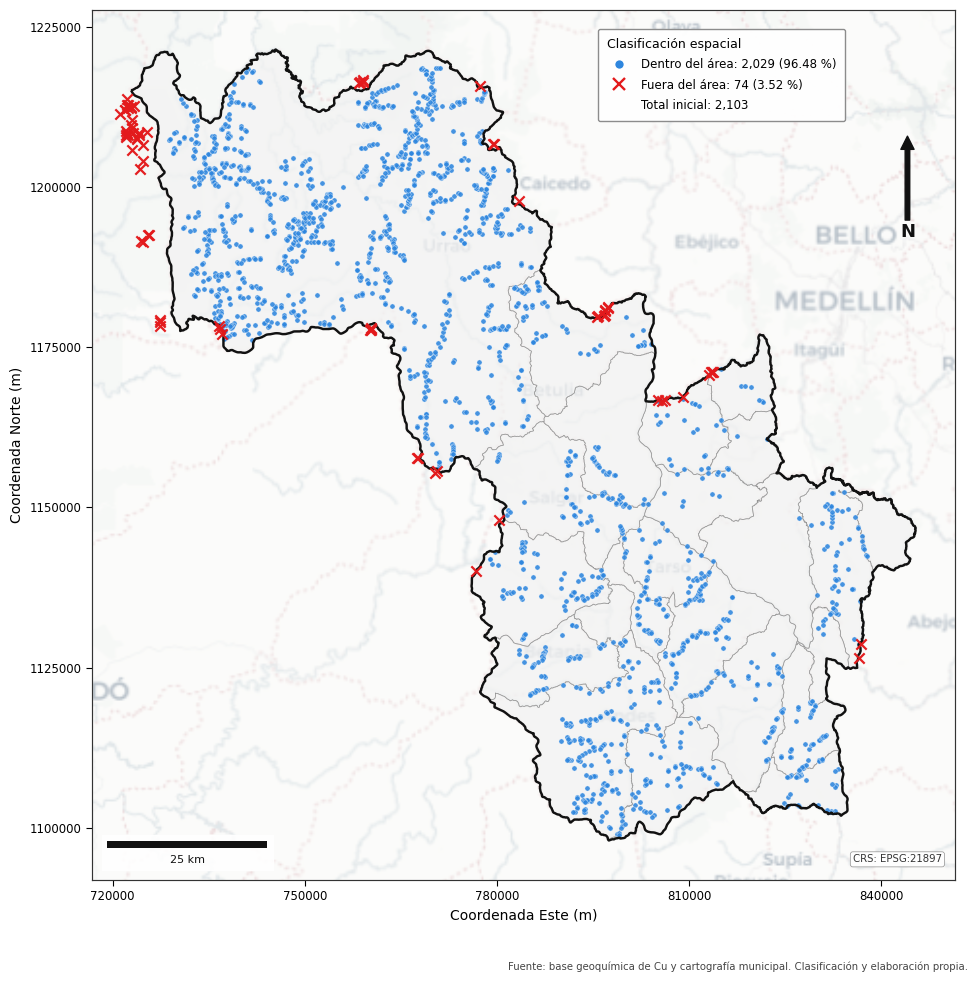

In [19]:
# ==========================================================
# FIGURA 01. DELIMITACIÓN ESPACIAL DEL ÁREA DE ANÁLISIS
# ==========================================================

import matplotlib.pyplot as plt
import contextily as ctx

from matplotlib.lines import Line2D
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.ticker import MaxNLocator, ScalarFormatter


# ----------------------------------------------------------
# 1. Preparar las capas
# ----------------------------------------------------------

municipios_mapa = municipios.copy()

# Total original: 2.103 muestras
muestras_totales_mapa = muestras_originales.copy()

# Conjunto final dentro del área: 2.029 muestras
muestras_dentro_mapa = muestras.copy()


# ----------------------------------------------------------
# 2. Eliminar geometrías nulas o vacías
# ----------------------------------------------------------

municipios_mapa = municipios_mapa[
    municipios_mapa.geometry.notna()
    & ~municipios_mapa.geometry.is_empty
].copy()

muestras_totales_mapa = muestras_totales_mapa[
    muestras_totales_mapa.geometry.notna()
    & ~muestras_totales_mapa.geometry.is_empty
].copy()

muestras_dentro_mapa = muestras_dentro_mapa[
    muestras_dentro_mapa.geometry.notna()
    & ~muestras_dentro_mapa.geometry.is_empty
].copy()


# ----------------------------------------------------------
# 3. Validar geometrías municipales
# ----------------------------------------------------------

municipios_mapa["geometry"] = (
    municipios_mapa.geometry.make_valid()
)


# ----------------------------------------------------------
# 4. Homogeneizar el sistema de referencia espacial
# ----------------------------------------------------------

crs_mapa = municipios_mapa.crs

if crs_mapa is None:
    raise ValueError(
        "La capa de municipios no tiene un CRS definido."
    )

if muestras_totales_mapa.crs is None:
    raise ValueError(
        "La capa original de muestras no tiene un CRS definido."
    )

if muestras_dentro_mapa.crs is None:
    raise ValueError(
        "La capa de muestras seleccionadas no tiene un CRS definido."
    )

if muestras_totales_mapa.crs != crs_mapa:
    muestras_totales_mapa = muestras_totales_mapa.to_crs(crs_mapa)

if muestras_dentro_mapa.crs != crs_mapa:
    muestras_dentro_mapa = muestras_dentro_mapa.to_crs(crs_mapa)


# ----------------------------------------------------------
# 5. Crear el polígono del área de estudio
# ----------------------------------------------------------

poligono_estudio = municipios_mapa.geometry.union_all()

limite_estudio = municipios_mapa.dissolve()


# ----------------------------------------------------------
# 6. Clasificar espacialmente las muestras originales
# ----------------------------------------------------------
# Se usa covers() para incluir puntos localizados exactamente
# sobre el límite del polígono.

mascara_dentro = muestras_totales_mapa.geometry.apply(
    lambda geometria: poligono_estudio.covers(geometria)
)

muestras_dentro_figura = muestras_totales_mapa[
    mascara_dentro
].copy()

muestras_fuera_figura = muestras_totales_mapa[
    ~mascara_dentro
].copy()


# ----------------------------------------------------------
# 7. Calcular cantidades
# ----------------------------------------------------------

total_inicial = len(muestras_totales_mapa)
total_dentro = len(muestras_dentro_figura)
total_fuera = len(muestras_fuera_figura)

porcentaje_dentro = (
    total_dentro / total_inicial * 100
)

porcentaje_fuera = (
    total_fuera / total_inicial * 100
)


# ----------------------------------------------------------
# 8. Verificar los valores esperados
# ----------------------------------------------------------

print("=" * 68)
print("VERIFICACIÓN DE LA CLASIFICACIÓN ESPACIAL")
print("=" * 68)
print(f"Total inicial : {total_inicial:,}")
print(f"Dentro del área: {total_dentro:,}")
print(f"Fuera del área : {total_fuera:,}")
print("=" * 68)

if total_inicial != 2103:
    print(
        f"Advertencia: se esperaban 2.103 muestras iniciales, "
        f"pero se encontraron {total_inicial:,}."
    )

if total_dentro != 2029:
    print(
        f"Advertencia: se esperaban 2.029 muestras dentro, "
        f"pero se encontraron {total_dentro:,}."
    )

if total_fuera != 74:
    print(
        f"Advertencia: se esperaban 74 muestras excluidas, "
        f"pero se encontraron {total_fuera:,}."
    )


# ----------------------------------------------------------
# 9. Calcular extensión del mapa
# ----------------------------------------------------------

xmin, ymin, xmax, ymax = municipios_mapa.total_bounds

margen_x = (xmax - xmin) * 0.05
margen_y = (ymax - ymin) * 0.05


# ----------------------------------------------------------
# 10. Crear la figura
# ----------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 10),
    facecolor="white"
)


# ----------------------------------------------------------
# 11. Dibujar los municipios
# ----------------------------------------------------------

municipios_mapa.plot(
    ax=ax,
    facecolor="#F2F2F2",
    edgecolor="#888888",
    linewidth=0.55,
    alpha=0.72,
    zorder=2
)


# ----------------------------------------------------------
# 12. Fijar extensión
# ----------------------------------------------------------

ax.set_xlim(
    xmin - margen_x,
    xmax + margen_x
)

ax.set_ylim(
    ymin - margen_y,
    ymax + margen_y
)


# ----------------------------------------------------------
# 13. Añadir mapa base
# ----------------------------------------------------------

try:
    ctx.add_basemap(
        ax,
        source=ctx.providers.CartoDB.Positron,
        crs=crs_mapa,
        zoom=9,
        attribution=False,
        alpha=0.65,
        zorder=1
    )

except Exception as error:
    print(
        "Advertencia: no fue posible cargar el mapa base."
    )
    print(error)


# Restaurar extensión
ax.set_xlim(
    xmin - margen_x,
    xmax + margen_x
)

ax.set_ylim(
    ymin - margen_y,
    ymax + margen_y
)


# ----------------------------------------------------------
# 14. Dibujar muestras dentro del área
# ----------------------------------------------------------

muestras_dentro_figura.plot(
    ax=ax,
    color="#2E86DE",
    marker="o",
    markersize=14,
    edgecolor="white",
    linewidth=0.30,
    alpha=0.88,
    zorder=4
)


# ----------------------------------------------------------
# 15. Dibujar muestras fuera del área
# ----------------------------------------------------------

muestras_fuera_figura.plot(
    ax=ax,
    color="#E31A1C",
    marker="x",
    markersize=55,
    linewidth=1.6,
    alpha=0.98,
    zorder=7
)


# ----------------------------------------------------------
# 16. Dibujar límite exterior
# ----------------------------------------------------------

limite_estudio.boundary.plot(
    ax=ax,
    color="#111111",
    linewidth=1.75,
    zorder=6
)


# ----------------------------------------------------------
# 17. Configurar ejes y coordenadas
# ----------------------------------------------------------

ax.set_aspect("equal")

ax.set_xlabel(
    "Coordenada Este (m)",
    fontsize=10
)

ax.set_ylabel(
    "Coordenada Norte (m)",
    fontsize=10
)

ax.xaxis.set_major_locator(
    MaxNLocator(nbins=5)
)

ax.yaxis.set_major_locator(
    MaxNLocator(nbins=6)
)

formato_coordenadas = ScalarFormatter(
    useOffset=False,
    useMathText=False
)

formato_coordenadas.set_scientific(False)

ax.xaxis.set_major_formatter(
    formato_coordenadas
)

ax.yaxis.set_major_formatter(
    formato_coordenadas
)

ax.tick_params(
    axis="both",
    labelsize=8.5,
    direction="out",
    length=4,
    width=0.8
)

ax.ticklabel_format(
    style="plain",
    axis="both",
    useOffset=False
)

ax.grid(False)


# ----------------------------------------------------------
# 18. Añadir flecha norte
# ----------------------------------------------------------

ax.annotate(
    "N",
    xy=(0.945, 0.855),
    xytext=(0.945, 0.745),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    color="#111111",
    arrowprops=dict(
        facecolor="#111111",
        edgecolor="#111111",
        width=3.3,
        headwidth=9.5,
        headlength=9.5
    ),
    zorder=10
)


# ----------------------------------------------------------
# 19. Añadir barra de escala
# ----------------------------------------------------------

barra_escala = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",
    location="lower left",
    length_fraction=0.22,
    width_fraction=0.008,
    box_alpha=0.90,
    box_color="white",
    color="#111111",
    font_properties={"size": 8},
    border_pad=0.7,
    pad=0.4
)

ax.add_artist(barra_escala)


# ----------------------------------------------------------
# 20. Añadir sistema de referencia
# ----------------------------------------------------------

epsg_mapa = crs_mapa.to_epsg()

if epsg_mapa is not None:
    texto_crs = f"CRS: EPSG:{epsg_mapa}"
else:
    texto_crs = f"CRS: {crs_mapa.name}"

ax.text(
    0.985,
    0.018,
    texto_crs,
    transform=ax.transAxes,
    fontsize=7.3,
    ha="right",
    va="bottom",
    color="#333333",
    bbox=dict(
        facecolor="white",
        edgecolor="#888888",
        linewidth=0.50,
        alpha=0.92,
        boxstyle="round,pad=0.25"
    ),
    zorder=10
)


# ----------------------------------------------------------
# 21. Crear leyenda con cantidades
# ----------------------------------------------------------

elementos_leyenda = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="#2E86DE",
        markeredgecolor="white",
        markersize=7,
        label=(
            f"Dentro del área: {total_dentro:,} "
            f"({porcentaje_dentro:.2f} %)"
        )
    ),
    Line2D(
        [0],
        [0],
        marker="x",
        linestyle="none",
        color="#E31A1C",
        markeredgewidth=1.7,
        markersize=8,
        label=(
            f"Fuera del área: {total_fuera:,} "
            f"({porcentaje_fuera:.2f} %)"
        )
    ),
    Line2D(
        [],
        [],
        linestyle="none",
        label=f"Total inicial: {total_inicial:,}"
    )
]

leyenda = ax.legend(
    handles=elementos_leyenda,
    loc="upper right",
    bbox_to_anchor=(0.88, 0.985),
    frameon=True,
    facecolor="white",
    edgecolor="#888888",
    framealpha=0.96,
    fontsize=8.5,
    title="Clasificación espacial",
    title_fontsize=9,
    borderpad=0.8,
    labelspacing=0.6
)

leyenda._legend_box.align = "left"


# ----------------------------------------------------------
# 22. Configurar marco
# ----------------------------------------------------------

for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_color("#333333")
    borde.set_linewidth(0.85)


# ----------------------------------------------------------
# 23. Añadir fuente
# ----------------------------------------------------------

fig.text(
    0.98,
    0.018,
    (
        "Fuente: base geoquímica de Cu y cartografía municipal. "
        "Clasificación y elaboración propia."
    ),
    ha="right",
    va="bottom",
    fontsize=7.3,
    color="#444444"
)


# ----------------------------------------------------------
# 24. Ajustar distribución
# ----------------------------------------------------------

fig.subplots_adjust(
    left=0.10,
    right=0.97,
    bottom=0.11,
    top=0.98
)


# ----------------------------------------------------------
# 25. Guardar únicamente en PNG
# ----------------------------------------------------------

ruta_figura_07 = (
    FIGURAS
    / "Figura_01_Delimitacion_Espacial_Area_Analisis.png"
)

fig.savefig(
    ruta_figura_07,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.12,
    facecolor="white"
)


# ----------------------------------------------------------
# 26. Confirmar guardado
# ----------------------------------------------------------

print("=" * 72)
print("FIGURA 01 GENERADA CORRECTAMENTE")
print("=" * 72)
print(f"Total inicial       : {total_inicial:,}")
print(f"Muestras dentro     : {total_dentro:,}")
print(f"Muestras excluidas  : {total_fuera:,}")
print("-" * 72)
print(f"PNG: {ruta_figura_07}")
print("=" * 72)

plt.show()

In [129]:
# ==========================================================
# TABLA 01. SELECCIÓN DE MUESTRAS PARA EL ÁREA DE ANÁLISIS
# ==========================================================

import pandas as pd


# ----------------------------------------------------------
# 1. Definir las cantidades del proceso de selección
# ----------------------------------------------------------

# Total original de la base geoquímica
total_inicial = 2103

# Muestras conservadas dentro del polígono
total_conservadas = len(muestras)

# Muestras excluidas del análisis
total_excluidas = total_inicial - total_conservadas


# ----------------------------------------------------------
# 2. Verificar los resultados esperados
# ----------------------------------------------------------

if total_conservadas != 2029:
    print(
        f"Advertencia: se esperaban 2.029 muestras conservadas, "
        f"pero la variable 'muestras' contiene {total_conservadas:,}."
    )

if total_excluidas < 0:
    raise ValueError(
        "El número de muestras conservadas es mayor que el total inicial."
    )


# ----------------------------------------------------------
# 3. Calcular porcentajes
# ----------------------------------------------------------

porcentaje_excluidas = (
    total_excluidas / total_inicial * 100
)

porcentaje_conservadas = (
    total_conservadas / total_inicial * 100
)


# ----------------------------------------------------------
# 4. Construir la Tabla 07
# ----------------------------------------------------------

tabla_07 = pd.DataFrame({
    "Etapa de selección": [
        "Total inicial de muestras",
        "Muestras excluidas del análisis",
        "Muestras conservadas para el análisis"
    ],
    "Criterio": [
        "Base geoquímica original",
        "Ubicación fuera del polígono del área de análisis",
        "Ubicación dentro del polígono del área de análisis"
    ],
    "Cantidad": [
        total_inicial,
        total_excluidas,
        total_conservadas
    ],
    "Porcentaje del total (%)": [
        100.00,
        porcentaje_excluidas,
        porcentaje_conservadas
    ]
})


# ----------------------------------------------------------
# 5. Mostrar la Tabla 01
# ----------------------------------------------------------

tabla_07_estilizada = (
    tabla_07.style
    .hide(axis="index")
    .set_caption(
        "Tabla 01. Selección de muestras para el área de análisis"
    )
    .format({
        "Cantidad": "{:,.0f}",
        "Porcentaje del total (%)": "{:.2f}"
    })
    .set_properties(
        subset=[
            "Cantidad",
            "Porcentaje del total (%)"
        ],
        **{"text-align": "center"}
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "13px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "1px solid #555555"),
                ("padding", "7px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "7px"),
                ("border-bottom", "1px solid #D9D9D9"),
                ("vertical-align", "top")
            ]
        }
    ])
)

display(tabla_01_estilizada)


# ----------------------------------------------------------
# 6. Guardar únicamente en CSV
# ----------------------------------------------------------

ruta_tabla_07 = (
    TABLAS
    / "Tabla_01_Seleccion_Muestras_Area_Analisis.csv"
)

tabla_07.to_csv(
    ruta_tabla_07,
    index=False,
    encoding="utf-8-sig"
)


# ----------------------------------------------------------
# 7. Confirmar resultados
# ----------------------------------------------------------

print("=" * 68)
print("TABLA 07 GENERADA CORRECTAMENTE")
print("=" * 68)

print(f"Total inicial       : {total_inicial:,}")
print(f"Muestras excluidas  : {total_excluidas:,}")
print(f"Muestras conservadas: {total_conservadas:,}")

print("-" * 68)
print(f"CSV: {ruta_tabla_07}")
print("=" * 68)

Capa,Descripción,Geometría,Registros,CRS
Muestras de Cu,Localización de muestras geoquímicas de cobre,Punto,"2,103",EPSG:21897
Fallas,Estructuras geológicas y tectónicas,Línea,475,EPSG:21897
Geología,Distribución de unidades litológicas,Polígono,658,EPSG:21897
Municipios,Divisiones administrativas del área de estudio,Polígono,23,EPSG:21897


TABLA 07 GENERADA CORRECTAMENTE
Total inicial       : 2,103
Muestras excluidas  : 74
Muestras conservadas: 2,029
--------------------------------------------------------------------
CSV: /content/drive/MyDrive/Analisis_Geoespacial_Cobre/04_Resultados/01_Tablas/Tabla_01_Seleccion_Muestras_Area_Analisis.csv


De las 2103 muestras disponibles, 2029 (96.48%) se localizaron dentro del límite del área de estudio y fueron seleccionadas para los análisis  posteriores. Las 74 muestras restantes (3.52%), ubicadas fuera del dominio espacial definido, fueron excluidas de la interpolación y almacenadas en una capa independiente para mantener la trazabilidad del procesamiento.

In [ ]:
# ==========================================================
# DELIMITACIÓN ESPACIAL Y DEFINICIÓN DEL CONJUNTO OFICIAL
# ==========================================================

import geopandas as gpd


# ----------------------------------------------------------
# 1. Cargar la base original completa
# ----------------------------------------------------------

muestras_originales = gpd.read_file(
    PROCESADOS / "Muestras_Cu.gpkg"
)

municipios_delimitacion = municipios.copy()


# ----------------------------------------------------------
# 2. Homogeneizar el sistema de referencia espacial
# ----------------------------------------------------------

if muestras_originales.crs is None:
    raise ValueError(
        "La capa original de muestras no tiene un CRS definido."
    )

if municipios_delimitacion.crs is None:
    raise ValueError(
        "La capa de municipios no tiene un CRS definido."
    )

if muestras_originales.crs != municipios_delimitacion.crs:
    muestras_originales = muestras_originales.to_crs(
        municipios_delimitacion.crs
    )


# ----------------------------------------------------------
# 3. Crear el polígono único del área de estudio
# ----------------------------------------------------------

poligono_estudio = (
    municipios_delimitacion
    .geometry
    .union_all()
)


# ----------------------------------------------------------
# 4. Clasificar las muestras
# ----------------------------------------------------------
# covers() incluye las muestras localizadas exactamente
# sobre el límite del polígono.

mascara_dentro = muestras_originales.geometry.apply(
    lambda geometria: poligono_estudio.covers(geometria)
)

muestras_estudio = muestras_originales[
    mascara_dentro
].copy()

muestras_fuera = muestras_originales[
    ~mascara_dentro
].copy()


# ----------------------------------------------------------
# 5. Conservar trazabilidad y definir el conjunto oficial
# ----------------------------------------------------------

muestras_totales = muestras_originales.copy()

# A partir de este punto, todos los códigos que utilicen
# la variable "muestras" trabajarán únicamente con los
# registros ubicados dentro del polígono.
muestras = muestras_estudio.copy()


# ----------------------------------------------------------
# 6. Verificar cantidades
# ----------------------------------------------------------

total_original = len(muestras_totales)
total_dentro = len(muestras)
total_fuera = len(muestras_fuera)
total_verificacion = total_dentro + total_fuera

print("=" * 68)
print("DELIMITACIÓN ESPACIAL COMPLETADA")
print("=" * 68)
print(f"Total original             : {total_original:,}")
print(f"Dentro del área            : {total_dentro:,}")
print(f"Fuera del área             : {total_fuera:,}")
print(f"Verificación de la suma    : {total_verificacion:,}")
print(f"Conjunto oficial de análisis: {len(muestras):,}")
print("=" * 68)


# ----------------------------------------------------------
# 7. Validar los resultados esperados
# ----------------------------------------------------------

if total_original != 2103:
    print(
        f"Advertencia: se esperaban 2.103 muestras originales, "
        f"pero se encontraron {total_original:,}."
    )

if total_dentro != 2029:
    print(
        f"Advertencia: se esperaban 2.029 muestras dentro del área, "
        f"pero se encontraron {total_dentro:,}."
    )

if total_fuera != 74:
    print(
        f"Advertencia: se esperaban 74 muestras excluidas, "
        f"pero se encontraron {total_fuera:,}."
    )

if total_verificacion != total_original:
    raise ValueError(
        "La suma de las muestras dentro y fuera del área "
        "no coincide con el total original."
    )

DELIMITACIÓN ESPACIAL COMPLETADA
Total original             : 2,103
Dentro del área            : 2,029
Fuera del área             : 74
Verificación de la suma    : 2,103
Conjunto oficial de análisis: 2,029


# 2. Introducción a los datos espaciales

En esta sección se presenta la caracterización espacial de la información utilizada en el estudio, siguiendo los fundamentos expuestos en la Parte I del libro guía Análisis Geoespacial. Se describen la naturaleza de los datos, el modelo de representación espacial, los tipos de geometría y las relaciones existentes entre las diferentes capas geográficas empleadas en el análisis. Esta caracterización constituye la base conceptual para los procedimientos de exploración espacial y geoestadística desarrollados en las secciones posteriores.

##2.1 Descripción del conjunto de datos


Se identifican las capas espaciales utilizadas en el estudio y se resumen sus principales características, incluyendo el fenómeno representado, el tipo de geometría, el número de entidades y el sistema de referencia espacial.

In [146]:
# ==========================================================
# TABLA 02. CARACTERIZACIÓN GENERAL DE LAS CAPAS ESPACIALES
# ==========================================================

import pandas as pd
import geopandas as gpd

from pathlib import Path


# ----------------------------------------------------------
# 1. Función para identificar el tipo general de geometría
# ----------------------------------------------------------

def identificar_geometria(gdf):
    """
    Identifica el tipo general de geometría de una capa:
    Punto, Línea, Polígono o Mixta.
    """

    if not isinstance(gdf, gpd.GeoDataFrame):
        return "No espacial"

    if gdf.geometry.name not in gdf.columns:
        return "Sin geometría"

    tipos = (
        gdf.geometry
        .dropna()
        .loc[lambda serie: ~serie.is_empty]
        .geom_type
        .unique()
        .tolist()
    )

    if len(tipos) == 0:
        return "Sin geometría"

    equivalencias = {
        "Point": "Punto",
        "MultiPoint": "Punto",
        "LineString": "Línea",
        "MultiLineString": "Línea",
        "Polygon": "Polígono",
        "MultiPolygon": "Polígono",
        "GeometryCollection": "Colección geométrica"
    }

    tipos_generales = sorted({
        equivalencias.get(tipo, tipo)
        for tipo in tipos
    })

    if len(tipos_generales) == 1:
        return tipos_generales[0]

    return "Mixta: " + ", ".join(tipos_generales)


# ----------------------------------------------------------
# 2. Función para resumir el sistema de referencia
# ----------------------------------------------------------

def describir_crs(gdf):
    """
    Devuelve el código EPSG asociado a la capa.
    """

    if not isinstance(gdf, gpd.GeoDataFrame):
        return "No aplica"

    if gdf.crs is None:
        return "No definido"

    epsg = gdf.crs.to_epsg()

    if epsg is not None:
        return f"EPSG:{epsg}"

    return gdf.crs.name or "CRS sin código EPSG"


# ----------------------------------------------------------
# 3. Verificar que las capas necesarias estén cargadas
# ----------------------------------------------------------

nombres_capas_requeridas = [
    "muestras",
    "fallas",
    "geologia",
    "municipios"
]

capas_faltantes = [
    nombre
    for nombre in nombres_capas_requeridas
    if nombre not in globals()
]

if capas_faltantes:
    raise NameError(
        "No se encontraron las siguientes capas en memoria: "
        + ", ".join(capas_faltantes)
    )


capas_requeridas = {
    "muestras": muestras,
    "fallas": fallas,
    "geologia": geologia,
    "municipios": municipios
}

for nombre, capa in capas_requeridas.items():

    if capa is None:
        raise ValueError(
            f"La capa '{nombre}' no está disponible."
        )

    if not isinstance(capa, gpd.GeoDataFrame):
        raise TypeError(
            f"La capa '{nombre}' debe ser un GeoDataFrame."
        )


# ----------------------------------------------------------
# 4. Definir la información temática de las capas
# ----------------------------------------------------------

capas_espaciales = [
    {
        "Capa": "Muestras de Cu",
        "Descripción":
            "Localización de muestras geoquímicas de cobre",
        "Objeto": muestras
    },
    {
        "Capa": "Fallas",
        "Descripción":
            "Estructuras geológicas y tectónicas",
        "Objeto": fallas
    },
    {
        "Capa": "Geología",
        "Descripción":
            "Distribución de unidades litológicas",
        "Objeto": geologia
    },
    {
        "Capa": "Municipios",
        "Descripción":
            "Divisiones administrativas del área de estudio",
        "Objeto": municipios
    }
]


# ----------------------------------------------------------
# 5. Construir automáticamente la Tabla 02
# ----------------------------------------------------------

registros_tabla_02 = []

for capa in capas_espaciales:

    gdf = capa["Objeto"]

    registros_tabla_02.append({
        "Capa": capa["Capa"],
        "Descripción": capa["Descripción"],
        "Geometría": identificar_geometria(gdf),
        "Registros": len(gdf),
        "CRS": describir_crs(gdf)
    })


tabla_02 = pd.DataFrame(
    registros_tabla_02
)


# ----------------------------------------------------------
# 6. Verificar el contenido de la Tabla 02
# ----------------------------------------------------------

if len(tabla_02) != len(capas_espaciales):
    raise ValueError(
        "La cantidad de filas generadas no coincide con "
        "la cantidad de capas espaciales definidas."
    )

if tabla_02["Capa"].duplicated().any():
    capas_duplicadas = (
        tabla_02.loc[
            tabla_02["Capa"].duplicated(keep=False),
            "Capa"
        ]
        .unique()
        .tolist()
    )

    raise ValueError(
        "Se encontraron capas duplicadas en la Tabla 02: "
        + ", ".join(capas_duplicadas)
    )


# ----------------------------------------------------------
# 7. Mostrar la tabla en el notebook
# ----------------------------------------------------------

tabla_02_estilizada = (
    tabla_02.style
    .hide(axis="index")
    .set_caption(
        "Tabla 02. Caracterización general "
        "de las capas espaciales"
    )
    .format({
        "Registros": "{:,.0f}"
    })
    .set_properties(
        subset=["Registros", "Geometría", "CRS"],
        **{
            "text-align": "center"
        }
    )
    .set_properties(
        subset=["Descripción"],
        **{
            "text-align": "left"
        }
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "13px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "1px solid #555555"),
                ("padding", "7px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "7px"),
                ("border-bottom", "1px solid #D9D9D9"),
                ("vertical-align", "top")
            ]
        }
    ])
)

display(tabla_02_estilizada)


# ----------------------------------------------------------
# 8. Verificar la carpeta de salida
# ----------------------------------------------------------

if "TABLAS" not in globals():
    raise NameError(
        "La variable TABLAS no está definida. "
        "Ejecuta primero la celda 0.1 de rutas del proyecto."
    )

TABLAS = Path(TABLAS)

TABLAS.mkdir(
    parents=True,
    exist_ok=True
)


# ----------------------------------------------------------
# 9. Exportar la Tabla 02 únicamente en CSV
# ----------------------------------------------------------

ruta_csv_tabla_02 = (
    TABLAS
    / "Tabla_02_Caracterizacion_Capas_Espaciales.csv"
)

tabla_02.to_csv(
    ruta_csv_tabla_02,
    index=False,
    encoding="utf-8-sig"
)


# ----------------------------------------------------------
# 10. Confirmar la exportación
# ----------------------------------------------------------

if not ruta_csv_tabla_02.exists():
    raise FileNotFoundError(
        "La Tabla 02 no pudo guardarse en la ruta indicada."
    )

print("=" * 68)
print("TABLA 02 GENERADA Y GUARDADA CORRECTAMENTE")
print("=" * 68)

print(
    f"Capas registradas : "
    f"{len(tabla_02):,}"
)

print(
    f"CSV               : "
    f"{ruta_csv_tabla_02}"
)

print("=" * 68)

Capa,Descripción,Geometría,Registros,CRS
Muestras de Cu,Localización de muestras geoquímicas de cobre,Punto,"2,029",EPSG:21897
Fallas,Estructuras geológicas y tectónicas,Línea,475,EPSG:21897
Geología,Distribución de unidades litológicas,Polígono,658,EPSG:21897
Municipios,Divisiones administrativas del área de estudio,Polígono,23,EPSG:21897


TABLA 02 GENERADA Y GUARDADA CORRECTAMENTE
Capas registradas : 4
CSV               : /content/drive/MyDrive/Analisis_Geoespacial_Cobre/04_Resultados/01_Tablas/Tabla_02_Caracterizacion_Capas_Espaciales.csv


La Tabla 02 resume las principales características de las capas espaciales utilizadas en el estudio. El conjunto de datos está conformado por cuatro capas vectoriales que representan información geoquímica, geológica y administrativa del área de estudio. Estas capas constituyen la base para el análisis espacial y la posterior modelación geoestadística de la concentración de cobre.

In [22]:
# ==========================================================
# INSTALAR DEPENDENCIA PARA LA BARRA DE ESCALA
# ==========================================================

!pip -q install matplotlib-scalebar

print("matplotlib-scalebar instalado correctamente.")

matplotlib-scalebar instalado correctamente.


FIGURA 02 GUARDADA CORRECTAMENTE
Archivo: /content/drive/MyDrive/Analisis_Geoespacial_Cobre/03_Figuras/Figura_02_Representacion_Integrada_Capas_Espaciales.png


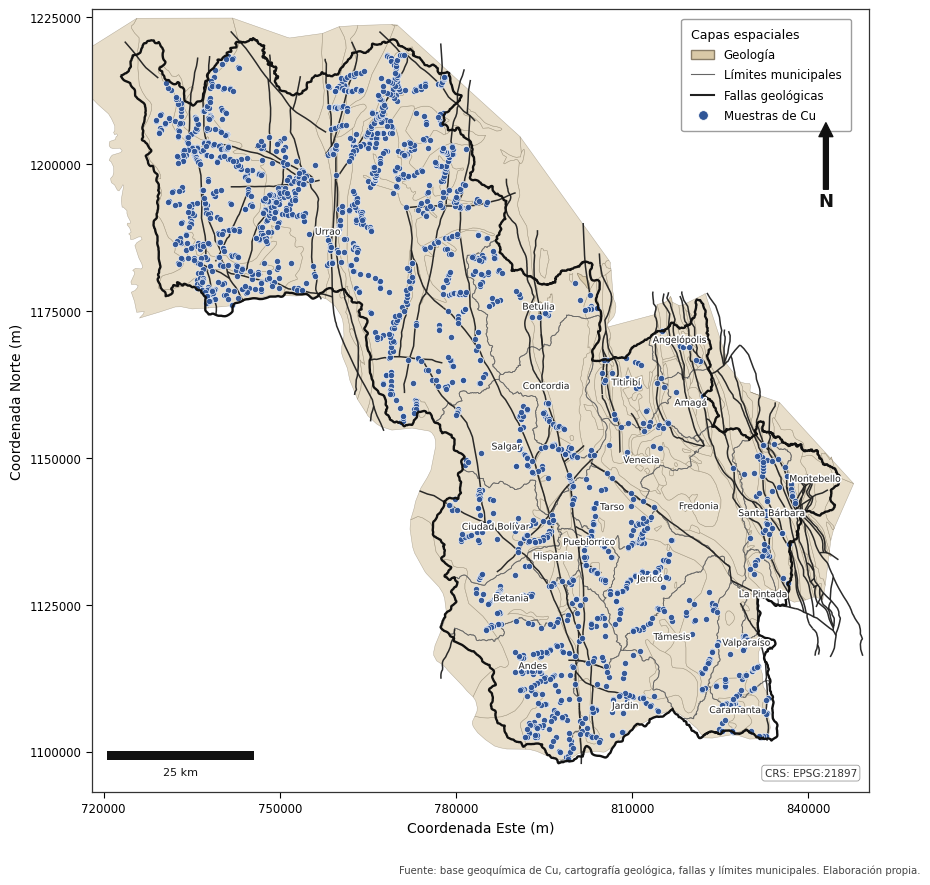

In [134]:
# ==========================================================
# FIGURA 02. REPRESENTACIÓN INTEGRADA DE LAS CAPAS ESPACIALES
# ==========================================================

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.ticker import MaxNLocator, ScalarFormatter
import matplotlib.patheffects as pe


# ----------------------------------------------------------
# 1. Preparar copias de las capas
# ----------------------------------------------------------

municipios_fig = municipios.copy()
geologia_fig = geologia.copy()
fallas_fig = fallas.copy()
muestras_fig = muestras.copy()


# ----------------------------------------------------------
# 2. Eliminar geometrías nulas o vacías
# ----------------------------------------------------------

municipios_fig = municipios_fig[
    municipios_fig.geometry.notna()
    & ~municipios_fig.geometry.is_empty
].copy()

geologia_fig = geologia_fig[
    geologia_fig.geometry.notna()
    & ~geologia_fig.geometry.is_empty
].copy()

fallas_fig = fallas_fig[
    fallas_fig.geometry.notna()
    & ~fallas_fig.geometry.is_empty
].copy()

muestras_fig = muestras_fig[
    muestras_fig.geometry.notna()
    & ~muestras_fig.geometry.is_empty
].copy()


# ----------------------------------------------------------
# 3. Homogeneizar el sistema de referencia espacial
# ----------------------------------------------------------

crs_mapa = municipios_fig.crs

if crs_mapa is None:
    raise ValueError(
        "La capa de municipios no tiene un sistema "
        "de referencia espacial definido."
    )

if geologia_fig.crs != crs_mapa:
    geologia_fig = geologia_fig.to_crs(crs_mapa)

if fallas_fig.crs != crs_mapa:
    fallas_fig = fallas_fig.to_crs(crs_mapa)

if muestras_fig.crs != crs_mapa:
    muestras_fig = muestras_fig.to_crs(crs_mapa)


# ----------------------------------------------------------
# 4. Crear límite exterior del área de estudio
# ----------------------------------------------------------

limite_estudio = municipios_fig.dissolve()


# ----------------------------------------------------------
# 5. Identificar la columna con nombres municipales
# ----------------------------------------------------------

columnas_nombre = [
    "NOMBRE",
    "NOMBRE_MPIO",
    "MPIO_CNMBR",
    "MUNICIPIO",
    "NOM_MPIO",
    "NOM_MUNIC"
]

columna_nombre = next(
    (
        columna
        for columna in columnas_nombre
        if columna in municipios_fig.columns
    ),
    None
)

if columna_nombre is not None:

    municipios_fig["NOMBRE_MAPA"] = (
        municipios_fig[columna_nombre]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )

else:

    municipios_fig["NOMBRE_MAPA"] = ""


# ----------------------------------------------------------
# 6. Corregir nombres municipales abreviados
# ----------------------------------------------------------

nombres_corregidos = {
    "S.BARBA": "Santa Bárbara",
    "C.BOLIV": "Ciudad Bolívar",
    "P.RICO": "Pueblorrico",
    "MONTEBE": "Montebello",
    "TITIRIB": "Titiribí",
    "TAMESIS": "Támesis",
    "JERICO": "Jericó",
    "HISPANI": "Hispania",
    "FREDONI": "Fredonia",
    "ANGELOP": "Angelópolis",
    "CARAMAN": "Caramanta",
    "VALPARA": "Valparaíso",
    "CONCORD": "Concordia",
    "PINTADA": "La Pintada"
}

municipios_fig["NOMBRE_MAPA"] = (
    municipios_fig["NOMBRE_MAPA"]
    .replace(nombres_corregidos)
)

municipios_fig["NOMBRE_MAPA"] = municipios_fig[
    "NOMBRE_MAPA"
].apply(
    lambda nombre: nombre.title()
    if nombre and nombre == nombre.upper()
    else nombre
)


# ----------------------------------------------------------
# 7. Calcular la extensión del mapa
# ----------------------------------------------------------

xmin, ymin, xmax, ymax = municipios_fig.total_bounds

rango_x = xmax - xmin
rango_y = ymax - ymin

margen_x = rango_x * 0.04
margen_y = rango_y * 0.04


# ----------------------------------------------------------
# 8. Crear la figura
# ----------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 9)
)


# ----------------------------------------------------------
# 9. Representar la geología
# ----------------------------------------------------------

geologia_fig.plot(
    ax=ax,
    facecolor="#D9C9A7",
    edgecolor="#8A7E68",
    linewidth=0.35,
    alpha=0.60,
    zorder=1
)


# ----------------------------------------------------------
# 10. Representar los límites municipales
# ----------------------------------------------------------

municipios_fig.boundary.plot(
    ax=ax,
    color="#666666",
    linewidth=0.60,
    alpha=0.90,
    zorder=2
)


# ----------------------------------------------------------
# 11. Representar las fallas geológicas
# ----------------------------------------------------------

fallas_fig.plot(
    ax=ax,
    color="#202020",
    linewidth=1.10,
    alpha=0.95,
    zorder=3
)


# ----------------------------------------------------------
# 12. Representar las muestras de cobre
# ----------------------------------------------------------

muestras_fig.plot(
    ax=ax,
    color="#2F5597",
    markersize=20,
    marker="o",
    edgecolor="white",
    linewidth=0.45,
    alpha=0.95,
    zorder=4
)


# ----------------------------------------------------------
# 13. Resaltar el límite exterior del área de estudio
# ----------------------------------------------------------

limite_estudio.boundary.plot(
    ax=ax,
    color="#111111",
    linewidth=1.70,
    zorder=5
)


# ----------------------------------------------------------
# 14. Añadir etiquetas municipales
# ----------------------------------------------------------

for _, fila in municipios_fig.iterrows():

    nombre = fila["NOMBRE_MAPA"]

    if not nombre:
        continue

    punto = fila.geometry.representative_point()

    texto = ax.text(
        punto.x,
        punto.y,
        nombre,
        fontsize=6.7,
        ha="center",
        va="center",
        color="#222222",
        zorder=6
    )

    texto.set_path_effects([
        pe.withStroke(
            linewidth=2.2,
            foreground="white"
        )
    ])


# ----------------------------------------------------------
# 15. Configurar extensión y proporción
# ----------------------------------------------------------

ax.set_xlim(
    xmin - margen_x,
    xmax + margen_x
)

ax.set_ylim(
    ymin - margen_y,
    ymax + margen_y
)

ax.set_aspect("equal")


# ----------------------------------------------------------
# 16. Configurar las coordenadas
# ----------------------------------------------------------

ax.set_xlabel(
    "Coordenada Este (m)",
    fontsize=10
)

ax.set_ylabel(
    "Coordenada Norte (m)",
    fontsize=10
)

ax.xaxis.set_major_locator(
    MaxNLocator(nbins=5)
)

ax.yaxis.set_major_locator(
    MaxNLocator(nbins=6)
)

formato_coordenadas = ScalarFormatter(
    useOffset=False,
    useMathText=False
)

formato_coordenadas.set_scientific(False)

ax.xaxis.set_major_formatter(
    formato_coordenadas
)

ax.yaxis.set_major_formatter(
    formato_coordenadas
)

ax.tick_params(
    axis="both",
    labelsize=8.5,
    direction="out",
    length=4,
    width=0.8
)

ax.ticklabel_format(
    style="plain",
    axis="both",
    useOffset=False
)


# ----------------------------------------------------------
# 17. Añadir flecha norte
# ----------------------------------------------------------

ax.annotate(
    "N",
    xy=(0.945, 0.855),
    xytext=(0.945, 0.755),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    color="#111111",
    arrowprops=dict(
        facecolor="#111111",
        edgecolor="#111111",
        width=3.5,
        headwidth=10,
        headlength=10
    ),
    zorder=10
)


# ----------------------------------------------------------
# 18. Añadir barra de escala
# ----------------------------------------------------------

barra_escala = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",
    location="lower left",
    length_fraction=0.22,
    width_fraction=0.012,
    box_alpha=0.90,
    box_color="white",
    color="#111111",
    font_properties={"size": 8},
    border_pad=0.7,
    pad=0.4
)

ax.add_artist(barra_escala)


# ----------------------------------------------------------
# 19. Crear la leyenda
# ----------------------------------------------------------

elementos_leyenda = [
    Patch(
        facecolor="#D9C9A7",
        edgecolor="#8A7E68",
        label="Geología"
    ),
    Line2D(
        [0],
        [0],
        color="#666666",
        linewidth=0.8,
        label="Límites municipales"
    ),
    Line2D(
        [0],
        [0],
        color="#202020",
        linewidth=1.5,
        label="Fallas geológicas"
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="#2F5597",
        markeredgecolor="white",
        markeredgewidth=0.6,
        markersize=7,
        label="Muestras de Cu"
    )
]

leyenda = ax.legend(
    handles=elementos_leyenda,
    loc="upper right",
    bbox_to_anchor=(0.985, 0.995),
    frameon=True,
    facecolor="white",
    edgecolor="#999999",
    framealpha=0.96,
    fontsize=8.5,
    title="Capas espaciales",
    title_fontsize=9,
    borderpad=0.8,
    labelspacing=0.6
)

leyenda._legend_box.align = "left"


# ----------------------------------------------------------
# 20. Añadir sistema de referencia espacial
# ----------------------------------------------------------

epsg_mapa = crs_mapa.to_epsg()

if epsg_mapa is not None:
    texto_crs = f"CRS: EPSG:{epsg_mapa}"
else:
    texto_crs = f"CRS: {crs_mapa.name}"

ax.text(
    0.985,
    0.018,
    texto_crs,
    transform=ax.transAxes,
    fontsize=7.5,
    ha="right",
    va="bottom",
    color="#333333",
    bbox=dict(
        facecolor="white",
        edgecolor="#888888",
        linewidth=0.55,
        alpha=0.92,
        boxstyle="round,pad=0.28"
    ),
    zorder=10
)


# ----------------------------------------------------------
# 21. Configurar el marco cartográfico
# ----------------------------------------------------------

for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_color("#333333")
    borde.set_linewidth(0.9)

ax.grid(False)


# ----------------------------------------------------------
# 22. Añadir fuente de los datos
# ----------------------------------------------------------

fig.text(
    0.98,
    0.018,
    (
        "Fuente: base geoquímica de Cu, cartografía geológica, "
        "fallas y límites municipales. Elaboración propia."
    ),
    ha="right",
    va="bottom",
    fontsize=7.3,
    color="#444444"
)


# ----------------------------------------------------------
# 23. Ajustar el espacio de la figura
# ----------------------------------------------------------

fig.subplots_adjust(
    left=0.11,
    right=0.97,
    bottom=0.11,
    top=0.98
)


# ----------------------------------------------------------
# 24. Guardar únicamente en formato PNG
# ----------------------------------------------------------

nombre_archivo = (
    "Figura_02_Representacion_Integrada_"
    "Capas_Espaciales.png"
)

ruta_png = FIGURAS / nombre_archivo

fig.savefig(
    ruta_png,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.12,
    facecolor="white"
)

print("=" * 68)
print("FIGURA 02 GUARDADA CORRECTAMENTE")
print("=" * 68)
print(f"Archivo: {ruta_png}")
print("=" * 68)

plt.show()

**Figura 02.** Representación integrada de las capas espaciales utilizadas en el estudio.


La figura presenta conjuntamente las muestras geoquímicas de cobre, las fallas geológicas, la cartografía geológica y los límites municipales del suroeste antioqueño. Esta integración permite reconocer la distribución general de la información disponible y constituye la base para los análisis espaciales posteriores.

##2.2 Componentes del dato espacial


Se identifican los componentes espaciales y temáticos de las capas utilizadas en el estudio, relacionando cada tipo de geometría con los atributos que describen el fenómeno representado.

In [147]:
# ==========================================================
# TABLA 03. COMPONENTES ESPACIALES Y TEMÁTICOS DE LAS CAPAS
# ==========================================================

import pandas as pd
import geopandas as gpd

from pathlib import Path


# ----------------------------------------------------------
# 1. Verificar que las capas necesarias estén cargadas
# ----------------------------------------------------------

nombres_capas_requeridas = [
    "muestras",
    "fallas",
    "geologia",
    "municipios"
]

capas_faltantes = [
    nombre
    for nombre in nombres_capas_requeridas
    if nombre not in globals()
]

if capas_faltantes:
    raise NameError(
        "No se encontraron las siguientes capas en memoria: "
        + ", ".join(capas_faltantes)
    )


capas_requeridas = {
    "muestras": muestras,
    "fallas": fallas,
    "geologia": geologia,
    "municipios": municipios
}

for nombre, capa in capas_requeridas.items():

    if capa is None:
        raise ValueError(
            f"La capa '{nombre}' no está disponible."
        )

    if not isinstance(capa, gpd.GeoDataFrame):
        raise TypeError(
            f"La capa '{nombre}' debe ser un GeoDataFrame."
        )


# ----------------------------------------------------------
# 2. Función para resumir los atributos disponibles
# ----------------------------------------------------------

def resumir_atributos(gdf, max_atributos=5):
    """
    Devuelve una lista resumida de los atributos no geométricos
    disponibles en un GeoDataFrame.
    """

    if not isinstance(gdf, gpd.GeoDataFrame):
        return "No aplica"

    try:
        columna_geometria = gdf.geometry.name
    except AttributeError:
        columna_geometria = None

    atributos = [
        str(columna)
        for columna in gdf.columns
        if columna != columna_geometria
    ]

    if len(atributos) == 0:
        return "Sin atributos temáticos"

    if len(atributos) <= max_atributos:
        return ", ".join(atributos)

    return (
        ", ".join(atributos[:max_atributos])
        + ", ..."
    )


# ----------------------------------------------------------
# 3. Definir la función de cada capa en el proyecto
# ----------------------------------------------------------

componentes_capas = [
    {
        "Capa": "Muestras de Cu",
        "Objeto": muestras,
        "Componente espacial": (
            "Localización puntual de cada muestra geoquímica"
        ),
        "Componente temático principal": (
            "Concentración de cobre (Cu)"
        )
    },
    {
        "Capa": "Fallas",
        "Objeto": fallas,
        "Componente espacial": (
            "Trazado lineal de estructuras geológicas"
        ),
        "Componente temático principal": (
            "Identificación y características de las fallas"
        )
    },
    {
        "Capa": "Geología",
        "Objeto": geologia,
        "Componente espacial": (
            "Polígonos que delimitan unidades geológicas"
        ),
        "Componente temático principal": (
            "Código, unidad y descripción litológica"
        )
    },
    {
        "Capa": "Municipios",
        "Objeto": municipios,
        "Componente espacial": (
            "Polígonos que delimitan divisiones administrativas"
        ),
        "Componente temático principal": (
            "Nombre e identificación municipal"
        )
    }
]


# ----------------------------------------------------------
# 4. Construir automáticamente la Tabla 03
# ----------------------------------------------------------

registros_tabla_03 = []

for capa in componentes_capas:

    gdf = capa["Objeto"]

    registros_tabla_03.append({
        "Capa": capa["Capa"],
        "Componente espacial":
            capa["Componente espacial"],
        "Componente temático principal":
            capa["Componente temático principal"],
        "Atributos disponibles":
            resumir_atributos(gdf)
    })


tabla_03 = pd.DataFrame(
    registros_tabla_03
)


# ----------------------------------------------------------
# 5. Verificar el contenido de la Tabla 03
# ----------------------------------------------------------

if len(tabla_03) != len(componentes_capas):
    raise ValueError(
        "La cantidad de filas generadas no coincide con "
        "la cantidad de capas definidas."
    )

if tabla_03["Capa"].duplicated().any():

    capas_duplicadas = (
        tabla_03.loc[
            tabla_03["Capa"].duplicated(keep=False),
            "Capa"
        ]
        .unique()
        .tolist()
    )

    raise ValueError(
        "Se encontraron capas duplicadas en la Tabla 03: "
        + ", ".join(capas_duplicadas)
    )


# ----------------------------------------------------------
# 6. Mostrar la tabla en el notebook
# ----------------------------------------------------------

tabla_03_estilizada = (
    tabla_03.style
    .hide(axis="index")
    .set_caption(
        "Tabla 03. Componentes espaciales y temáticos "
        "de las capas del estudio"
    )
    .set_properties(
        subset=["Capa"],
        **{
            "font-weight": "bold",
            "text-align": "left"
        }
    )
    .set_properties(
        subset=[
            "Componente espacial",
            "Componente temático principal",
            "Atributos disponibles"
        ],
        **{
            "text-align": "left",
            "vertical-align": "top"
        }
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "13px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "1px solid #555555"),
                ("padding", "7px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "7px"),
                ("border-bottom", "1px solid #D9D9D9"),
                ("vertical-align", "top")
            ]
        }
    ])
)

display(tabla_03_estilizada)


# ----------------------------------------------------------
# 7. Verificar la carpeta de salida
# ----------------------------------------------------------

if "TABLAS" not in globals():
    raise NameError(
        "La variable TABLAS no está definida. "
        "Ejecuta primero la celda 0.1 de rutas del proyecto."
    )

TABLAS = Path(TABLAS)

TABLAS.mkdir(
    parents=True,
    exist_ok=True
)


# ----------------------------------------------------------
# 8. Exportar la Tabla 03 únicamente en CSV
# ----------------------------------------------------------

ruta_csv_tabla_03 = (
    TABLAS
    / "Tabla_03_Componentes_Espaciales_Tematicos.csv"
)

tabla_03.to_csv(
    ruta_csv_tabla_03,
    index=False,
    encoding="utf-8-sig"
)


# ----------------------------------------------------------
# 9. Confirmar la exportación
# ----------------------------------------------------------

if not ruta_csv_tabla_03.exists():
    raise FileNotFoundError(
        "La Tabla 03 no pudo guardarse "
        "en la ruta indicada."
    )

print("=" * 70)
print("TABLA 03 GENERADA Y GUARDADA CORRECTAMENTE")
print("=" * 70)

print(
    f"Capas registradas : "
    f"{len(tabla_03):,}"
)

print(
    f"CSV               : "
    f"{ruta_csv_tabla_03}"
)

print("=" * 70)

Capa,Componente espacial,Componente temático principal,Atributos disponibles
Muestras de Cu,Localización puntual de cada muestra geoquímica,Concentración de cobre (Cu),"Y, X, Cu"
Fallas,Trazado lineal de estructuras geológicas,Identificación y características de las fallas,"FID_1, OBJECTID, SHAPE_Leng, Tipo, NombreFall, ..."
Geología,Polígonos que delimitan unidades geológicas,"Código, unidad y descripción litológica","ENTITY, DESCRIPTIO, DESCRIPCIO, UNIDAD_DES"
Municipios,Polígonos que delimitan divisiones administrativas,Nombre e identificación municipal,"NOMBRE, Shape_Leng, Shape_Area"


TABLA 03 GENERADA Y GUARDADA CORRECTAMENTE
Capas registradas : 4
CSV               : /content/drive/MyDrive/Analisis_Geoespacial_Cobre/04_Resultados/01_Tablas/Tabla_03_Componentes_Espaciales_Tematicos.csv


**Tabla 03.** Componentes espaciales y temáticos de las capas del estudio.

La Tabla 03 evidencia que todas las capas empleadas en el estudio integran un componente espacial, representado por su geometría, y un componente temático, conformado por los atributos descriptivos asociados a cada entidad. Esta estructura permite relacionar la localización geográfica con la información temática, constituyendo la base para el análisis geoespacial desarrollado en las siguientes secciones.

##2.3 Modelo de datos espaciales


En esta sección se identifica el modelo de datos espaciales empleado en el estudio y se presenta la forma en que los diferentes fenómenos geográficos son representados mediante entidades vectoriales. Para ello, se relacionan las capas utilizadas con su tipo de geometría y se ilustra la representación de puntos, líneas y polígonos dentro del área de estudio.

In [149]:
# ==========================================================
# TABLA 04. MODELO DE DATOS ESPACIALES UTILIZADO
# ==========================================================

import pandas as pd


# ----------------------------------------------------------
# 1. Construir la Tabla 04
# ----------------------------------------------------------

tabla_04 = pd.DataFrame({
    "Modelo de datos": [
        "Vectorial",
        "Vectorial",
        "Vectorial",
        "Vectorial"
    ],
    "Geometría": [
        "Punto",
        "Línea",
        "Polígono",
        "Polígono"
    ],
    "Capa": [
        "Muestras de Cu",
        "Fallas geológicas",
        "Geología",
        "Municipios"
    ],
    "Fenómeno representado": [
        "Localización de muestras geoquímicas de cobre",
        "Estructuras geológicas y tectónicas",
        "Distribución de unidades litológicas",
        "Divisiones administrativas del área de estudio"
    ]
})


# ----------------------------------------------------------
# 2. Mostrar la Tabla 04
# ----------------------------------------------------------

tabla_04_estilizada = (
    tabla_04.style
    .hide(axis="index")
    .set_caption(
        "Tabla 04. Modelo de datos espaciales utilizado en el estudio"
    )
    .set_properties(
        subset=["Modelo de datos", "Geometría"],
        **{
            "text-align": "center"
        }
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "13px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "1px solid #555555"),
                ("padding", "7px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "7px"),
                ("border-bottom", "1px solid #D9D9D9"),
                ("vertical-align", "top")
            ]
        }
    ])
)

display(tabla_04_estilizada)


# ----------------------------------------------------------
# 3. Guardar la Tabla 04 únicamente en CSV
# ----------------------------------------------------------

ruta_csv_tabla_04 = (
    TABLAS
    / "Tabla_04_Modelo_Datos_Espaciales.csv"
)

tabla_04.to_csv(
    ruta_csv_tabla_04,
    index=False,
    encoding="utf-8-sig"
)


# ----------------------------------------------------------
# 4. Confirmar guardado
# ----------------------------------------------------------

print("=" * 68)
print("TABLA 04 GENERADA Y GUARDADA CORRECTAMENTE")
print("=" * 68)
print(f"CSV: {ruta_csv_tabla_04}")
print("=" * 68)

Modelo de datos,Geometría,Capa,Fenómeno representado
Vectorial,Punto,Muestras de Cu,Localización de muestras geoquímicas de cobre
Vectorial,Línea,Fallas geológicas,Estructuras geológicas y tectónicas
Vectorial,Polígono,Geología,Distribución de unidades litológicas
Vectorial,Polígono,Municipios,Divisiones administrativas del área de estudio


TABLA 04 GENERADA Y GUARDADA CORRECTAMENTE
CSV: /content/drive/MyDrive/Analisis_Geoespacial_Cobre/04_Resultados/01_Tablas/Tabla_04_Modelo_Datos_Espaciales.csv


**Tabla 04.**  Modelo de datos espaciales utilizado en el estudio.

FIGURA 03 GENERADA Y GUARDADA CORRECTAMENTE
PNG: /content/drive/MyDrive/Analisis_Geoespacial_Cobre/03_Figuras/Figura_03_Modelo_Datos_Vectorial_Puntos_Lineas_Poligonos.png


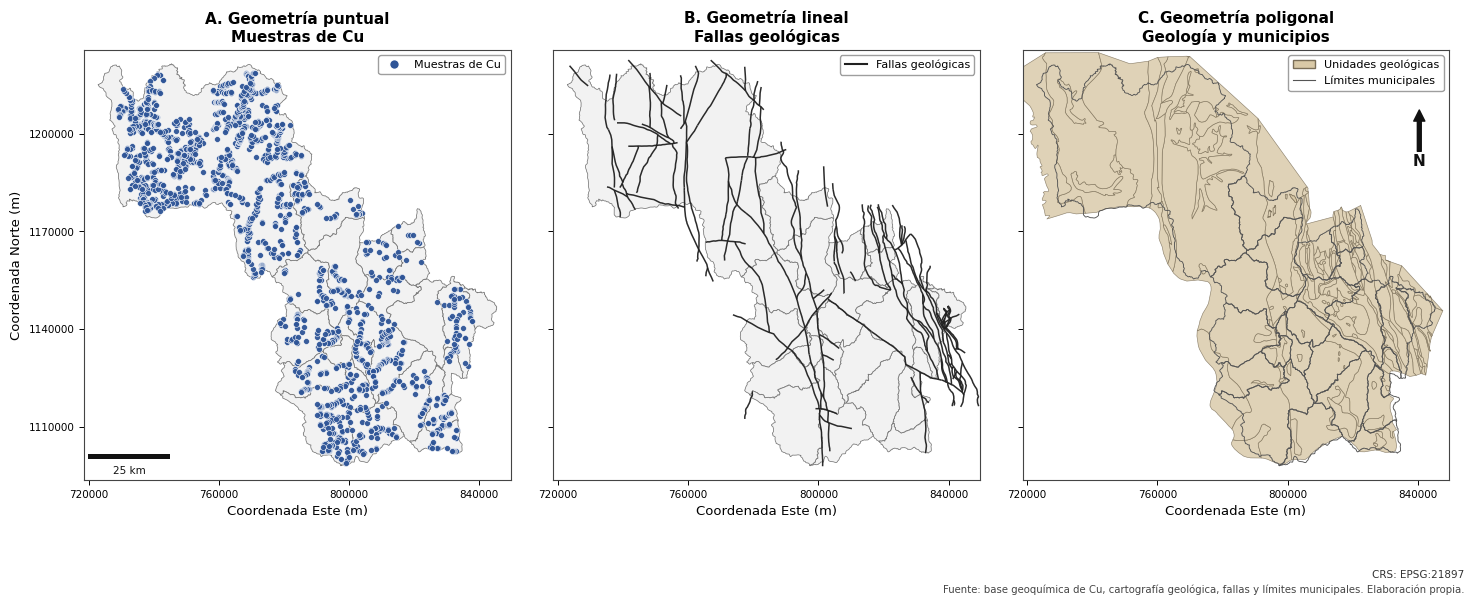

In [151]:
# ==========================================================
# FIGURA 03. REPRESENTACIÓN DEL MODELO DE DATOS VECTORIAL
# ==========================================================

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.ticker import MaxNLocator, ScalarFormatter


# ----------------------------------------------------------
# 1. Preparar copias de las capas
# ----------------------------------------------------------

municipios_vec = municipios.copy()
geologia_vec = geologia.copy()
fallas_vec = fallas.copy()
muestras_vec = muestras.copy()


# ----------------------------------------------------------
# 2. Eliminar geometrías nulas o vacías
# ----------------------------------------------------------

municipios_vec = municipios_vec[
    municipios_vec.geometry.notna()
    & ~municipios_vec.geometry.is_empty
].copy()

geologia_vec = geologia_vec[
    geologia_vec.geometry.notna()
    & ~geologia_vec.geometry.is_empty
].copy()

fallas_vec = fallas_vec[
    fallas_vec.geometry.notna()
    & ~fallas_vec.geometry.is_empty
].copy()

muestras_vec = muestras_vec[
    muestras_vec.geometry.notna()
    & ~muestras_vec.geometry.is_empty
].copy()


# ----------------------------------------------------------
# 3. Homogeneizar el sistema de referencia
# ----------------------------------------------------------

crs_mapa = municipios_vec.crs

if crs_mapa is None:
    raise ValueError(
        "La capa de municipios no tiene un CRS definido."
    )

if geologia_vec.crs != crs_mapa:
    geologia_vec = geologia_vec.to_crs(crs_mapa)

if fallas_vec.crs != crs_mapa:
    fallas_vec = fallas_vec.to_crs(crs_mapa)

if muestras_vec.crs != crs_mapa:
    muestras_vec = muestras_vec.to_crs(crs_mapa)


# ----------------------------------------------------------
# 4. Extensión cartográfica común
# ----------------------------------------------------------

xmin, ymin, xmax, ymax = municipios_vec.total_bounds

margen_x = (xmax - xmin) * 0.035
margen_y = (ymax - ymin) * 0.035


# ----------------------------------------------------------
# 5. Crear la Figura 03 de tres paneles
# ----------------------------------------------------------

fig, ejes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 6.5),
    sharex=True,
    sharey=True
)

ax_punto, ax_linea, ax_poligono = ejes


# ==========================================================
# PANEL A. PUNTOS
# ==========================================================

municipios_vec.plot(
    ax=ax_punto,
    facecolor="#F2F2F2",
    edgecolor="#777777",
    linewidth=0.55,
    zorder=1
)

muestras_vec.plot(
    ax=ax_punto,
    color="#2F5597",
    marker="o",
    markersize=18,
    edgecolor="white",
    linewidth=0.40,
    alpha=0.95,
    zorder=2
)

ax_punto.set_title(
    "A. Geometría puntual\nMuestras de Cu",
    fontsize=11,
    fontweight="bold"
)


# ==========================================================
# PANEL B. LÍNEAS
# ==========================================================

municipios_vec.plot(
    ax=ax_linea,
    facecolor="#F2F2F2",
    edgecolor="#777777",
    linewidth=0.55,
    zorder=1
)

fallas_vec.plot(
    ax=ax_linea,
    color="#202020",
    linewidth=1.10,
    alpha=0.95,
    zorder=2
)

ax_linea.set_title(
    "B. Geometría lineal\nFallas geológicas",
    fontsize=11,
    fontweight="bold"
)


# ==========================================================
# PANEL C. POLÍGONOS
# ==========================================================

geologia_vec.plot(
    ax=ax_poligono,
    facecolor="#D9C9A7",
    edgecolor="#7A6E58",
    linewidth=0.45,
    alpha=0.82,
    zorder=1
)

municipios_vec.boundary.plot(
    ax=ax_poligono,
    color="#555555",
    linewidth=0.65,
    zorder=2
)

ax_poligono.set_title(
    "C. Geometría poligonal\nGeología y municipios",
    fontsize=11,
    fontweight="bold"
)


# ----------------------------------------------------------
# 6. Configuración común de los paneles
# ----------------------------------------------------------

formato_coordenadas = ScalarFormatter(
    useOffset=False,
    useMathText=False
)

formato_coordenadas.set_scientific(False)

for ax in ejes:

    ax.set_xlim(
        xmin - margen_x,
        xmax + margen_x
    )

    ax.set_ylim(
        ymin - margen_y,
        ymax + margen_y
    )

    ax.set_aspect("equal")

    ax.xaxis.set_major_locator(
        MaxNLocator(nbins=4)
    )

    ax.yaxis.set_major_locator(
        MaxNLocator(nbins=5)
    )

    ax.xaxis.set_major_formatter(
        formato_coordenadas
    )

    ax.yaxis.set_major_formatter(
        formato_coordenadas
    )

    ax.tick_params(
        axis="both",
        labelsize=7.5,
        direction="out",
        length=3.5,
        width=0.7
    )

    ax.grid(False)

    for borde in ax.spines.values():
        borde.set_visible(True)
        borde.set_color("#444444")
        borde.set_linewidth(0.8)


# ----------------------------------------------------------
# 7. Etiquetas de coordenadas
# ----------------------------------------------------------

ax_punto.set_ylabel(
    "Coordenada Norte (m)",
    fontsize=9.5
)

for ax in ejes:
    ax.set_xlabel(
        "Coordenada Este (m)",
        fontsize=9.5
    )


# ----------------------------------------------------------
# 8. Leyendas individuales
# ----------------------------------------------------------

ax_punto.legend(
    handles=[
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor="#2F5597",
            markeredgecolor="white",
            markersize=7,
            label="Muestras de Cu"
        )
    ],
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="#999999",
    framealpha=0.95,
    fontsize=8
)

ax_linea.legend(
    handles=[
        Line2D(
            [0],
            [0],
            color="#202020",
            linewidth=1.5,
            label="Fallas geológicas"
        )
    ],
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="#999999",
    framealpha=0.95,
    fontsize=8
)

ax_poligono.legend(
    handles=[
        Patch(
            facecolor="#D9C9A7",
            edgecolor="#7A6E58",
            label="Unidades geológicas"
        ),
        Line2D(
            [0],
            [0],
            color="#555555",
            linewidth=0.8,
            label="Límites municipales"
        )
    ],
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="#999999",
    framealpha=0.95,
    fontsize=8
)


# ----------------------------------------------------------
# 9. Barra de escala en el primer panel
# ----------------------------------------------------------

barra_escala = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",
    location="lower left",
    length_fraction=0.28,
    box_alpha=0.90,
    box_color="white",
    color="#111111",
    font_properties={"size": 7.5}
)

ax_punto.add_artist(barra_escala)


# ----------------------------------------------------------
# 10. Flecha norte en el último panel
# ----------------------------------------------------------

ax_poligono.annotate(
    "N",
    xy=(0.93, 0.86),
    xytext=(0.93, 0.74),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
    color="#111111",
    arrowprops=dict(
        facecolor="#111111",
        edgecolor="#111111",
        width=2.8,
        headwidth=8,
        headlength=8
    ),
    zorder=10
)


# ----------------------------------------------------------
# 11. Sistema de referencia y fuente
# ----------------------------------------------------------

epsg_mapa = crs_mapa.to_epsg()

if epsg_mapa is not None:
    texto_crs = f"CRS: EPSG:{epsg_mapa}"
else:
    texto_crs = f"CRS: {crs_mapa.name}"

fig.text(
    0.99,
    0.035,
    texto_crs,
    ha="right",
    va="bottom",
    fontsize=7.5,
    color="#333333"
)

fig.text(
    0.99,
    0.012,
    (
        "Fuente: base geoquímica de Cu, cartografía geológica, "
        "fallas y límites municipales. Elaboración propia."
    ),
    ha="right",
    va="bottom",
    fontsize=7.3,
    color="#444444"
)


# ----------------------------------------------------------
# 12. Ajustar distribución
# ----------------------------------------------------------

fig.subplots_adjust(
    left=0.07,
    right=0.98,
    bottom=0.13,
    top=0.91,
    wspace=0.10
)


# ----------------------------------------------------------
# 13. Guardar la Figura 03 únicamente en PNG
# ----------------------------------------------------------

nombre_archivo_figura_03 = (
    "Figura_03_Modelo_Datos_Vectorial_"
    "Puntos_Lineas_Poligonos.png"
)

ruta_png_figura_03 = (
    FIGURAS / nombre_archivo_figura_03
)

fig.savefig(
    ruta_png_figura_03,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.12,
    facecolor="white"
)

print("=" * 68)
print("FIGURA 03 GENERADA Y GUARDADA CORRECTAMENTE")
print("=" * 68)
print(f"PNG: {ruta_png_figura_03}")
print("=" * 68)

plt.show()

**Figura 03.** Modelo datos vectorial: Puntos, lineas y Poligonos.

La Tabla 04 y la Figura 03 muestran que el estudio se desarrolla sobre un modelo vectorial, en el cual las muestras geoquímicas se representan mediante puntos, las fallas mediante líneas y las unidades geológicas y administrativas mediante polígonos. Esta estructura permite representar de manera diferenciada los fenómenos espaciales que intervienen en el análisis.

##2.4 Sistema de referencia espacial

En esta sección se verifica el sistema de referencia de las capas y su compatibilidad para realizar operaciones espaciales, mediciones de distancia y análisis geoestadísticos. La información se presenta de forma breve porque la comprobación inicial ya mostró que las cuatro capas comparten el mismo CRS.

FIGURA 03 GENERADA Y GUARDADA CORRECTAMENTE
PNG: /content/drive/MyDrive/Analisis_Geoespacial_Cobre/03_Figuras/Figura_03_Modelo_Datos_Vectorial_Puntos_Lineas_Poligonos.png


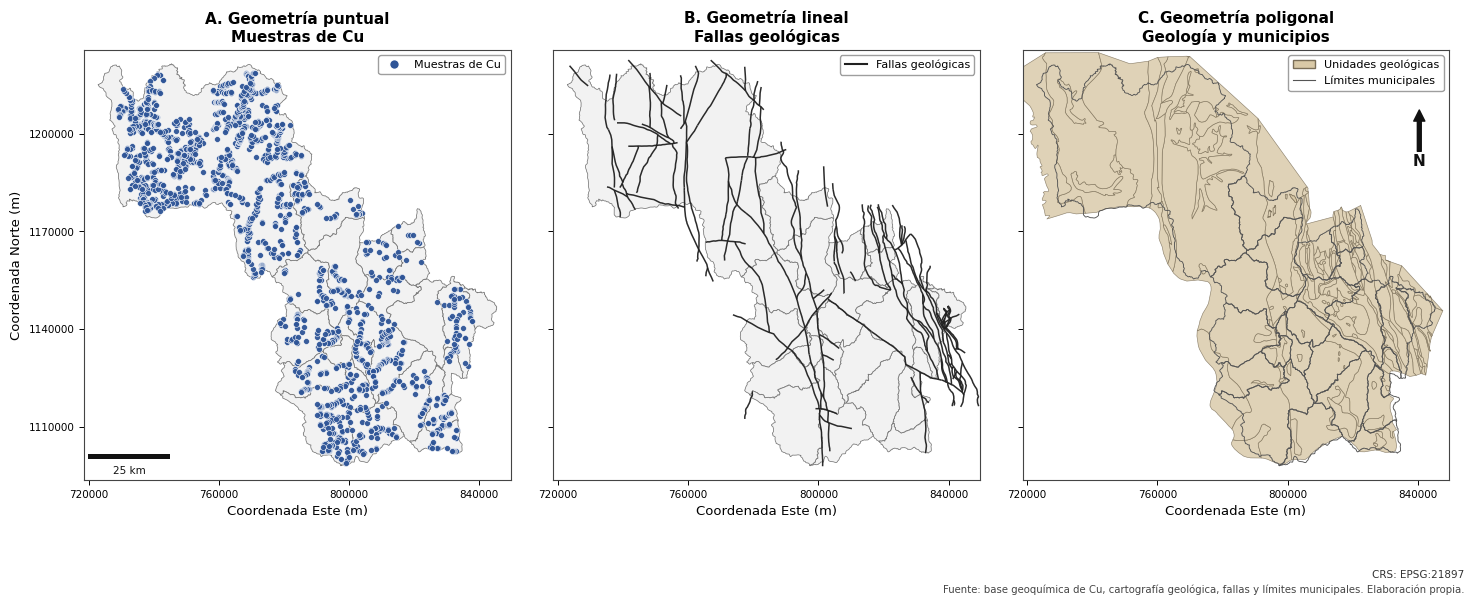

In [152]:
# ==========================================================
# FIGURA 03. REPRESENTACIÓN DEL MODELO DE DATOS VECTORIAL
# ==========================================================

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.ticker import MaxNLocator, ScalarFormatter


# ----------------------------------------------------------
# 1. Preparar copias de las capas
# ----------------------------------------------------------

municipios_vec = municipios.copy()
geologia_vec = geologia.copy()
fallas_vec = fallas.copy()
muestras_vec = muestras.copy()


# ----------------------------------------------------------
# 2. Eliminar geometrías nulas o vacías
# ----------------------------------------------------------

municipios_vec = municipios_vec[
    municipios_vec.geometry.notna()
    & ~municipios_vec.geometry.is_empty
].copy()

geologia_vec = geologia_vec[
    geologia_vec.geometry.notna()
    & ~geologia_vec.geometry.is_empty
].copy()

fallas_vec = fallas_vec[
    fallas_vec.geometry.notna()
    & ~fallas_vec.geometry.is_empty
].copy()

muestras_vec = muestras_vec[
    muestras_vec.geometry.notna()
    & ~muestras_vec.geometry.is_empty
].copy()


# ----------------------------------------------------------
# 3. Homogeneizar el sistema de referencia
# ----------------------------------------------------------

crs_mapa = municipios_vec.crs

if crs_mapa is None:
    raise ValueError(
        "La capa de municipios no tiene un CRS definido."
    )

if geologia_vec.crs != crs_mapa:
    geologia_vec = geologia_vec.to_crs(crs_mapa)

if fallas_vec.crs != crs_mapa:
    fallas_vec = fallas_vec.to_crs(crs_mapa)

if muestras_vec.crs != crs_mapa:
    muestras_vec = muestras_vec.to_crs(crs_mapa)


# ----------------------------------------------------------
# 4. Extensión cartográfica común
# ----------------------------------------------------------

xmin, ymin, xmax, ymax = municipios_vec.total_bounds

margen_x = (xmax - xmin) * 0.035
margen_y = (ymax - ymin) * 0.035


# ----------------------------------------------------------
# 5. Crear la Figura 03 de tres paneles
# ----------------------------------------------------------

fig, ejes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 6.5),
    sharex=True,
    sharey=True
)

ax_punto, ax_linea, ax_poligono = ejes


# ==========================================================
# PANEL A. PUNTOS
# ==========================================================

municipios_vec.plot(
    ax=ax_punto,
    facecolor="#F2F2F2",
    edgecolor="#777777",
    linewidth=0.55,
    zorder=1
)

muestras_vec.plot(
    ax=ax_punto,
    color="#2F5597",
    marker="o",
    markersize=18,
    edgecolor="white",
    linewidth=0.40,
    alpha=0.95,
    zorder=2
)

ax_punto.set_title(
    "A. Geometría puntual\nMuestras de Cu",
    fontsize=11,
    fontweight="bold"
)


# ==========================================================
# PANEL B. LÍNEAS
# ==========================================================

municipios_vec.plot(
    ax=ax_linea,
    facecolor="#F2F2F2",
    edgecolor="#777777",
    linewidth=0.55,
    zorder=1
)

fallas_vec.plot(
    ax=ax_linea,
    color="#202020",
    linewidth=1.10,
    alpha=0.95,
    zorder=2
)

ax_linea.set_title(
    "B. Geometría lineal\nFallas geológicas",
    fontsize=11,
    fontweight="bold"
)


# ==========================================================
# PANEL C. POLÍGONOS
# ==========================================================

geologia_vec.plot(
    ax=ax_poligono,
    facecolor="#D9C9A7",
    edgecolor="#7A6E58",
    linewidth=0.45,
    alpha=0.82,
    zorder=1
)

municipios_vec.boundary.plot(
    ax=ax_poligono,
    color="#555555",
    linewidth=0.65,
    zorder=2
)

ax_poligono.set_title(
    "C. Geometría poligonal\nGeología y municipios",
    fontsize=11,
    fontweight="bold"
)


# ----------------------------------------------------------
# 6. Configuración común de los paneles
# ----------------------------------------------------------

formato_coordenadas = ScalarFormatter(
    useOffset=False,
    useMathText=False
)

formato_coordenadas.set_scientific(False)

for ax in ejes:

    ax.set_xlim(
        xmin - margen_x,
        xmax + margen_x
    )

    ax.set_ylim(
        ymin - margen_y,
        ymax + margen_y
    )

    ax.set_aspect("equal")

    ax.xaxis.set_major_locator(
        MaxNLocator(nbins=4)
    )

    ax.yaxis.set_major_locator(
        MaxNLocator(nbins=5)
    )

    ax.xaxis.set_major_formatter(
        formato_coordenadas
    )

    ax.yaxis.set_major_formatter(
        formato_coordenadas
    )

    ax.tick_params(
        axis="both",
        labelsize=7.5,
        direction="out",
        length=3.5,
        width=0.7
    )

    ax.grid(False)

    for borde in ax.spines.values():
        borde.set_visible(True)
        borde.set_color("#444444")
        borde.set_linewidth(0.8)


# ----------------------------------------------------------
# 7. Etiquetas de coordenadas
# ----------------------------------------------------------

ax_punto.set_ylabel(
    "Coordenada Norte (m)",
    fontsize=9.5
)

for ax in ejes:
    ax.set_xlabel(
        "Coordenada Este (m)",
        fontsize=9.5
    )


# ----------------------------------------------------------
# 8. Leyendas individuales
# ----------------------------------------------------------

ax_punto.legend(
    handles=[
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor="#2F5597",
            markeredgecolor="white",
            markersize=7,
            label="Muestras de Cu"
        )
    ],
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="#999999",
    framealpha=0.95,
    fontsize=8
)

ax_linea.legend(
    handles=[
        Line2D(
            [0],
            [0],
            color="#202020",
            linewidth=1.5,
            label="Fallas geológicas"
        )
    ],
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="#999999",
    framealpha=0.95,
    fontsize=8
)

ax_poligono.legend(
    handles=[
        Patch(
            facecolor="#D9C9A7",
            edgecolor="#7A6E58",
            label="Unidades geológicas"
        ),
        Line2D(
            [0],
            [0],
            color="#555555",
            linewidth=0.8,
            label="Límites municipales"
        )
    ],
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="#999999",
    framealpha=0.95,
    fontsize=8
)


# ----------------------------------------------------------
# 9. Barra de escala en el primer panel
# ----------------------------------------------------------

barra_escala = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",
    location="lower left",
    length_fraction=0.28,
    box_alpha=0.90,
    box_color="white",
    color="#111111",
    font_properties={"size": 7.5}
)

ax_punto.add_artist(barra_escala)


# ----------------------------------------------------------
# 10. Flecha norte en el último panel
# ----------------------------------------------------------

ax_poligono.annotate(
    "N",
    xy=(0.93, 0.86),
    xytext=(0.93, 0.74),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
    color="#111111",
    arrowprops=dict(
        facecolor="#111111",
        edgecolor="#111111",
        width=2.8,
        headwidth=8,
        headlength=8
    ),
    zorder=10
)


# ----------------------------------------------------------
# 11. Sistema de referencia y fuente
# ----------------------------------------------------------

epsg_mapa = crs_mapa.to_epsg()

if epsg_mapa is not None:
    texto_crs = f"CRS: EPSG:{epsg_mapa}"
else:
    texto_crs = f"CRS: {crs_mapa.name}"

fig.text(
    0.99,
    0.035,
    texto_crs,
    ha="right",
    va="bottom",
    fontsize=7.5,
    color="#333333"
)

fig.text(
    0.99,
    0.012,
    (
        "Fuente: base geoquímica de Cu, cartografía geológica, "
        "fallas y límites municipales. Elaboración propia."
    ),
    ha="right",
    va="bottom",
    fontsize=7.3,
    color="#444444"
)


# ----------------------------------------------------------
# 12. Ajustar distribución
# ----------------------------------------------------------

fig.subplots_adjust(
    left=0.07,
    right=0.98,
    bottom=0.13,
    top=0.91,
    wspace=0.10
)


# ----------------------------------------------------------
# 13. Guardar la Figura 03 únicamente en PNG
# ----------------------------------------------------------

nombre_archivo_figura_03 = (
    "Figura_03_Modelo_Datos_Vectorial_"
    "Puntos_Lineas_Poligonos.png"
)

ruta_png_figura_03 = (
    FIGURAS / nombre_archivo_figura_03
)

fig.savefig(
    ruta_png_figura_03,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.12,
    facecolor="white"
)

print("=" * 68)
print("FIGURA 03 GENERADA Y GUARDADA CORRECTAMENTE")
print("=" * 68)
print(f"PNG: {ruta_png_figura_03}")
print("=" * 68)

plt.show()

**Tabla 04.** Sistema de referencia espacial de las capas del estudio.

La Tabla 04 confirma que las capas utilizadas cuentan con un sistema de referencia proyectado común y unidades expresadas en metros. Esta compatibilidad permite superponer las capas correctamente y realizar cálculos espaciales de distancia, área, proximidad y continuidad espacial sin requerir transformaciones adicionales durante el análisis.

##2.5 Calidad de la información espacial


En esta sección se verifican aspectos básicos de integridad y consistencia de las capas antes de continuar con los análisis espaciales. La revisión incluye geometrías nulas, geometrías vacías, validez geométrica, duplicados y disponibilidad del sistema de referencia.

In [22]:
# ==========================================================
# TABLA 05. VERIFICACIÓN DE LA CALIDAD DE LAS CAPAS ESPACIALES
# ==========================================================

# ----------------------------------------------------------
# 1. Construcción de la tabla
# ----------------------------------------------------------

tabla_05 = pd.DataFrame({

    "Capa": [
        "Muestras de Cu",
        "Fallas geológicas",
        "Geología",
        "Municipios"
    ],

    "Geometría válida": [
        "Sí",
        "Sí",
        "Sí",
        "Sí"
    ],

    "CRS definido": [
        "Sí",
        "Sí",
        "Sí",
        "Sí"
    ],

    "Observaciones": [

        "Base geoquímica preparada para el análisis espacial.",

        "Capa utilizada como referencia estructural del área de estudio.",

        "Cartografía geológica validada para su integración espacial.",

        "Delimitación administrativa empleada para definir el área de estudio."
    ]

})


# ----------------------------------------------------------
# 2. Mostrar la tabla
# ----------------------------------------------------------

tabla_05_estilizada = (
    tabla_05.style
    .hide(axis="index")
    .set_caption(
        "Tabla 05. Verificación de la calidad de las capas espaciales"
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "13px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "1px solid #555555"),
                ("padding", "7px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "7px"),
                ("border-bottom", "1px solid #D9D9D9"),
                ("vertical-align", "top")
            ]
        }
    ])
)

display(tabla_05_estilizada)


# ----------------------------------------------------------
# 3. Exportar únicamente en CSV
# ----------------------------------------------------------

ruta_csv = (
    TABLAS /
    "Tabla_05_Calidad_Capas_Espaciales.csv"
)

tabla_05.to_csv(
    ruta_csv,
    index=False,
    encoding="utf-8-sig"
)

print("="*68)
print("TABLA 05 GENERADA Y GUARDADA CORRECTAMENTE")
print("="*68)
print(f"CSV: {ruta_csv}")
print("="*68)

Capa,Geometría válida,CRS definido,Observaciones
Muestras de Cu,Sí,Sí,Base geoquímica preparada para el análisis espacial.
Fallas geológicas,Sí,Sí,Capa utilizada como referencia estructural del área de estudio.
Geología,Sí,Sí,Cartografía geológica validada para su integración espacial.
Municipios,Sí,Sí,Delimitación administrativa empleada para definir el área de estudio.


TABLA 05 GENERADA Y GUARDADA CORRECTAMENTE
CSV: /content/drive/MyDrive/Analisis_Geoespacial_Cobre/04_Resultados/01_Tablas/Tabla_05_Calidad_Capas_Espaciales.csv


**Tabla 05.** Verificación de la calidad de las capas espaciales.

La Tabla 05 resume la verificación de calidad realizada sobre las capas espaciales utilizadas en el estudio. Todas las capas presentan geometrías válidas y un sistema de referencia espacial definido, lo que garantiza su compatibilidad para las operaciones de superposición, análisis espacial y modelamiento geoestadístico. Las correcciones necesarias fueron realizadas previamente durante la etapa de preparación y estandarización de la información espacial en Qgis.

##2.6 Relaciones espaciales entre las capas

En esta sección se analizan las relaciones espaciales existentes entre las capas utilizadas en el estudio, evaluando su integración dentro de un mismo sistema de referencia espacial. La superposición de las muestras geoquímicas, la cartografía geológica, las fallas y los límites municipales permite establecer el contexto espacial sobre el cual se desarrollarán los análisis posteriores.

FIGURA 04 GENERADA CORRECTAMENTE
PNG: /content/drive/MyDrive/Analisis_Geoespacial_Cobre/03_Figuras/Figura_04_Integracion_Espacial_Capas_Estudio.png


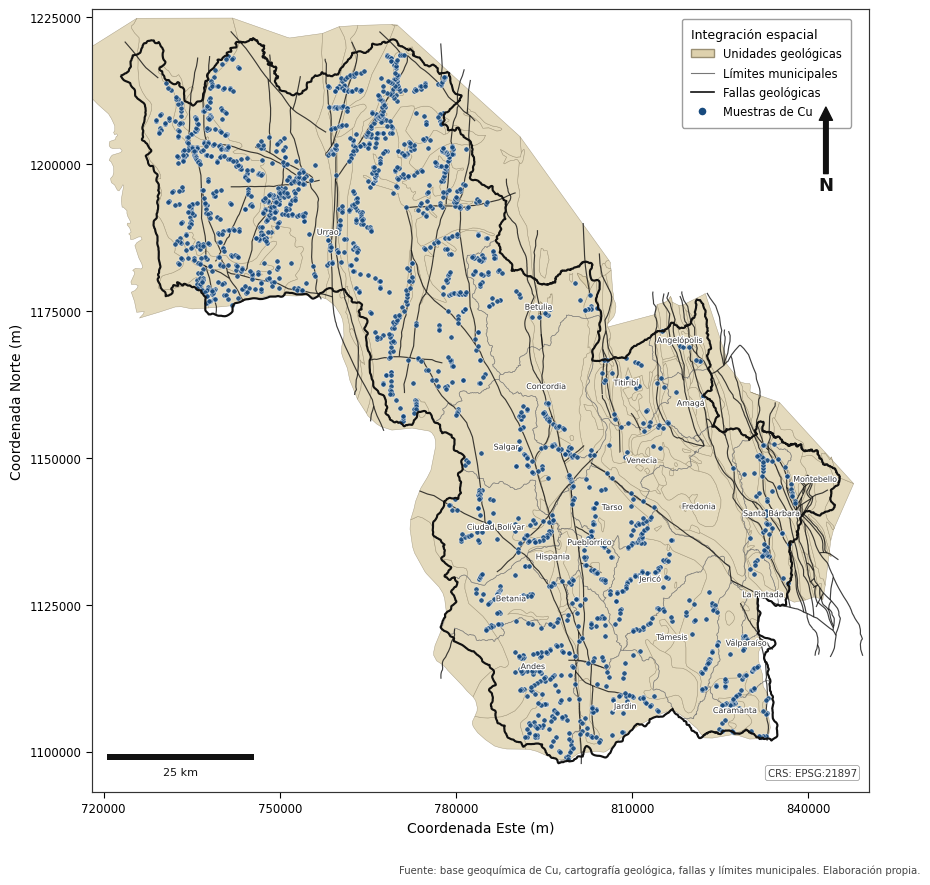

In [156]:
# ==========================================================
# FIGURA 04. INTEGRACIÓN ESPACIAL DE LAS CAPAS DEL ESTUDIO
# ==========================================================

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.ticker import MaxNLocator, ScalarFormatter
import matplotlib.patheffects as pe


# ----------------------------------------------------------
# 1. Preparar copias de las capas
# ----------------------------------------------------------

municipios_fig = municipios.copy()
geologia_fig = geologia.copy()
fallas_fig = fallas.copy()
muestras_fig = muestras.copy()


# ----------------------------------------------------------
# 2. Eliminar geometrías nulas o vacías
# ----------------------------------------------------------

municipios_fig = municipios_fig[
    municipios_fig.geometry.notna()
    & ~municipios_fig.geometry.is_empty
].copy()

geologia_fig = geologia_fig[
    geologia_fig.geometry.notna()
    & ~geologia_fig.geometry.is_empty
].copy()

fallas_fig = fallas_fig[
    fallas_fig.geometry.notna()
    & ~fallas_fig.geometry.is_empty
].copy()

muestras_fig = muestras_fig[
    muestras_fig.geometry.notna()
    & ~muestras_fig.geometry.is_empty
].copy()


# ----------------------------------------------------------
# 3. Homogeneizar el sistema de referencia espacial
# ----------------------------------------------------------

crs_mapa = municipios_fig.crs

if crs_mapa is None:
    raise ValueError(
        "La capa de municipios no tiene un sistema "
        "de referencia espacial definido."
    )

if geologia_fig.crs != crs_mapa:
    geologia_fig = geologia_fig.to_crs(crs_mapa)

if fallas_fig.crs != crs_mapa:
    fallas_fig = fallas_fig.to_crs(crs_mapa)

if muestras_fig.crs != crs_mapa:
    muestras_fig = muestras_fig.to_crs(crs_mapa)


# ----------------------------------------------------------
# 4. Crear límite exterior del área de estudio
# ----------------------------------------------------------

limite_estudio = municipios_fig.dissolve()


# ----------------------------------------------------------
# 5. Identificar la columna con nombres municipales
# ----------------------------------------------------------

columnas_nombre = [
    "NOMBRE",
    "NOMBRE_MPIO",
    "MPIO_CNMBR",
    "MUNICIPIO",
    "NOM_MPIO",
    "NOM_MUNIC"
]

columna_nombre = next(
    (
        columna
        for columna in columnas_nombre
        if columna in municipios_fig.columns
    ),
    None
)

if columna_nombre is not None:
    municipios_fig["NOMBRE_MAPA"] = (
        municipios_fig[columna_nombre]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )
else:
    municipios_fig["NOMBRE_MAPA"] = ""


# ----------------------------------------------------------
# 6. Corregir nombres municipales abreviados
# ----------------------------------------------------------

nombres_corregidos = {
    "S.BARBA": "Santa Bárbara",
    "C.BOLIV": "Ciudad Bolívar",
    "P.RICO": "Pueblorrico",
    "MONTEBE": "Montebello",
    "TITIRIB": "Titiribí",
    "TAMESIS": "Támesis",
    "JERICO": "Jericó",
    "HISPANI": "Hispania",
    "FREDONI": "Fredonia",
    "ANGELOP": "Angelópolis",
    "CARAMAN": "Caramanta",
    "VALPARA": "Valparaíso",
    "CONCORD": "Concordia",
    "PINTADA": "La Pintada"
}

municipios_fig["NOMBRE_MAPA"] = (
    municipios_fig["NOMBRE_MAPA"]
    .replace(nombres_corregidos)
)

municipios_fig["NOMBRE_MAPA"] = (
    municipios_fig["NOMBRE_MAPA"]
    .apply(
        lambda nombre: (
            nombre.title()
            if nombre and nombre == nombre.upper()
            else nombre
        )
    )
)
# ----------------------------------------------------------
# 7. Calcular extensión cartográfica
# ----------------------------------------------------------

import matplotlib.pyplot as plt

xmin, ymin, xmax, ymax = municipios_fig.total_bounds

margen_x = (xmax - xmin) * 0.04
margen_y = (ymax - ymin) * 0.04


# ----------------------------------------------------------
# 8. Crear la Figura 04
# ----------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 9),
    facecolor="white"
)


# ----------------------------------------------------------
# 9. Dibujar las unidades geológicas
# ----------------------------------------------------------

geologia_fig.plot(
    ax=ax,
    facecolor="#DED1AD",
    edgecolor="#9A8F73",
    linewidth=0.35,
    alpha=0.80,
    zorder=1
)


# ----------------------------------------------------------
# 10. Dibujar límites municipales
# ----------------------------------------------------------

municipios_fig.boundary.plot(
    ax=ax,
    color="#777777",
    linewidth=0.45,
    alpha=0.75,
    zorder=2
)


# ----------------------------------------------------------
# 11. Dibujar las fallas geológicas
# ----------------------------------------------------------

fallas_fig.plot(
    ax=ax,
    color="#111111",
    linewidth=0.85,
    alpha=0.80,
    zorder=3
)


# ----------------------------------------------------------
# 12. Dibujar las muestras de Cu
# ----------------------------------------------------------

muestras_fig.plot(
    ax=ax,
    color="#174A7E",
    marker="o",
    markersize=14,
    edgecolor="white",
    linewidth=0.35,
    alpha=0.90,
    zorder=4
)


# ----------------------------------------------------------
# 13. Dibujar el límite exterior del área
# ----------------------------------------------------------

limite_estudio.boundary.plot(
    ax=ax,
    color="#111111",
    linewidth=1.55,
    zorder=5
)


# ----------------------------------------------------------
# 14. Añadir nombres municipales
# ----------------------------------------------------------

for _, fila in municipios_fig.iterrows():

    nombre = fila["NOMBRE_MAPA"]

    if not nombre:
        continue

    punto = fila.geometry.representative_point()

    texto = ax.text(
        punto.x,
        punto.y,
        nombre,
        fontsize=5.7,
        ha="center",
        va="center",
        color="#303030",
        zorder=6
    )

    texto.set_path_effects([
        pe.withStroke(
            linewidth=1.8,
            foreground="white"
        )
    ])


# ----------------------------------------------------------
# 15. Configurar extensión y ejes
# ----------------------------------------------------------

ax.set_xlim(
    xmin - margen_x,
    xmax + margen_x
)

ax.set_ylim(
    ymin - margen_y,
    ymax + margen_y
)

ax.set_aspect("equal")

ax.set_xlabel(
    "Coordenada Este (m)",
    fontsize=10
)

ax.set_ylabel(
    "Coordenada Norte (m)",
    fontsize=10
)

ax.xaxis.set_major_locator(
    MaxNLocator(nbins=5)
)

ax.yaxis.set_major_locator(
    MaxNLocator(nbins=6)
)

formato_coordenadas = ScalarFormatter(
    useOffset=False,
    useMathText=False
)

formato_coordenadas.set_scientific(False)

ax.xaxis.set_major_formatter(
    formato_coordenadas
)

ax.yaxis.set_major_formatter(
    formato_coordenadas
)

ax.tick_params(
    axis="both",
    labelsize=8.5,
    direction="out",
    length=4,
    width=0.8
)

ax.ticklabel_format(
    style="plain",
    axis="both",
    useOffset=False
)

ax.grid(False)


# ----------------------------------------------------------
# 16. Añadir flecha norte
# ----------------------------------------------------------

ax.annotate(
    "N",
    xy=(0.945, 0.875),
    xytext=(0.945, 0.775),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    color="#111111",
    arrowprops=dict(
        facecolor="#111111",
        edgecolor="#111111",
        width=3.3,
        headwidth=9.5,
        headlength=9.5
    ),
    zorder=10
)


# ----------------------------------------------------------
# 17. Añadir barra de escala
# ----------------------------------------------------------

barra_escala = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",
    location="lower left",
    length_fraction=0.22,
    width_fraction=0.008,
    box_alpha=0.90,
    box_color="white",
    color="#111111",
    font_properties={"size": 8},
    border_pad=0.7,
    pad=0.4
)

ax.add_artist(barra_escala)


# ----------------------------------------------------------
# 18. Crear leyenda
# ----------------------------------------------------------

elementos_leyenda = [
    Patch(
        facecolor="#DED1AD",
        edgecolor="#9A8F73",
        label="Unidades geológicas"
    ),
    Line2D(
        [0],
        [0],
        color="#777777",
        linewidth=0.8,
        label="Límites municipales"
    ),
    Line2D(
        [0],
        [0],
        color="#111111",
        linewidth=1.2,
        label="Fallas geológicas"
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="#174A7E",
        markeredgecolor="white",
        markersize=6.5,
        label="Muestras de Cu"
    )
]

leyenda = ax.legend(
    handles=elementos_leyenda,
    loc="upper right",
    bbox_to_anchor=(0.985, 0.995),
    frameon=True,
    facecolor="white",
    edgecolor="#999999",
    framealpha=0.96,
    fontsize=8.3,
    title="Integración espacial",
    title_fontsize=9,
    borderpad=0.8,
    labelspacing=0.55
)

leyenda._legend_box.align = "left"


# ----------------------------------------------------------
# 19. Añadir sistema de referencia
# ----------------------------------------------------------

epsg_mapa = crs_mapa.to_epsg()

if epsg_mapa is not None:
    texto_crs = f"CRS: EPSG:{epsg_mapa}"
else:
    texto_crs = f"CRS: {crs_mapa.name}"

ax.text(
    0.985,
    0.018,
    texto_crs,
    transform=ax.transAxes,
    fontsize=7.3,
    ha="right",
    va="bottom",
    color="#333333",
    bbox=dict(
        facecolor="white",
        edgecolor="#888888",
        linewidth=0.50,
        alpha=0.92,
        boxstyle="round,pad=0.25"
    ),
    zorder=10
)


# ----------------------------------------------------------
# 20. Configurar marco cartográfico
# ----------------------------------------------------------

for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_color("#333333")
    borde.set_linewidth(0.85)


# ----------------------------------------------------------
# 21. Añadir fuente
# ----------------------------------------------------------

fig.text(
    0.98,
    0.018,
    (
        "Fuente: base geoquímica de Cu, cartografía geológica, "
        "fallas y límites municipales. Elaboración propia."
    ),
    ha="right",
    va="bottom",
    fontsize=7.3,
    color="#444444"
)


# ----------------------------------------------------------
# 22. Ajustar distribución
# ----------------------------------------------------------

fig.subplots_adjust(
    left=0.11,
    right=0.97,
    bottom=0.11,
    top=0.98
)


# ----------------------------------------------------------
# 23. Guardar la Figura 04
# ----------------------------------------------------------

ruta_figura_04 = (
    FIGURAS
    / "Figura_04_Integracion_Espacial_Capas_Estudio.png"
)

fig.savefig(
    ruta_figura_04,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.12,
    facecolor="white"
)


# ----------------------------------------------------------
# 24. Confirmar y mostrar
# ----------------------------------------------------------

print("=" * 72)
print("FIGURA 04 GENERADA CORRECTAMENTE")
print("=" * 72)
print(f"PNG: {ruta_figura_04}")
print("=" * 72)

plt.show()

**Figura 04.** Integracion espacial capas de estudio

La Figura 04 muestra la integración espacial de las capas utilizadas en el estudio. Las muestras geoquímicas se localizan dentro de las unidades geológicas y del contexto estructural definido por las fallas, mientras que los límites municipales proporcionan la referencia administrativa del área analizada. Esta superposición constituye la base para evaluar posteriormente las relaciones entre la concentración de cobre y su entorno geológico.

# 3. Análisis espacial de datos: Patrón del muestreo

En esta sección se aplican los conceptos de análisis de datos puntuales propuestos en el libro guía al conjunto de muestras geoquímicas de cobre. Dado que las muestras representan ubicaciones de medición y no eventos espaciales aleatorios, se seleccionan las herramientas metodológicas que permiten caracterizar adecuadamente el patrón espacial del muestreo, justificando además la exclusión de aquellos métodos cuya aplicación no resulta apropiada para este tipo de información.

##3.1 Naturaleza del muestreo

En esta sección se presenta la naturaleza del esquema de muestreo utilizado para la recopilación de las muestras geoquímicas. Se establece la diferencia entre un muestreo regular y el patrón de muestreo empleado en el estudio, con el fin de contextualizar la distribución espacial de las observaciones antes de aplicar las herramientas de análisis espacial.

FIGURA 05 GENERADA Y GUARDADA CORRECTAMENTE
PNG: /content/drive/MyDrive/Analisis_Geoespacial_Cobre/03_Figuras/Figura_05_Comparacion_Muestreo_Regular_Irregular.png
Muestras reales representadas: 2,029


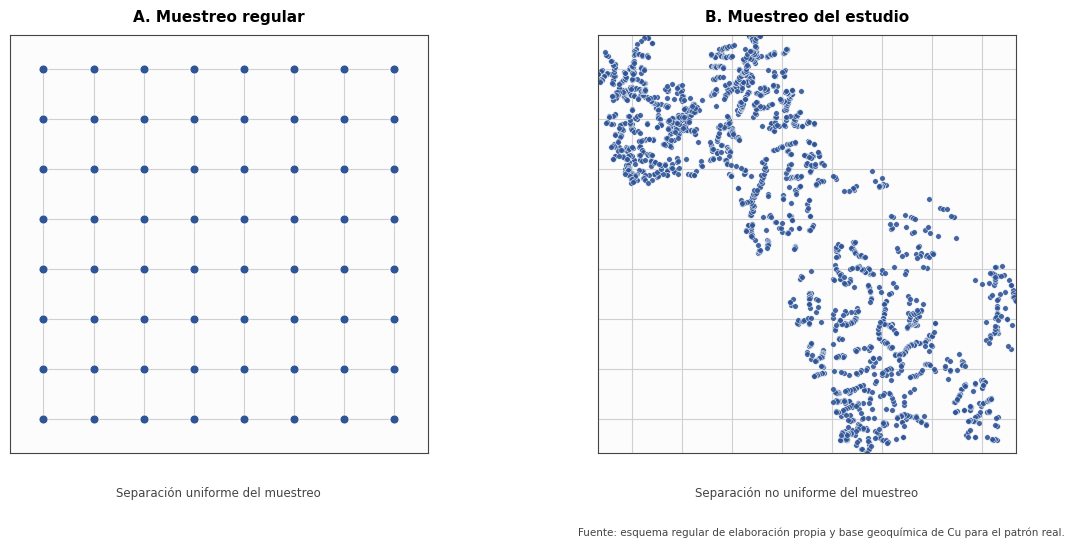

In [157]:
# ==========================================================
# FIGURA 05. COMPARACIÓN ENTRE MUESTREO REGULAR E IRREGULAR
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt


# ----------------------------------------------------------
# 1. Preparar las muestras reales
# ----------------------------------------------------------

if "muestras_estudio" in globals():
    muestras_fig = muestras_estudio.copy()
else:
    muestras_fig = muestras.copy()

muestras_fig = muestras_fig[
    muestras_fig.geometry.notna()
    & ~muestras_fig.geometry.is_empty
].copy()

# Extraer coordenadas
x_real = muestras_fig.geometry.x.to_numpy()
y_real = muestras_fig.geometry.y.to_numpy()

mascara_valida = (
    np.isfinite(x_real)
    & np.isfinite(y_real)
)

x_real = x_real[mascara_valida]
y_real = y_real[mascara_valida]


# ----------------------------------------------------------
# 2. Normalizar las coordenadas reales
#    para comparar únicamente la disposición espacial
# ----------------------------------------------------------

x_real_norm = (
    (x_real - x_real.min())
    / (x_real.max() - x_real.min())
)

y_real_norm = (
    (y_real - y_real.min())
    / (y_real.max() - y_real.min())
)


# ----------------------------------------------------------
# 3. Crear una malla regular sintética
# ----------------------------------------------------------

n_columnas = 8
n_filas = 8

x_regular = np.linspace(
    0.08,
    0.92,
    n_columnas
)

y_regular = np.linspace(
    0.08,
    0.92,
    n_filas
)

xx_regular, yy_regular = np.meshgrid(
    x_regular,
    y_regular
)

x_regular = xx_regular.ravel()
y_regular = yy_regular.ravel()


# ----------------------------------------------------------
# 4. Crear la Figura 05
# ----------------------------------------------------------

fig, ejes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 5.8),
    facecolor="white"
)

ax_regular, ax_irregular = ejes


# ----------------------------------------------------------
# 5. Panel A. Muestreo regular
# ----------------------------------------------------------

# Dibujar líneas de la malla
for x in np.unique(x_regular):
    ax_regular.plot(
        [x, x],
        [y_regular.min(), y_regular.max()],
        color="#D0D0D0",
        linewidth=0.8,
        zorder=1
    )

for y in np.unique(y_regular):
    ax_regular.plot(
        [x_regular.min(), x_regular.max()],
        [y, y],
        color="#D0D0D0",
        linewidth=0.8,
        zorder=1
    )

# Dibujar puntos
ax_regular.scatter(
    x_regular,
    y_regular,
    s=42,
    color="#2F5597",
    edgecolor="white",
    linewidth=0.6,
    zorder=2
)

ax_regular.set_title(
    "A. Muestreo regular",
    fontsize=11,
    fontweight="bold",
    pad=10
)

ax_regular.text(
    0.5,
    -0.08,
    "Separación uniforme del muestreo",
    transform=ax_regular.transAxes,
    ha="center",
    va="top",
    fontsize=8.5,
    color="#444444"
)


# ----------------------------------------------------------
# 6. Panel B. Muestreo irregular del estudio
# ----------------------------------------------------------

# Dibujar la misma malla regular del panel izquierdo
for x in np.unique(x_regular):
    ax_irregular.plot(
        [x, x],
        [0, 1],
        color="#D0D0D0",
        linewidth=0.8,
        zorder=1
    )

for y in np.unique(y_regular):
    ax_irregular.plot(
        [0, 1],
        [y, y],
        color="#D0D0D0",
        linewidth=0.8,
        zorder=1
    )

# Dibujar las muestras reales
ax_irregular.scatter(
    x_real_norm,
    y_real_norm,
    s=16,
    color="#2F5597",
    edgecolor="white",
    linewidth=0.35,
    alpha=0.90,
    zorder=2
)

ax_irregular.set_title(
    "B. Muestreo del estudio",
    fontsize=11,
    fontweight="bold",
    pad=10
)

ax_irregular.text(
    0.5,
    -0.08,
    "Separación no uniforme del muestreo",
    transform=ax_irregular.transAxes,
    ha="center",
    va="top",
    fontsize=8.5,
    color="#444444"
)


# ----------------------------------------------------------
# 7. Configuración común de los paneles
# ----------------------------------------------------------

for ax in ejes:

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")

    ax.set_xticks([])
    ax.set_yticks([])

    for borde in ax.spines.values():
        borde.set_visible(True)
        borde.set_color("#444444")
        borde.set_linewidth(0.8)

    ax.set_facecolor("#FCFCFC")


# ----------------------------------------------------------
# 8. Ajustar distribución
# ----------------------------------------------------------

fig.subplots_adjust(
    left=0.06,
    right=0.98,
    bottom=0.18,
    top=0.90,
    wspace=0.14
)


# ----------------------------------------------------------
# 9. Añadir fuente
# ----------------------------------------------------------

fig.text(
    0.98,
    0.035,
    (
        "Fuente: esquema regular de elaboración propia y "
        "base geoquímica de Cu para el patrón real."
    ),
    ha="right",
    va="bottom",
    fontsize=7.5,
    color="#444444"
)


# ----------------------------------------------------------
# 10. Guardar únicamente en PNG
# ----------------------------------------------------------

nombre_archivo = (
    "Figura_05_Comparacion_Muestreo_"
    "Regular_Irregular.png"
)

ruta_png_figura_05 = FIGURAS / nombre_archivo

fig.savefig(
    ruta_png_figura_05,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.12,
    facecolor="white"
)

print("=" * 68)
print("FIGURA 05 GENERADA Y GUARDADA CORRECTAMENTE")
print("=" * 68)
print(f"PNG: {ruta_png_figura_05}")
print(f"Muestras reales representadas: {len(x_real_norm):,}")
print("=" * 68)

plt.show()

**Figura 05.** Comparacion muestreo regular y irregular

La Figura 05 compara un esquema conceptual de muestreo regular con el patrón de muestreo utilizado en el estudio. Se observa que las muestras presentan una separación no uniforme entre observaciones, característica de un esquema de muestreo irregular propio de campañas de exploración geológica.

##3.2 Distribución espacial de las muestras

En esta sección se representa la distribución espacial de las muestras geoquímicas de cobre dentro del área de estudio, con el propósito de visualizar la cobertura espacial del muestreo e identificar la disposición de las observaciones antes de aplicar métodos de caracterización del patrón espacial.

FIGURA 06 GENERADA Y GUARDADA CORRECTAMENTE
PNG: /content/drive/MyDrive/Analisis_Geoespacial_Cobre/03_Figuras/Figura_06_Distribucion_Espacial_Muestras_Histogramas_Marginales.png
Número de muestras representadas: 2,029
Intervalos histograma Este: 25
Intervalos histograma Norte: 25


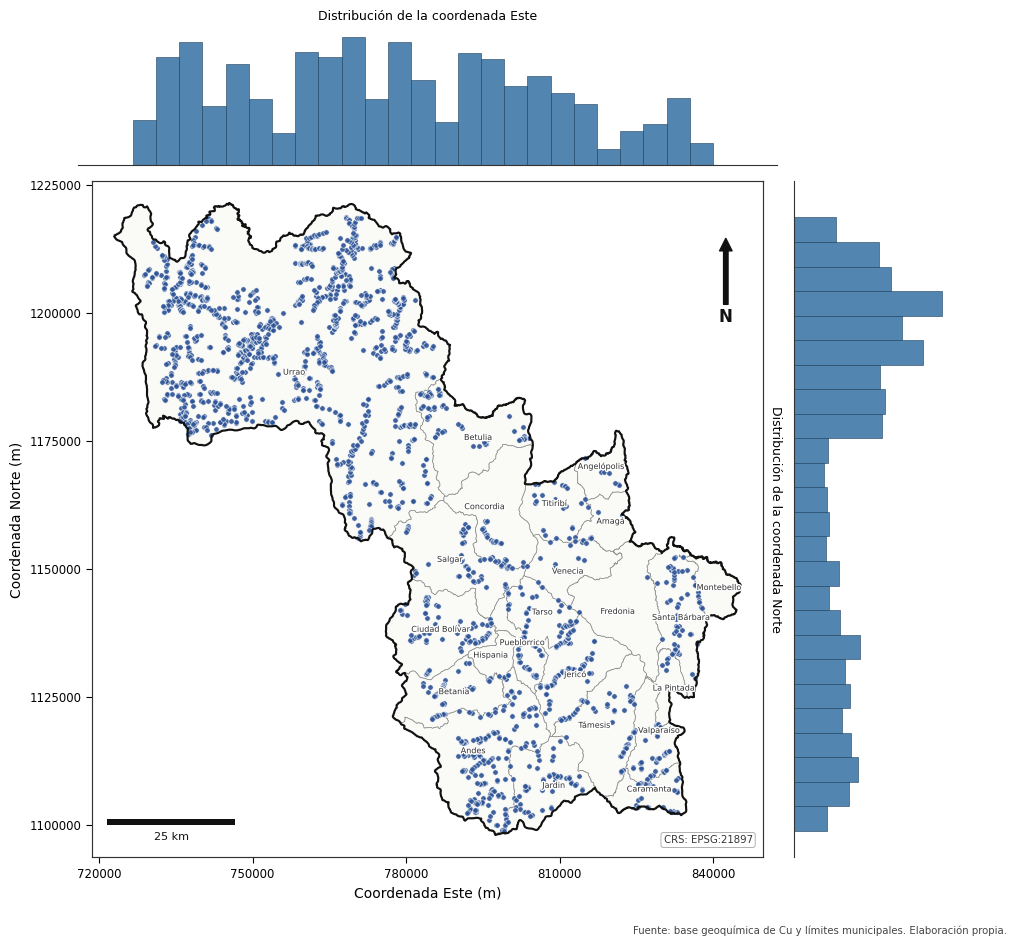

In [21]:
# ==========================================================
# FIGURA 06. DISTRIBUCIÓN ESPACIAL DE LAS MUESTRAS
# CON HISTOGRAMAS MARGINALES
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.ticker import MaxNLocator, ScalarFormatter
import matplotlib.patheffects as pe


# ----------------------------------------------------------
# 1. Preparar copias de trabajo
# ----------------------------------------------------------

municipios_fig = municipios.copy()

# Utilizar las muestras recortadas al área de estudio,
# si esa variable ya fue creada anteriormente.
if "muestras_estudio" in globals():
    muestras_fig = muestras_estudio.copy()
else:
    muestras_fig = muestras.copy()


# ----------------------------------------------------------
# 2. Eliminar geometrías nulas o vacías
# ----------------------------------------------------------

municipios_fig = municipios_fig[
    municipios_fig.geometry.notna()
    & ~municipios_fig.geometry.is_empty
].copy()

muestras_fig = muestras_fig[
    muestras_fig.geometry.notna()
    & ~muestras_fig.geometry.is_empty
].copy()


# ----------------------------------------------------------
# 3. Homogeneizar el sistema de referencia
# ----------------------------------------------------------

crs_mapa = municipios_fig.crs

if crs_mapa is None:
    raise ValueError(
        "La capa de municipios no tiene un sistema "
        "de referencia espacial definido."
    )

if muestras_fig.crs is None:
    raise ValueError(
        "La capa de muestras no tiene un sistema "
        "de referencia espacial definido."
    )

if muestras_fig.crs != crs_mapa:
    muestras_fig = muestras_fig.to_crs(crs_mapa)


# ----------------------------------------------------------
# 4. Extraer coordenadas de las muestras
# ----------------------------------------------------------

coordenada_este = muestras_fig.geometry.x.to_numpy()
coordenada_norte = muestras_fig.geometry.y.to_numpy()

mascara_valida = (
    np.isfinite(coordenada_este)
    & np.isfinite(coordenada_norte)
)

coordenada_este = coordenada_este[mascara_valida]
coordenada_norte = coordenada_norte[mascara_valida]


# ----------------------------------------------------------
# 5. Identificar nombres municipales
# ----------------------------------------------------------

columnas_nombre = [
    "NOMBRE",
    "NOMBRE_MPIO",
    "MPIO_CNMBR",
    "MUNICIPIO",
    "NOM_MPIO",
    "NOM_MUNIC"
]

columna_nombre = next(
    (
        columna
        for columna in columnas_nombre
        if columna in municipios_fig.columns
    ),
    None
)

if columna_nombre is not None:

    municipios_fig["NOMBRE_MAPA"] = (
        municipios_fig[columna_nombre]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )

else:

    municipios_fig["NOMBRE_MAPA"] = ""


# ----------------------------------------------------------
# 6. Corregir nombres municipales abreviados
# ----------------------------------------------------------

nombres_corregidos = {
    "S.BARBA": "Santa Bárbara",
    "C.BOLIV": "Ciudad Bolívar",
    "P.RICO": "Pueblorrico",
    "MONTEBE": "Montebello",
    "TITIRIB": "Titiribí",
    "TAMESIS": "Támesis",
    "JERICO": "Jericó",
    "HISPANI": "Hispania",
    "FREDONI": "Fredonia",
    "ANGELOP": "Angelópolis",
    "CARAMAN": "Caramanta",
    "VALPARA": "Valparaíso",
    "CONCORD": "Concordia",
    "PINTADA": "La Pintada"
}

municipios_fig["NOMBRE_MAPA"] = (
    municipios_fig["NOMBRE_MAPA"]
    .replace(nombres_corregidos)
)

municipios_fig["NOMBRE_MAPA"] = (
    municipios_fig["NOMBRE_MAPA"]
    .apply(
        lambda nombre: nombre.title()
        if nombre and nombre == nombre.upper()
        else nombre
    )
)


# ----------------------------------------------------------
# 7. Crear límite exterior y extensión
# ----------------------------------------------------------

limite_estudio = municipios_fig.dissolve()

xmin, ymin, xmax, ymax = municipios_fig.total_bounds

rango_x = xmax - xmin
rango_y = ymax - ymin

margen_x = rango_x * 0.035
margen_y = rango_y * 0.035

limite_x = (
    xmin - margen_x,
    xmax + margen_x
)

limite_y = (
    ymin - margen_y,
    ymax + margen_y
)


# ----------------------------------------------------------
# 8. Calcular número de intervalos de los histogramas
#    mediante la regla de Freedman-Diaconis
# ----------------------------------------------------------

def calcular_numero_bins(valores, minimo=10, maximo=45):
    """
    Calcula el número de intervalos mediante la regla de
    Freedman-Diaconis, estableciendo límites razonables.
    """

    valores = np.asarray(valores)
    valores = valores[np.isfinite(valores)]

    if len(valores) < 2:
        return minimo

    q1, q3 = np.percentile(valores, [25, 75])
    iqr = q3 - q1

    if iqr == 0:
        return int(
            np.clip(
                np.sqrt(len(valores)),
                minimo,
                maximo
            )
        )

    ancho = 2 * iqr / np.cbrt(len(valores))

    if ancho <= 0:
        return int(
            np.clip(
                np.sqrt(len(valores)),
                minimo,
                maximo
            )
        )

    numero_bins = int(
        np.ceil(
            (valores.max() - valores.min()) / ancho
        )
    )

    return int(
        np.clip(
            numero_bins,
            minimo,
            maximo
        )
    )


bins_este = 25
bins_norte = 25


# ----------------------------------------------------------
# 9. Crear la Figura 06 mediante GridSpec
# ----------------------------------------------------------

fig = plt.figure(
    figsize=(10.5, 9.5),
    facecolor="white"
)

rejilla = GridSpec(
    nrows=2,
    ncols=2,
    figure=fig,
    width_ratios=[5.6, 1.25],
    height_ratios=[1.15, 5.8],
    hspace=0.04,
    wspace=0.04
)

ax_hist_este = fig.add_subplot(
    rejilla[0, 0]
)

ax_mapa = fig.add_subplot(
    rejilla[1, 0],
    sharex=ax_hist_este
)

ax_hist_norte = fig.add_subplot(
    rejilla[1, 1],
    sharey=ax_mapa
)


# ----------------------------------------------------------
# 10. Histograma marginal de la coordenada Este
# ----------------------------------------------------------

ax_hist_este.hist(
    coordenada_este,
    bins=bins_este,
    color="#3F78A8",
    edgecolor="#1F3F5B",
    linewidth=0.45,
    alpha=0.90
)

ax_hist_este.set_xlim(limite_x)

ax_hist_este.tick_params(
    axis="x",
    bottom=False,
    labelbottom=False
)

ax_hist_este.tick_params(
    axis="y",
    left=False,
    labelleft=False
)

ax_hist_este.spines["top"].set_visible(False)
ax_hist_este.spines["right"].set_visible(False)
ax_hist_este.spines["left"].set_visible(False)
ax_hist_este.spines["bottom"].set_color("#333333")
ax_hist_este.spines["bottom"].set_linewidth(0.8)

ax_hist_este.set_title(
    "Distribución de la coordenada Este",
    fontsize=9,
    pad=8
)


# ----------------------------------------------------------
# 11. Histograma marginal de la coordenada Norte
# ----------------------------------------------------------

ax_hist_norte.hist(
    coordenada_norte,
    bins=bins_norte,
    orientation="horizontal",
    color="#3F78A8",
    edgecolor="#1F3F5B",
    linewidth=0.45,
    alpha=0.90
)

ax_hist_norte.set_ylim(limite_y)

ax_hist_norte.tick_params(
    axis="x",
    bottom=False,
    labelbottom=False
)

ax_hist_norte.tick_params(
    axis="y",
    left=False,
    labelleft=False
)

ax_hist_norte.spines["top"].set_visible(False)
ax_hist_norte.spines["right"].set_visible(False)
ax_hist_norte.spines["bottom"].set_visible(False)
ax_hist_norte.spines["left"].set_color("#333333")
ax_hist_norte.spines["left"].set_linewidth(0.8)

ax_hist_norte.set_ylabel(
    "Distribución de la coordenada Norte",
    fontsize=9,
    rotation=270,
    labelpad=18
)


# ----------------------------------------------------------
# 12. Representar municipios en el mapa central
# ----------------------------------------------------------

municipios_fig.plot(
    ax=ax_mapa,
    facecolor="#FAFAF7",
    edgecolor="#888888",
    linewidth=0.50,
    alpha=1.0,
    zorder=1
)


# ----------------------------------------------------------
# 13. Representar las muestras
# ----------------------------------------------------------

muestras_fig.plot(
    ax=ax_mapa,
    color="#2F5597",
    marker="o",
    markersize=15,
    edgecolor="white",
    linewidth=0.40,
    alpha=0.92,
    zorder=3
)


# ----------------------------------------------------------
# 14. Resaltar el límite del área de estudio
# ----------------------------------------------------------

limite_estudio.boundary.plot(
    ax=ax_mapa,
    color="#111111",
    linewidth=1.55,
    zorder=4
)


# ----------------------------------------------------------
# 15. Añadir etiquetas municipales
# ----------------------------------------------------------

for _, fila in municipios_fig.iterrows():

    nombre = fila["NOMBRE_MAPA"]

    if not nombre:
        continue

    punto = fila.geometry.representative_point()

    texto = ax_mapa.text(
        punto.x,
        punto.y,
        nombre,
        fontsize=5.8,
        ha="center",
        va="center",
        color="#303030",
        zorder=5
    )

    texto.set_path_effects([
        pe.withStroke(
            linewidth=2.0,
            foreground="white"
        )
    ])


# ----------------------------------------------------------
# 16. Configurar extensión, proporción y coordenadas
# ----------------------------------------------------------

ax_mapa.set_xlim(limite_x)
ax_mapa.set_ylim(limite_y)
ax_mapa.set_aspect("equal")

ax_mapa.set_xlabel(
    "Coordenada Este (m)",
    fontsize=10
)

ax_mapa.set_ylabel(
    "Coordenada Norte (m)",
    fontsize=10
)

ax_mapa.xaxis.set_major_locator(
    MaxNLocator(nbins=5)
)

ax_mapa.yaxis.set_major_locator(
    MaxNLocator(nbins=6)
)

formato_coordenadas = ScalarFormatter(
    useOffset=False,
    useMathText=False
)

formato_coordenadas.set_scientific(False)

ax_mapa.xaxis.set_major_formatter(
    formato_coordenadas
)

ax_mapa.yaxis.set_major_formatter(
    formato_coordenadas
)

ax_mapa.tick_params(
    axis="both",
    labelsize=8.5,
    direction="out",
    length=4,
    width=0.8
)

ax_mapa.ticklabel_format(
    style="plain",
    axis="both",
    useOffset=False
)

ax_mapa.grid(False)


# ----------------------------------------------------------
# 17. Flecha norte
# ----------------------------------------------------------

ax_mapa.annotate(
    "N",
    xy=(0.945, 0.915),
    xytext=(0.945, 0.800),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    color="#111111",
    arrowprops=dict(
        facecolor="#111111",
        edgecolor="#111111",
        width=3.2,
        headwidth=9,
        headlength=9
    ),
    zorder=10
)


# ----------------------------------------------------------
# 18. Barra de escala
# ----------------------------------------------------------

barra_escala = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",
    location="lower left",
    length_fraction=0.23,
    width_fraction=0.008,
    box_alpha=0.90,
    box_color="white",
    color="#111111",
    font_properties={"size": 8},
    border_pad=0.7,
    pad=0.4
)

ax_mapa.add_artist(barra_escala)


# ----------------------------------------------------------
# 19. Sistema de referencia espacial
# ----------------------------------------------------------

epsg_mapa = crs_mapa.to_epsg()

if epsg_mapa is not None:
    texto_crs = f"CRS: EPSG:{epsg_mapa}"
else:
    texto_crs = f"CRS: {crs_mapa.name}"

ax_mapa.text(
    0.985,
    0.018,
    texto_crs,
    transform=ax_mapa.transAxes,
    fontsize=7.3,
    ha="right",
    va="bottom",
    color="#333333",
    bbox=dict(
        facecolor="white",
        edgecolor="#888888",
        linewidth=0.50,
        alpha=0.92,
        boxstyle="round,pad=0.25"
    ),
    zorder=10
)


# ----------------------------------------------------------
# 20. Marco cartográfico
# ----------------------------------------------------------

for borde in ax_mapa.spines.values():
    borde.set_visible(True)
    borde.set_color("#333333")
    borde.set_linewidth(0.85)


# ----------------------------------------------------------
# 21. Fuente de los datos
# ----------------------------------------------------------

fig.text(
    0.985,
    0.018,
    (
        "Fuente: base geoquímica de Cu y límites municipales. "
        "Elaboración propia."
    ),
    ha="right",
    va="bottom",
    fontsize=7.3,
    color="#444444"
)


# ----------------------------------------------------------
# 22. Ajustar distribución
# ----------------------------------------------------------

fig.subplots_adjust(
    left=0.10,
    right=0.93,
    bottom=0.10,
    top=0.97
)


# ----------------------------------------------------------
# 23. Guardar únicamente en PNG
# ----------------------------------------------------------

nombre_archivo = (
    "Figura_06_Distribucion_Espacial_Muestras_"
    "Histogramas_Marginales.png"
)

ruta_png_figura_06 = FIGURAS / nombre_archivo

fig.savefig(
    ruta_png_figura_06,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.12,
    facecolor="white"
)

print("=" * 68)
print("FIGURA 06 GENERADA Y GUARDADA CORRECTAMENTE")
print("=" * 68)
print(f"PNG: {ruta_png_figura_06}")
print(f"Número de muestras representadas: {len(muestras_fig):,}")
print(f"Intervalos histograma Este: {bins_este}")
print(f"Intervalos histograma Norte: {bins_norte}")
print("=" * 68)

plt.show()

**Figura 06.** Distribucion espacial de las muestras con histogramas marginales texto en cursiva

La Figura 06 muestra la distribución espacial de las muestras geoquímicas de cobre y sus distribuciones marginales en las coordenadas Este y Norte. La figura permite identificar la cobertura y la densidad del muestreo como base para el análisis del patrón espacial.

##3.3 Caracterización del patrón espacial mediante centrografía

En esta sección se aplican las medidas de centrografía para resumir la distribución espacial de las muestras geoquímicas. Estas medidas permiten identificar la tendencia central del conjunto de datos y cuantificar su dispersión espacial mediante indicadores descriptivos, facilitando la interpretación del patrón general de distribución.

Indicador,Valor,Unidad
Centro medio - Este,"777,415.70",m
Centro medio - Norte,"1,167,942.23",m
Centro mediano - Este,"772,135.19",m
Centro mediano - Norte,"1,177,188.16",m
Distancia estándar,"45,074.27",m
Semieje mayor de la elipse,"60,303.04",m
Semieje menor de la elipse,"20,758.89",m
Rotación de la elipse,-52.94,grados


TABLA 06 Y FIGURA 07 GENERADAS CORRECTAMENTE
Muestras utilizadas: 2,029
Centro medio: E=777,415.70 m | N=1,167,942.23 m
Centro mediano: E=772,135.19 m | N=1,177,188.16 m
Distancia estándar: 45,074.27 m
Rotación de la elipse: -52.94°
------------------------------------------------------------------------
CSV: /content/drive/MyDrive/Analisis_Geoespacial_Cobre/04_Resultados/01_Tablas/Tabla_06_Medidas_Centrografia_Muestreo.csv
PNG: /content/drive/MyDrive/Analisis_Geoespacial_Cobre/03_Figuras/Figura_07_Centrografia_Patron_Muestreo.png


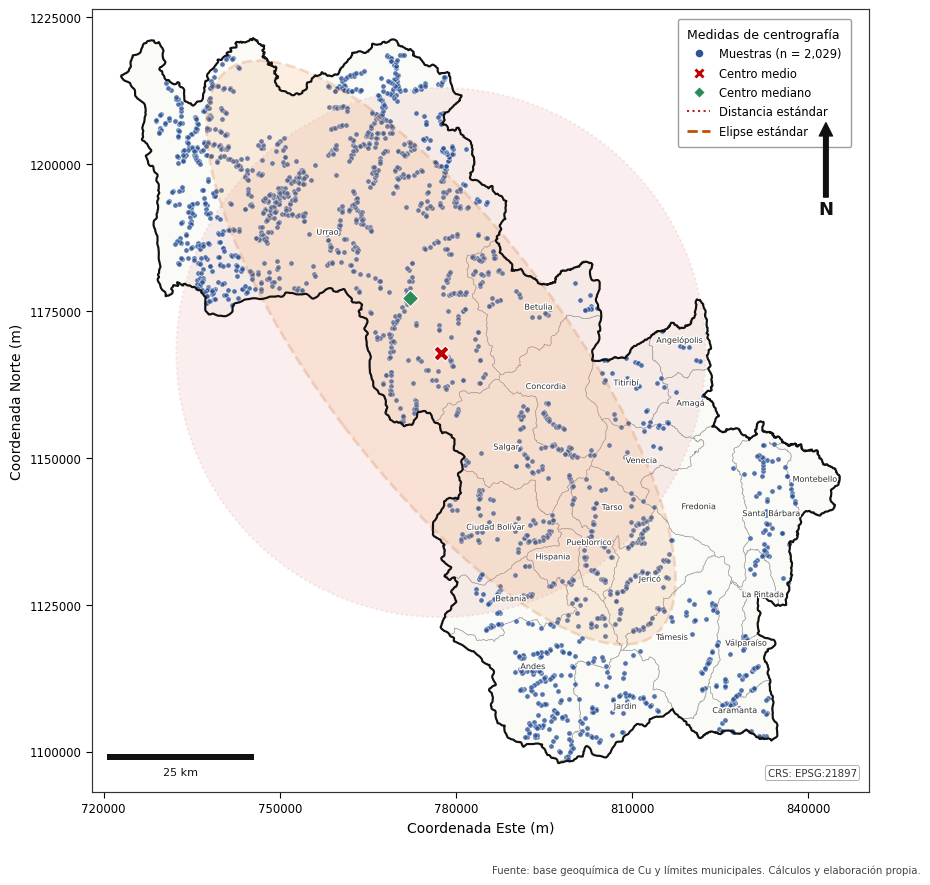

In [25]:


# ==========================================================
# TABLA 06 Y FIGURA 07.
# CENTROGRAFÍA DEL PATRÓN DE MUESTREO
# ==========================================================

!pip -q install pointpats

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from pointpats import centrography
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse, Circle
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.ticker import MaxNLocator, ScalarFormatter


# ----------------------------------------------------------
# 1. Preparar las capas
# ----------------------------------------------------------

municipios_centro = municipios.copy()

# Usar preferentemente las 2.029 muestras del área de estudio
if "muestras_estudio" in globals():
    muestras_centro = muestras_estudio.copy()
else:
    muestras_centro = muestras.copy()


# ----------------------------------------------------------
# 2. Eliminar geometrías nulas o vacías
# ----------------------------------------------------------

municipios_centro = municipios_centro[
    municipios_centro.geometry.notna()
    & ~municipios_centro.geometry.is_empty
].copy()

muestras_centro = muestras_centro[
    muestras_centro.geometry.notna()
    & ~muestras_centro.geometry.is_empty
].copy()


# ----------------------------------------------------------
# 3. Verificar y homologar el CRS
# ----------------------------------------------------------

crs_mapa = municipios_centro.crs

if crs_mapa is None:
    raise ValueError(
        "La capa de municipios no tiene un CRS definido."
    )

if muestras_centro.crs is None:
    raise ValueError(
        "La capa de muestras no tiene un CRS definido."
    )

if not crs_mapa.is_projected:
    raise ValueError(
        "La centrografía debe calcularse en un CRS proyectado."
    )

if muestras_centro.crs != crs_mapa:
    muestras_centro = muestras_centro.to_crs(crs_mapa)


# ----------------------------------------------------------
# 4. Extraer coordenadas XY
# ----------------------------------------------------------

coordenadas = np.column_stack([
    muestras_centro.geometry.x.to_numpy(),
    muestras_centro.geometry.y.to_numpy()
])

mascara_valida = np.isfinite(
    coordenadas
).all(axis=1)

coordenadas = coordenadas[
    mascara_valida
]

if len(coordenadas) < 3:
    raise ValueError(
        "Se requieren al menos tres muestras válidas "
        "para calcular la centrografía."
    )


# ----------------------------------------------------------
# 5. Calcular las medidas de centrografía
# ----------------------------------------------------------

centro_medio = centrography.mean_center(
    coordenadas
)

centro_mediano = centrography.euclidean_median(
    coordenadas
)

distancia_estandar = centrography.std_distance(
    coordenadas
)

semieje_mayor, semieje_menor, rotacion_radianes = (
    centrography.ellipse(coordenadas)
)

rotacion_grados = np.rad2deg(
    rotacion_radianes
)


# ==========================================================
# TABLA 06. MEDIDAS DE CENTROGRAFÍA
# ==========================================================

# ----------------------------------------------------------
# 6. Construir la Tabla 06
# ----------------------------------------------------------

tabla_06 = pd.DataFrame({
    "Indicador": [
        "Centro medio - Este",
        "Centro medio - Norte",
        "Centro mediano - Este",
        "Centro mediano - Norte",
        "Distancia estándar",
        "Semieje mayor de la elipse",
        "Semieje menor de la elipse",
        "Rotación de la elipse"
    ],
    "Valor": [
        centro_medio[0],
        centro_medio[1],
        centro_mediano[0],
        centro_mediano[1],
        distancia_estandar,
        semieje_mayor,
        semieje_menor,
        rotacion_grados
    ],
    "Unidad": [
        "m",
        "m",
        "m",
        "m",
        "m",
        "m",
        "m",
        "grados"
    ]
})


# ----------------------------------------------------------
# 7. Mostrar la Tabla 06
# ----------------------------------------------------------

tabla_06_estilizada = (
    tabla_06.style
    .hide(axis="index")
    .set_caption(
        "Tabla 06. Medidas de centrografía "
        "del patrón de muestreo"
    )
    .format({
        "Valor": "{:,.2f}"
    })
    .set_properties(
        subset=["Valor", "Unidad"],
        **{"text-align": "center"}
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "13px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "1px solid #555555"),
                ("padding", "7px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "7px"),
                ("border-bottom", "1px solid #D9D9D9")
            ]
        }
    ])
)

display(tabla_06_estilizada)


# ----------------------------------------------------------
# 8. Guardar la Tabla 06
# ----------------------------------------------------------

ruta_tabla_06 = (
    TABLAS
    / "Tabla_06_Medidas_Centrografia_Muestreo.csv"
)

tabla_06.to_csv(
    ruta_tabla_06,
    index=False,
    encoding="utf-8-sig"
)


# ==========================================================
# FIGURA 07. CENTROGRAFÍA DEL PATRÓN DE MUESTREO
# ==========================================================

# ----------------------------------------------------------
# 9. Preparar nombres municipales
# ----------------------------------------------------------

columnas_nombre = [
    "NOMBRE",
    "NOMBRE_MPIO",
    "MPIO_CNMBR",
    "MUNICIPIO",
    "NOM_MPIO",
    "NOM_MUNIC"
]

columna_nombre = next(
    (
        columna
        for columna in columnas_nombre
        if columna in municipios_centro.columns
    ),
    None
)

if columna_nombre is not None:

    municipios_centro["NOMBRE_MAPA"] = (
        municipios_centro[columna_nombre]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )

else:

    municipios_centro["NOMBRE_MAPA"] = ""


# ----------------------------------------------------------
# 10. Corregir nombres abreviados
# ----------------------------------------------------------

nombres_corregidos = {
    "S.BARBA": "Santa Bárbara",
    "C.BOLIV": "Ciudad Bolívar",
    "P.RICO": "Pueblorrico",
    "MONTEBE": "Montebello",
    "TITIRIB": "Titiribí",
    "TAMESIS": "Támesis",
    "JERICO": "Jericó",
    "HISPANI": "Hispania",
    "FREDONI": "Fredonia",
    "ANGELOP": "Angelópolis",
    "CARAMAN": "Caramanta",
    "VALPARA": "Valparaíso",
    "CONCORD": "Concordia",
    "PINTADA": "La Pintada"
}

municipios_centro["NOMBRE_MAPA"] = (
    municipios_centro["NOMBRE_MAPA"]
    .replace(nombres_corregidos)
)

municipios_centro["NOMBRE_MAPA"] = (
    municipios_centro["NOMBRE_MAPA"]
    .apply(
        lambda nombre: (
            nombre.title()
            if nombre and nombre == nombre.upper()
            else nombre
        )
    )
)


# ----------------------------------------------------------
# 11. Calcular límite y extensión
# ----------------------------------------------------------

limite_estudio = municipios_centro.dissolve()

xmin, ymin, xmax, ymax = (
    municipios_centro.total_bounds
)

margen_x = (
    xmax - xmin
) * 0.04

margen_y = (
    ymax - ymin
) * 0.04


# ----------------------------------------------------------
# 12. Crear la Figura 07
# ----------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 9),
    facecolor="white"
)


# ----------------------------------------------------------
# 13. Dibujar municipios
# ----------------------------------------------------------

municipios_centro.plot(
    ax=ax,
    facecolor="#FAFAF7",
    edgecolor="#999999",
    linewidth=0.45,
    zorder=1
)


# ----------------------------------------------------------
# 14. Dibujar las muestras
# ----------------------------------------------------------

muestras_centro.plot(
    ax=ax,
    color="#2F5597",
    marker="o",
    markersize=14,
    edgecolor="white",
    linewidth=0.35,
    alpha=0.82,
    zorder=3
)


# ----------------------------------------------------------
# 15. Dibujar la distancia estándar
# ----------------------------------------------------------

circulo_distancia = Circle(
    xy=centro_medio,
    radius=distancia_estandar,
    facecolor="#D95F5F",
    edgecolor="#B22222",
    linewidth=1.4,
    linestyle=":",
    alpha=0.10,
    zorder=2
)

ax.add_patch(
    circulo_distancia
)


# ----------------------------------------------------------
# 16. Dibujar la elipse estándar
# ----------------------------------------------------------

elipse_estandar = Ellipse(
    xy=centro_medio,
    width=semieje_mayor * 2,
    height=semieje_menor * 2,
    angle=rotacion_grados,
    facecolor="#F4A261",
    edgecolor="#C44E00",
    linewidth=2.0,
    linestyle="--",
    alpha=0.18,
    zorder=4
)

ax.add_patch(
    elipse_estandar
)


# ----------------------------------------------------------
# 17. Dibujar el centro medio
# ----------------------------------------------------------

ax.scatter(
    centro_medio[0],
    centro_medio[1],
    marker="X",
    s=125,
    color="#C00000",
    edgecolor="white",
    linewidth=0.9,
    zorder=7
)


# ----------------------------------------------------------
# 18. Dibujar el centro mediano
# ----------------------------------------------------------

ax.scatter(
    centro_mediano[0],
    centro_mediano[1],
    marker="D",
    s=70,
    color="#2E8B57",
    edgecolor="white",
    linewidth=0.8,
    zorder=7
)


# ----------------------------------------------------------
# 19. Dibujar límite exterior
# ----------------------------------------------------------

limite_estudio.boundary.plot(
    ax=ax,
    color="#111111",
    linewidth=1.55,
    zorder=5
)


# ----------------------------------------------------------
# 20. Añadir nombres municipales
# ----------------------------------------------------------

for _, fila in municipios_centro.iterrows():

    nombre = fila["NOMBRE_MAPA"]

    if not nombre:
        continue

    punto = fila.geometry.representative_point()

    texto = ax.text(
        punto.x,
        punto.y,
        nombre,
        fontsize=5.8,
        ha="center",
        va="center",
        color="#303030",
        zorder=6
    )

    texto.set_path_effects([
        pe.withStroke(
            linewidth=1.9,
            foreground="white"
        )
    ])


# ----------------------------------------------------------
# 21. Configurar extensión y ejes
# ----------------------------------------------------------

ax.set_xlim(
    xmin - margen_x,
    xmax + margen_x
)

ax.set_ylim(
    ymin - margen_y,
    ymax + margen_y
)

ax.set_aspect("equal")

ax.set_xlabel(
    "Coordenada Este (m)",
    fontsize=10
)

ax.set_ylabel(
    "Coordenada Norte (m)",
    fontsize=10
)

ax.xaxis.set_major_locator(
    MaxNLocator(nbins=5)
)

ax.yaxis.set_major_locator(
    MaxNLocator(nbins=6)
)

formato_coordenadas = ScalarFormatter(
    useOffset=False,
    useMathText=False
)

formato_coordenadas.set_scientific(False)

ax.xaxis.set_major_formatter(
    formato_coordenadas
)

ax.yaxis.set_major_formatter(
    formato_coordenadas
)

ax.tick_params(
    axis="both",
    labelsize=8.5,
    direction="out",
    length=4,
    width=0.8
)

ax.ticklabel_format(
    style="plain",
    axis="both",
    useOffset=False
)

ax.grid(False)


# ----------------------------------------------------------
# 22. Añadir flecha norte
# ----------------------------------------------------------

ax.annotate(
    "N",
    xy=(0.945, 0.855),
    xytext=(0.945, 0.745),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    color="#111111",
    arrowprops=dict(
        facecolor="#111111",
        edgecolor="#111111",
        width=3.3,
        headwidth=9.5,
        headlength=9.5
    ),
    zorder=10
)


# ----------------------------------------------------------
# 23. Añadir barra de escala
# ----------------------------------------------------------

barra_escala = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",
    location="lower left",
    length_fraction=0.22,
    width_fraction=0.008,
    box_alpha=0.90,
    box_color="white",
    color="#111111",
    font_properties={"size": 8},
    border_pad=0.7,
    pad=0.4
)

ax.add_artist(
    barra_escala
)


# ----------------------------------------------------------
# 24. Crear leyenda
# ----------------------------------------------------------

elementos_leyenda = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="#2F5597",
        markeredgecolor="white",
        markersize=6.5,
        label=f"Muestras (n = {len(muestras_centro):,})"
    ),
    Line2D(
        [0],
        [0],
        marker="X",
        linestyle="none",
        markerfacecolor="#C00000",
        markeredgecolor="white",
        markersize=8,
        label="Centro medio"
    ),
    Line2D(
        [0],
        [0],
        marker="D",
        linestyle="none",
        markerfacecolor="#2E8B57",
        markeredgecolor="white",
        markersize=6.5,
        label="Centro mediano"
    ),
    Line2D(
        [0],
        [0],
        color="#B22222",
        linewidth=1.5,
        linestyle=":",
        label="Distancia estándar"
    ),
    Line2D(
        [0],
        [0],
        color="#C44E00",
        linewidth=2.0,
        linestyle="--",
        label="Elipse estándar"
    )
]

leyenda = ax.legend(
    handles=elementos_leyenda,
    loc="upper right",
    bbox_to_anchor=(0.985, 0.995),
    frameon=True,
    facecolor="white",
    edgecolor="#999999",
    framealpha=0.96,
    fontsize=8.3,
    title="Medidas de centrografía",
    title_fontsize=9,
    borderpad=0.8,
    labelspacing=0.55
)

leyenda._legend_box.align = "left"


# ----------------------------------------------------------
# 25. Añadir CRS
# ----------------------------------------------------------

epsg_mapa = crs_mapa.to_epsg()

if epsg_mapa is not None:
    texto_crs = f"CRS: EPSG:{epsg_mapa}"
else:
    texto_crs = f"CRS: {crs_mapa.name}"

ax.text(
    0.985,
    0.018,
    texto_crs,
    transform=ax.transAxes,
    fontsize=7.3,
    ha="right",
    va="bottom",
    color="#333333",
    bbox=dict(
        facecolor="white",
        edgecolor="#888888",
        linewidth=0.50,
        alpha=0.92,
        boxstyle="round,pad=0.25"
    ),
    zorder=10
)


# ----------------------------------------------------------
# 26. Configurar marco
# ----------------------------------------------------------

for borde in ax.spines.values():

    borde.set_visible(True)
    borde.set_color("#333333")
    borde.set_linewidth(0.85)


# ----------------------------------------------------------
# 27. Añadir fuente
# ----------------------------------------------------------

fig.text(
    0.98,
    0.018,
    (
        "Fuente: base geoquímica de Cu y límites municipales. "
        "Cálculos y elaboración propia."
    ),
    ha="right",
    va="bottom",
    fontsize=7.3,
    color="#444444"
)


# ----------------------------------------------------------
# 28. Ajustar distribución
# ----------------------------------------------------------

fig.subplots_adjust(
    left=0.11,
    right=0.97,
    bottom=0.11,
    top=0.98
)


# ----------------------------------------------------------
# 29. Guardar la Figura 07
# ----------------------------------------------------------

ruta_figura_07 = (
    FIGURAS
    / "Figura_07_Centrografia_Patron_Muestreo.png"
)

fig.savefig(
    ruta_figura_07,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.12,
    facecolor="white"
)


# ----------------------------------------------------------
# 30. Confirmar resultados
# ----------------------------------------------------------

print("=" * 72)
print("TABLA 06 Y FIGURA 07 GENERADAS CORRECTAMENTE")
print("=" * 72)

print(
    f"Muestras utilizadas: "
    f"{len(muestras_centro):,}"
)

print(
    f"Centro medio: "
    f"E={centro_medio[0]:,.2f} m | "
    f"N={centro_medio[1]:,.2f} m"
)

print(
    f"Centro mediano: "
    f"E={centro_mediano[0]:,.2f} m | "
    f"N={centro_mediano[1]:,.2f} m"
)

print(
    f"Distancia estándar: "
    f"{distancia_estandar:,.2f} m"
)

print(
    f"Rotación de la elipse: "
    f"{rotacion_grados:,.2f}°"
)

print("-" * 72)
print(f"CSV: {ruta_tabla_06}")
print(f"PNG: {ruta_figura_07}")
print("=" * 72)

plt.show()

**Figura *07*.** Centrografia del patron de *muestreo*

La centrografía aporta una síntesis de la localización, dispersión y orientación del esquema de muestreo, permitiendo evaluar la representatividad espacial de la información antes de aplicar los métodos geoestadísticos.

# 3.4 Caracterización del patrón espacial mediante densidad Kernel

Con el conjunto definitivo de 2.029 muestras se estimó la densidad Kernel del patrón de muestreo, con el propósito de identificar las zonas donde las observaciones presentan mayor o menor concentración espacial. Este procedimiento permite evaluar la intensidad del esfuerzo de muestreo dentro del área de análisis y constituye un insumo para interpretar posteriormente la representatividad espacial de la información utilizada en el análisis geoestadístico.

In [26]:
# ==========================================================
# TABLA 07. PARÁMETROS DE LA ESTIMACIÓN KERNEL
# ==========================================================

import numpy as np
import pandas as pd
import geopandas as gpd

from scipy.stats import gaussian_kde


# ----------------------------------------------------------
# 1. Preparar las capas
# ----------------------------------------------------------

muestras_kernel = muestras.copy()
municipios_kernel = municipios.copy()


# ----------------------------------------------------------
# 2. Eliminar geometrías nulas o vacías
# ----------------------------------------------------------

muestras_kernel = muestras_kernel[
    muestras_kernel.geometry.notna()
    & ~muestras_kernel.geometry.is_empty
].copy()

municipios_kernel = municipios_kernel[
    municipios_kernel.geometry.notna()
    & ~municipios_kernel.geometry.is_empty
].copy()


# ----------------------------------------------------------
# 3. Verificar y homologar el CRS
# ----------------------------------------------------------

crs_kernel = municipios_kernel.crs

if crs_kernel is None:
    raise ValueError(
        "La capa de municipios no tiene un CRS definido."
    )

if muestras_kernel.crs is None:
    raise ValueError(
        "La capa de muestras no tiene un CRS definido."
    )

if not crs_kernel.is_projected:
    raise ValueError(
        "La densidad Kernel debe calcularse en un CRS "
        "proyectado con unidades lineales."
    )

if muestras_kernel.crs != crs_kernel:
    muestras_kernel = muestras_kernel.to_crs(
        crs_kernel
    )


# ----------------------------------------------------------
# 4. Crear el polígono del área de análisis
# ----------------------------------------------------------

poligono_kernel = (
    municipios_kernel
    .geometry
    .union_all()
)


# ----------------------------------------------------------
# 5. Verificar que las muestras estén dentro del polígono
# ----------------------------------------------------------

mascara_kernel = muestras_kernel.geometry.apply(
    lambda geometria: poligono_kernel.covers(geometria)
)

if not mascara_kernel.all():

    cantidad_externa = int(
        (~mascara_kernel).sum()
    )

    print(
        f"Advertencia: se excluyeron {cantidad_externa} "
        "muestras externas al polígono."
    )

    muestras_kernel = muestras_kernel[
        mascara_kernel
    ].copy()


# ----------------------------------------------------------
# 6. Extraer las coordenadas
# ----------------------------------------------------------

x_kernel = muestras_kernel.geometry.x.to_numpy()
y_kernel = muestras_kernel.geometry.y.to_numpy()

mascara_coordenadas = (
    np.isfinite(x_kernel)
    & np.isfinite(y_kernel)
)

x_kernel = x_kernel[
    mascara_coordenadas
]

y_kernel = y_kernel[
    mascara_coordenadas
]

if len(x_kernel) < 3:
    raise ValueError(
        "Se requieren al menos tres muestras válidas "
        "para calcular la densidad Kernel."
    )

coordenadas_kernel = np.vstack([
    x_kernel,
    y_kernel
])


# ----------------------------------------------------------
# 7. Ajustar el modelo Kernel
# ----------------------------------------------------------
# Kernel gaussiano y regla de Scott para seleccionar
# automáticamente el ancho de banda.

modelo_kernel = gaussian_kde(
    coordenadas_kernel,
    bw_method="scott"
)

factor_banda_kernel = float(
    modelo_kernel.factor
)

desviacion_este = np.std(
    x_kernel,
    ddof=1
)

desviacion_norte = np.std(
    y_kernel,
    ddof=1
)

banda_este_kernel = (
    factor_banda_kernel
    * desviacion_este
)

banda_norte_kernel = (
    factor_banda_kernel
    * desviacion_norte
)

banda_promedio_kernel = np.sqrt(
    banda_este_kernel
    * banda_norte_kernel
)


# ----------------------------------------------------------
# 8. Definir la resolución de la malla
# ----------------------------------------------------------

RESOLUCION_KERNEL = 300

xmin_kernel, ymin_kernel, xmax_kernel, ymax_kernel = (
    municipios_kernel.total_bounds
)

tamano_celda_este = (
    xmax_kernel - xmin_kernel
) / (RESOLUCION_KERNEL - 1)

tamano_celda_norte = (
    ymax_kernel - ymin_kernel
) / (RESOLUCION_KERNEL - 1)

tamano_celda_promedio = (
    tamano_celda_este
    + tamano_celda_norte
) / 2


# ----------------------------------------------------------
# 9. Construir la Tabla 07
# ----------------------------------------------------------

tabla_07 = pd.DataFrame({
    "Parámetro": [
        "Número de muestras",
        "Tipo de Kernel",
        "Método de selección de banda",
        "Factor de banda",
        "Banda efectiva Este",
        "Banda efectiva Norte",
        "Banda efectiva promedio",
        "Resolución de la malla",
        "Tamaño aproximado de celda",
        "Variable representada"
    ],

    "Valor": [
        len(muestras_kernel),
        "Gaussiano",
        "Regla de Scott",
        factor_banda_kernel,
        banda_este_kernel,
        banda_norte_kernel,
        banda_promedio_kernel,
        f"{RESOLUCION_KERNEL} × {RESOLUCION_KERNEL}",
        tamano_celda_promedio,
        "Densidad relativa de ubicaciones de muestreo"
    ],

    "Unidad": [
        "muestras",
        "—",
        "—",
        "adimensional",
        "m",
        "m",
        "m",
        "celdas",
        "m",
        "0–1"
    ]
})


# ----------------------------------------------------------
# 10. Mostrar la Tabla 07
# ----------------------------------------------------------

def formato_valor_kernel(valor):

    if isinstance(
        valor,
        (int, float, np.integer, np.floating)
    ):
        return f"{valor:,.2f}"

    return str(valor)


tabla_07_estilizada = (
    tabla_07.style
    .hide(axis="index")
    .set_caption(
        "Tabla 07. Parámetros de la estimación Kernel "
        "del patrón de muestreo"
    )
    .format({
        "Valor": formato_valor_kernel
    })
    .set_properties(
        subset=[
            "Valor",
            "Unidad"
        ],
        **{
            "text-align": "center"
        }
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "13px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "1px solid #555555"),
                ("padding", "7px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "7px"),
                ("border-bottom", "1px solid #D9D9D9"),
                ("vertical-align", "top")
            ]
        }
    ])
)

display(tabla_07_estilizada)


# ----------------------------------------------------------
# 11. Guardar únicamente en CSV
# ----------------------------------------------------------

ruta_tabla_07 = (
    TABLAS
    / "Tabla_07_Parametros_Densidad_Kernel.csv"
)

tabla_07.to_csv(
    ruta_tabla_07,
    index=False,
    encoding="utf-8-sig"
)


# ----------------------------------------------------------
# 12. Confirmar resultados
# ----------------------------------------------------------

print("=" * 72)
print("TABLA 07 GENERADA CORRECTAMENTE")
print("=" * 72)

print(
    f"Muestras utilizadas        : "
    f"{len(muestras_kernel):,}"
)

print(
    f"Factor de banda de Scott   : "
    f"{factor_banda_kernel:.6f}"
)

print(
    f"Banda efectiva Este        : "
    f"{banda_este_kernel:,.2f} m"
)

print(
    f"Banda efectiva Norte       : "
    f"{banda_norte_kernel:,.2f} m"
)

print(
    f"Banda efectiva promedio    : "
    f"{banda_promedio_kernel:,.2f} m"
)

print(
    f"Tamaño aproximado de celda : "
    f"{tamano_celda_promedio:,.2f} m"
)

print("-" * 72)
print(f"CSV: {ruta_tabla_07}")
print("=" * 72)

Parámetro,Valor,Unidad
Número de muestras,"2,029.00",muestras
Tipo de Kernel,Gaussiano,—
Método de selección de banda,Regla de Scott,—
Factor de banda,0.28,adimensional
Banda efectiva Este,"7,935.05",m
Banda efectiva Norte,"9,879.15",m
Banda efectiva promedio,"8,853.90",m
Resolución de la malla,300 × 300,celdas
Tamaño aproximado de celda,411.20,m
Variable representada,Densidad relativa de ubicaciones de muestreo,0–1


TABLA 07 GENERADA CORRECTAMENTE
Muestras utilizadas        : 2,029
Factor de banda de Scott   : 0.281052
Banda efectiva Este        : 7,935.05 m
Banda efectiva Norte       : 9,879.15 m
Banda efectiva promedio    : 8,853.90 m
Tamaño aproximado de celda : 411.20 m
------------------------------------------------------------------------
CSV: /content/drive/MyDrive/Analisis_Geoespacial_Cobre/04_Resultados/01_Tablas/Tabla_07_Parametros_Densidad_Kernel.csv


FIGURA 09 GENERADA CORRECTAMENTE
Muestras utilizadas: 2,029
Densidad mínima relativa: 0.0105
Densidad máxima relativa: 1.0000
------------------------------------------------------------------------
PNG: /content/drive/MyDrive/Analisis_Geoespacial_Cobre/03_Figuras/Figura_09_Densidad_Kernel_Patron_Muestreo.png


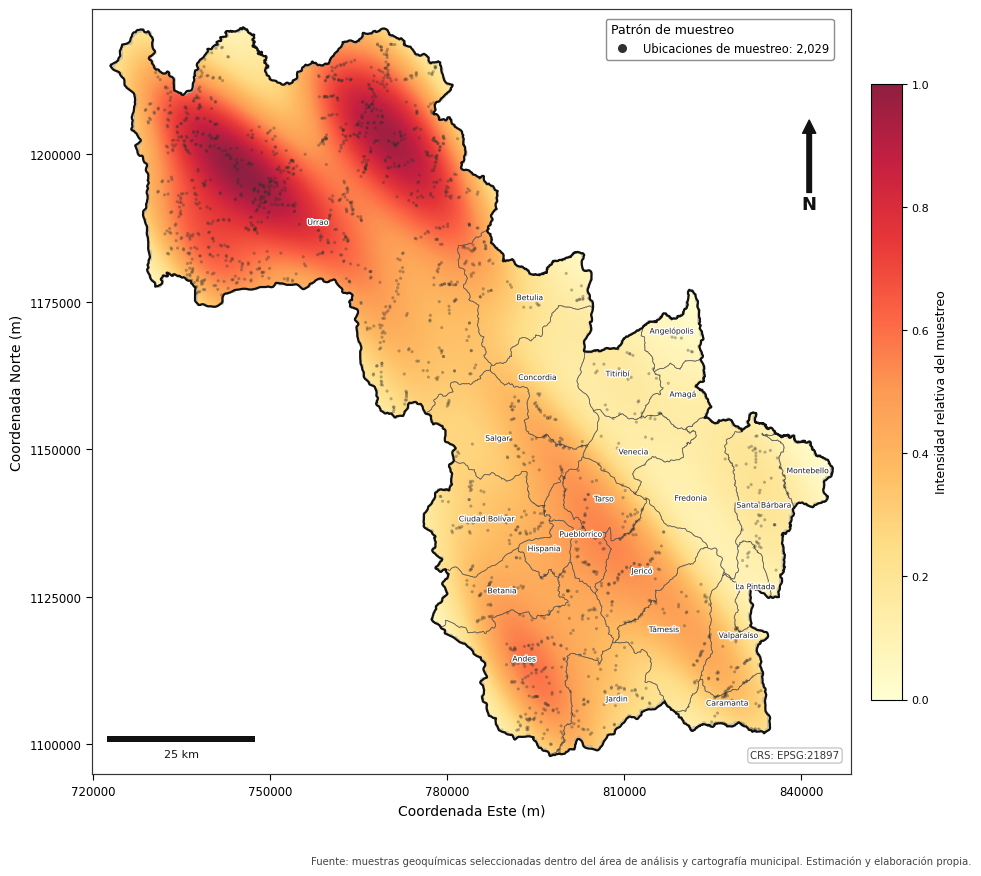

In [27]:
# ==========================================================
# FIGURA 09. DENSIDAD KERNEL DEL PATRÓN DE MUESTREO
# ==========================================================

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from matplotlib.lines import Line2D
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.ticker import MaxNLocator, ScalarFormatter


# ----------------------------------------------------------
# 1. Verificar que se ejecutó previamente la Tabla 09
# ----------------------------------------------------------

variables_kernel_requeridas = [
    "muestras_kernel",
    "municipios_kernel",
    "poligono_kernel",
    "modelo_kernel",
    "x_kernel",
    "y_kernel",
    "RESOLUCION_KERNEL",
    "crs_kernel"
]

variables_faltantes = [
    variable
    for variable in variables_kernel_requeridas
    if variable not in globals()
]

if variables_faltantes:
    raise NameError(
        "Primero debes ejecutar la celda de la Tabla 07. "
        f"Variables faltantes: {variables_faltantes}"
    )


# ----------------------------------------------------------
# 2. Crear la malla de evaluación
# ----------------------------------------------------------

xmin_kernel, ymin_kernel, xmax_kernel, ymax_kernel = (
    municipios_kernel.total_bounds
)

x_malla_kernel = np.linspace(
    xmin_kernel,
    xmax_kernel,
    RESOLUCION_KERNEL
)

y_malla_kernel = np.linspace(
    ymin_kernel,
    ymax_kernel,
    RESOLUCION_KERNEL
)

xx_kernel, yy_kernel = np.meshgrid(
    x_malla_kernel,
    y_malla_kernel
)

posiciones_kernel = np.vstack([
    xx_kernel.ravel(),
    yy_kernel.ravel()
])


# ----------------------------------------------------------
# 3. Evaluar la densidad Kernel
# ----------------------------------------------------------

densidad_kernel = modelo_kernel(
    posiciones_kernel
).reshape(
    xx_kernel.shape
)


# ----------------------------------------------------------
# 4. Crear máscara exacta del área de análisis
# ----------------------------------------------------------

try:

    from shapely import intersects_xy

    mascara_poligono_kernel = intersects_xy(
        poligono_kernel,
        xx_kernel,
        yy_kernel
    )

except ImportError:

    puntos_malla_kernel = gpd.GeoSeries(
        gpd.points_from_xy(
            xx_kernel.ravel(),
            yy_kernel.ravel()
        ),
        crs=crs_kernel
    )

    mascara_poligono_kernel = (
        puntos_malla_kernel.within(
            poligono_kernel
        )
        | puntos_malla_kernel.touches(
            poligono_kernel
        )
    ).to_numpy().reshape(
        xx_kernel.shape
    )


# ----------------------------------------------------------
# 5. Recortar la superficie al polígono
# ----------------------------------------------------------

densidad_kernel_recortada = np.where(
    mascara_poligono_kernel,
    densidad_kernel,
    np.nan
)


# ----------------------------------------------------------
# 6. Normalizar entre 0 y 1
# ----------------------------------------------------------
# La normalización facilita la comparación visual dentro
# del área y no representa concentraciones de cobre.

densidad_kernel_maxima = np.nanmax(
    densidad_kernel_recortada
)

if (
    not np.isfinite(densidad_kernel_maxima)
    or densidad_kernel_maxima <= 0
):
    raise ValueError(
        "No fue posible obtener una densidad Kernel válida."
    )

densidad_kernel_relativa = (
    densidad_kernel_recortada
    / densidad_kernel_maxima
)


# ----------------------------------------------------------
# 7. Preparar nombres municipales
# ----------------------------------------------------------

columnas_nombre = [
    "NOMBRE",
    "NOMBRE_MPIO",
    "MPIO_CNMBR",
    "MUNICIPIO",
    "NOM_MPIO",
    "NOM_MUNIC"
]

columna_nombre = next(
    (
        columna
        for columna in columnas_nombre
        if columna in municipios_kernel.columns
    ),
    None
)

if columna_nombre is not None:

    municipios_kernel["NOMBRE_MAPA"] = (
        municipios_kernel[columna_nombre]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )

else:

    municipios_kernel["NOMBRE_MAPA"] = ""


nombres_corregidos = {
    "S.BARBA": "Santa Bárbara",
    "C.BOLIV": "Ciudad Bolívar",
    "P.RICO": "Pueblorrico",
    "MONTEBE": "Montebello",
    "TITIRIB": "Titiribí",
    "TAMESIS": "Támesis",
    "JERICO": "Jericó",
    "HISPANI": "Hispania",
    "FREDONI": "Fredonia",
    "ANGELOP": "Angelópolis",
    "CARAMAN": "Caramanta",
    "VALPARA": "Valparaíso",
    "CONCORD": "Concordia",
    "PINTADA": "La Pintada"
}

municipios_kernel["NOMBRE_MAPA"] = (
    municipios_kernel["NOMBRE_MAPA"]
    .replace(
        nombres_corregidos
    )
)

municipios_kernel["NOMBRE_MAPA"] = (
    municipios_kernel["NOMBRE_MAPA"]
    .apply(
        lambda nombre: nombre.title()
        if nombre and nombre == nombre.upper()
        else nombre
    )
)


# ----------------------------------------------------------
# 8. Crear límite exterior
# ----------------------------------------------------------

limite_kernel = gpd.GeoDataFrame(
    geometry=[
        poligono_kernel
    ],
    crs=crs_kernel
)


# ----------------------------------------------------------
# 9. Crear la figura
# ----------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 9),
    facecolor="white"
)


# ----------------------------------------------------------
# 10. Representar la densidad Kernel
# ----------------------------------------------------------

imagen_kernel = ax.imshow(
    densidad_kernel_relativa,
    origin="lower",
    extent=[
        xmin_kernel,
        xmax_kernel,
        ymin_kernel,
        ymax_kernel
    ],
    cmap="YlOrRd",
    interpolation="bilinear",
    vmin=0,
    vmax=1,
    alpha=0.88,
    zorder=1
)


# ----------------------------------------------------------
# 11. Dibujar límites municipales
# ----------------------------------------------------------

municipios_kernel.boundary.plot(
    ax=ax,
    color="#555555",
    linewidth=0.50,
    alpha=0.82,
    zorder=3
)


# ----------------------------------------------------------
# 12. Dibujar las muestras utilizadas
# ----------------------------------------------------------

muestras_kernel.plot(
    ax=ax,
    color="#303030",
    marker="o",
    markersize=5,
    edgecolor="none",
    alpha=0.35,
    zorder=4
)


# ----------------------------------------------------------
# 13. Dibujar el límite exterior
# ----------------------------------------------------------

limite_kernel.boundary.plot(
    ax=ax,
    color="#111111",
    linewidth=1.60,
    zorder=5
)


# ----------------------------------------------------------
# 14. Añadir nombres municipales
# ----------------------------------------------------------

for _, fila in municipios_kernel.iterrows():

    nombre = fila["NOMBRE_MAPA"]

    if not nombre:
        continue

    punto_etiqueta = (
        fila.geometry
        .representative_point()
    )

    texto = ax.text(
        punto_etiqueta.x,
        punto_etiqueta.y,
        nombre,
        fontsize=5.5,
        ha="center",
        va="center",
        color="#202020",
        zorder=6
    )

    texto.set_path_effects([
        pe.withStroke(
            linewidth=1.9,
            foreground="white"
        )
    ])


# ----------------------------------------------------------
# 15. Configurar extensión y coordenadas
# ----------------------------------------------------------

margen_x_kernel = (
    xmax_kernel - xmin_kernel
) * 0.025

margen_y_kernel = (
    ymax_kernel - ymin_kernel
) * 0.025

ax.set_xlim(
    xmin_kernel - margen_x_kernel,
    xmax_kernel + margen_x_kernel
)

ax.set_ylim(
    ymin_kernel - margen_y_kernel,
    ymax_kernel + margen_y_kernel
)

ax.set_aspect("equal")

ax.set_xlabel(
    "Coordenada Este (m)",
    fontsize=10
)

ax.set_ylabel(
    "Coordenada Norte (m)",
    fontsize=10
)

ax.xaxis.set_major_locator(
    MaxNLocator(nbins=5)
)

ax.yaxis.set_major_locator(
    MaxNLocator(nbins=6)
)

formato_coordenadas = ScalarFormatter(
    useOffset=False,
    useMathText=False
)

formato_coordenadas.set_scientific(
    False
)

ax.xaxis.set_major_formatter(
    formato_coordenadas
)

ax.yaxis.set_major_formatter(
    formato_coordenadas
)

ax.tick_params(
    axis="both",
    labelsize=8.5,
    direction="out",
    length=4,
    width=0.8
)

ax.ticklabel_format(
    style="plain",
    axis="both",
    useOffset=False
)

ax.grid(False)


# ----------------------------------------------------------
# 16. Añadir barra de colores
# ----------------------------------------------------------

barra_color_kernel = fig.colorbar(
    imagen_kernel,
    ax=ax,
    fraction=0.038,
    pad=0.025,
    shrink=0.82
)

barra_color_kernel.set_label(
    "Intensidad relativa del muestreo",
    fontsize=9
)

barra_color_kernel.ax.tick_params(
    labelsize=8
)


# ----------------------------------------------------------
# 17. Añadir leyenda
# ----------------------------------------------------------

leyenda_kernel = ax.legend(
    handles=[
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor="#303030",
            markeredgecolor="none",
            markersize=6.5,
            label=(
                f"Ubicaciones de muestreo: "
                f"{len(muestras_kernel):,}"
            )
        )
    ],
    loc="upper right",
    bbox_to_anchor=(0.985, 0.995),
    frameon=True,
    facecolor="white",
    edgecolor="#888888",
    framealpha=0.96,
    fontsize=8.3,
    title="Patrón de muestreo",
    title_fontsize=9
)

leyenda_kernel._legend_box.align = "left"


# ----------------------------------------------------------
# 18. Añadir flecha norte
# ----------------------------------------------------------

ax.annotate(
    "N",
    xy=(0.945, 0.855),
    xytext=(0.945, 0.745),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    color="#111111",
    arrowprops=dict(
        facecolor="#111111",
        edgecolor="#111111",
        width=3.3,
        headwidth=9.5,
        headlength=9.5
    ),
    zorder=10
)


# ----------------------------------------------------------
# 19. Añadir barra de escala
# ----------------------------------------------------------

barra_escala_kernel = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",
    location="lower left",
    length_fraction=0.22,
    width_fraction=0.008,
    box_alpha=0.90,
    box_color="white",
    color="#111111",
    font_properties={
        "size": 8
    },
    border_pad=0.7,
    pad=0.4
)

ax.add_artist(
    barra_escala_kernel
)


# ----------------------------------------------------------
# 20. Añadir CRS
# ----------------------------------------------------------

epsg_kernel = crs_kernel.to_epsg()

if epsg_kernel is not None:

    texto_crs_kernel = (
        f"CRS: EPSG:{epsg_kernel}"
    )

else:

    texto_crs_kernel = (
        f"CRS: {crs_kernel.name}"
    )

ax.text(
    0.985,
    0.018,
    texto_crs_kernel,
    transform=ax.transAxes,
    fontsize=7.3,
    ha="right",
    va="bottom",
    color="#333333",
    bbox=dict(
        facecolor="white",
        edgecolor="#888888",
        linewidth=0.50,
        alpha=0.92,
        boxstyle="round,pad=0.25"
    ),
    zorder=10
)


# ----------------------------------------------------------
# 21. Configurar marco
# ----------------------------------------------------------

for borde in ax.spines.values():

    borde.set_visible(True)
    borde.set_color("#333333")
    borde.set_linewidth(0.85)


# ----------------------------------------------------------
# 22. Añadir fuente
# ----------------------------------------------------------

fig.text(
    0.98,
    0.018,
    (
        "Fuente: muestras geoquímicas seleccionadas dentro "
        "del área de análisis y cartografía municipal. "
        "Estimación y elaboración propia."
    ),
    ha="right",
    va="bottom",
    fontsize=7.3,
    color="#444444"
)


# ----------------------------------------------------------
# 23. Ajustar distribución
# ----------------------------------------------------------

fig.subplots_adjust(
    left=0.10,
    right=0.91,
    bottom=0.11,
    top=0.98
)


# ----------------------------------------------------------
# 24. Guardar únicamente en PNG
# ----------------------------------------------------------

ruta_figura_08 = (
    FIGURAS
    / "Figura_09_Densidad_Kernel_Patron_Muestreo.png"
)

fig.savefig(
    ruta_figura_08,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.12,
    facecolor="white"
)


# ----------------------------------------------------------
# 25. Confirmar resultado
# ----------------------------------------------------------

print("=" * 72)
print("FIGURA 09 GENERADA CORRECTAMENTE")
print("=" * 72)

print(
    f"Muestras utilizadas: "
    f"{len(muestras_kernel):,}"
)

print(
    f"Densidad mínima relativa: "
    f"{np.nanmin(densidad_kernel_relativa):.4f}"
)

print(
    f"Densidad máxima relativa: "
    f"{np.nanmax(densidad_kernel_relativa):.4f}"
)

print("-" * 72)
print(f"PNG: {ruta_figura_08}")
print("=" * 72)

plt.show()

#3.5 Evaluación del patrón espacial mediante el análisis del vecino más cercano

El análisis del vecino más cercano compara la distancia media observada entre las muestras y sus vecinos más próximos con la distancia esperada bajo un patrón espacial completamente aleatorio. El índice R, el estadístico Z y el valor p permiten determinar si el esquema de muestreo presenta una distribución agrupada, aleatoria o regular.

In [30]:
# ==========================================================
# TABLA 08. ANÁLISIS DEL VECINO MÁS CERCANO
# ==========================================================

import numpy as np
import pandas as pd

from sklearn.neighbors import NearestNeighbors
from scipy.stats import norm


# ----------------------------------------------------------
# 1. Preparar las capas
# ----------------------------------------------------------

muestras_ann = muestras.copy()
municipios_ann = municipios.copy()


# ----------------------------------------------------------
# 2. Eliminar geometrías nulas o vacías
# ----------------------------------------------------------

muestras_ann = muestras_ann[
    muestras_ann.geometry.notna()
    & ~muestras_ann.geometry.is_empty
].copy()

municipios_ann = municipios_ann[
    municipios_ann.geometry.notna()
    & ~municipios_ann.geometry.is_empty
].copy()


# ----------------------------------------------------------
# 3. Verificar y homologar el CRS
# ----------------------------------------------------------

crs_ann = municipios_ann.crs

if crs_ann is None:
    raise ValueError(
        "La capa de municipios no tiene un CRS definido."
    )

if muestras_ann.crs is None:
    raise ValueError(
        "La capa de muestras no tiene un CRS definido."
    )

if not crs_ann.is_projected:
    raise ValueError(
        "El análisis del vecino más cercano debe realizarse "
        "en un CRS proyectado con unidades lineales."
    )

if muestras_ann.crs != crs_ann:
    muestras_ann = muestras_ann.to_crs(crs_ann)


# ----------------------------------------------------------
# 4. Crear el polígono del área de análisis
# ----------------------------------------------------------

poligono_ann = municipios_ann.geometry.union_all()


# ----------------------------------------------------------
# 5. Confirmar que las muestras estén dentro del polígono
# ----------------------------------------------------------

mascara_dentro_ann = muestras_ann.geometry.apply(
    lambda geometria: poligono_ann.covers(geometria)
)

if not mascara_dentro_ann.all():

    cantidad_externa = int(
        (~mascara_dentro_ann).sum()
    )

    print(
        f"Advertencia: se excluyeron {cantidad_externa} "
        "muestras ubicadas fuera del área."
    )

    muestras_ann = muestras_ann[
        mascara_dentro_ann
    ].copy()


# ----------------------------------------------------------
# 6. Extraer coordenadas válidas
# ----------------------------------------------------------

coordenadas_ann = np.column_stack([
    muestras_ann.geometry.x.to_numpy(),
    muestras_ann.geometry.y.to_numpy()
])

mascara_valida_ann = np.isfinite(
    coordenadas_ann
).all(axis=1)

coordenadas_ann = coordenadas_ann[
    mascara_valida_ann
]

numero_muestras_ann = len(coordenadas_ann)

if numero_muestras_ann < 2:
    raise ValueError(
        "Se requieren al menos dos muestras válidas "
        "para calcular el vecino más cercano."
    )


# ----------------------------------------------------------
# 7. Calcular la distancia al vecino más cercano
# ----------------------------------------------------------
# Se solicitan dos vecinos porque el primero corresponde
# al mismo punto, cuya distancia es igual a cero.

modelo_vecinos = NearestNeighbors(
    n_neighbors=2,
    metric="euclidean"
)

modelo_vecinos.fit(
    coordenadas_ann
)

distancias_ann, indices_ann = modelo_vecinos.kneighbors(
    coordenadas_ann
)

# Segunda columna: distancia al vecino distinto más cercano
distancias_vecino = distancias_ann[:, 1]

distancia_media_observada = float(
    np.mean(distancias_vecino)
)


# ----------------------------------------------------------
# 8. Calcular área y densidad del patrón
# ----------------------------------------------------------

area_m2_ann = float(
    poligono_ann.area
)

area_km2_ann = (
    area_m2_ann / 1_000_000
)

densidad_m2_ann = (
    numero_muestras_ann / area_m2_ann
)

densidad_km2_ann = (
    numero_muestras_ann / area_km2_ann
)


# ----------------------------------------------------------
# 9. Calcular distancia esperada bajo CSR
# ----------------------------------------------------------
# Para un patrón espacial completamente aleatorio:
#
# E(r) = 1 / (2 * sqrt(lambda))
#
# donde lambda es la densidad de puntos por unidad de área.

distancia_media_esperada = (
    0.5 / np.sqrt(densidad_m2_ann)
)


# ----------------------------------------------------------
# 10. Calcular índice R de Clark y Evans
# ----------------------------------------------------------

indice_r = (
    distancia_media_observada
    / distancia_media_esperada
)


# ----------------------------------------------------------
# 11. Calcular error estándar, Z y valor p
# ----------------------------------------------------------
# Error estándar clásico del análisis ANN:
#
# SE = 0.26136 * sqrt(A) / n

error_estandar_ann = (
    0.26136
    * np.sqrt(area_m2_ann)
    / numero_muestras_ann
)

z_score_ann = (
    distancia_media_observada
    - distancia_media_esperada
) / error_estandar_ann

valor_p_ann = float(
    2 * norm.sf(
        abs(z_score_ann)
    )
)


# ----------------------------------------------------------
# 12. Clasificar el patrón espacial
# ----------------------------------------------------------

nivel_significancia = 0.05

if valor_p_ann >= nivel_significancia:

    clasificacion_ann = (
        "No diferente de un patrón aleatorio"
    )

    interpretacion_ann = (
        "No existe evidencia estadística suficiente "
        "para diferenciar el patrón observado de CSR."
    )

elif indice_r < 1:

    clasificacion_ann = "Agrupado"

    interpretacion_ann = (
        "La distancia observada es menor que la esperada "
        "bajo aleatoriedad espacial."
    )

else:

    clasificacion_ann = "Regular o disperso"

    interpretacion_ann = (
        "La distancia observada es mayor que la esperada "
        "bajo aleatoriedad espacial."
    )


# ----------------------------------------------------------
# 13. Construir la Tabla 08
# ----------------------------------------------------------

tabla_08 = pd.DataFrame({
    "Parámetro": [
        "Número de muestras",
        "Área de análisis",
        "Densidad media del muestreo",
        "Distancia media observada",
        "Distancia media esperada bajo CSR",
        "Índice del vecino más cercano (R)",
        "Error estándar",
        "Estadístico Z",
        "Valor p",
        "Clasificación del patrón"
    ],

    "Valor": [
        numero_muestras_ann,
        area_km2_ann,
        densidad_km2_ann,
        distancia_media_observada,
        distancia_media_esperada,
        indice_r,
        error_estandar_ann,
        z_score_ann,
        valor_p_ann,
        clasificacion_ann
    ],

    "Unidad": [
        "muestras",
        "km²",
        "muestras/km²",
        "m",
        "m",
        "adimensional",
        "m",
        "adimensional",
        "adimensional",
        "—"
    ],

    "Interpretación": [
        "Total de muestras utilizadas en el análisis.",
        "Superficie del polígono del área de estudio.",
        "Número promedio de muestras por km².",
        "Distancia promedio entre cada muestra y su vecino más cercano.",
        "Distancia esperada si las muestras estuvieran distribuidas aleatoriamente.",
        "R < 1: agrupado; R ≈ 1: aleatorio; R > 1: regular.",
        "Medida utilizada para calcular el estadístico Z.",
        "Indica qué tan diferente es el patrón observado respecto al aleatorio.",
        "Permite establecer si la diferencia es estadísticamente significativa.",
        interpretacion_ann
    ]
})


# ----------------------------------------------------------
# 14. Mostrar la Tabla 08
# ----------------------------------------------------------

def formato_valor_ann(valor):

    if isinstance(
        valor,
        (int, np.integer)
    ):
        return f"{valor:,}"

    if isinstance(
        valor,
        (float, np.floating)
    ):

        if abs(valor) < 0.001 and valor != 0:
            return f"{valor:.3e}"

        return f"{valor:,.4f}"

    return str(valor)


tabla_08_estilizada = (
    tabla_08.style
    .hide(axis="index")
    .set_caption(
        "Tabla 08. Resultados del análisis "
        "del vecino más cercano"
    )
    .format({
        "Valor": formato_valor_ann
    })
    .set_properties(
        subset=[
            "Valor",
            "Unidad"
        ],
        **{
            "text-align": "center"
        }
    )
    .set_properties(
        subset=[
            "Interpretación"
        ],
        **{
            "text-align": "left"
        }
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "13px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "1px solid #555555"),
                ("padding", "7px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "7px"),
                ("border-bottom", "1px solid #D9D9D9"),
                ("vertical-align", "top")
            ]
        }
    ])
)

display(tabla_08_estilizada)


# ----------------------------------------------------------
# 15. Guardar la Tabla 08 únicamente en CSV
# ----------------------------------------------------------

ruta_tabla_08 = (
    TABLAS
    / "Tabla_08_Analisis_Vecino_Mas_Cercano.csv"
)

tabla_08.to_csv(
    ruta_tabla_08,
    index=False,
    encoding="utf-8-sig"
)


# ----------------------------------------------------------
# 16. Mostrar resumen del resultado
# ----------------------------------------------------------

print("=" * 74)
print("TABLA 08 GENERADA CORRECTAMENTE")
print("=" * 74)

print(
    f"Muestras analizadas          : "
    f"{numero_muestras_ann:,}"
)

print(
    f"Área de análisis             : "
    f"{area_km2_ann:,.2f} km²"
)

print(
    f"Distancia media observada    : "
    f"{distancia_media_observada:,.2f} m"
)

print(
    f"Distancia media esperada     : "
    f"{distancia_media_esperada:,.2f} m"
)

print(
    f"Índice R                     : "
    f"{indice_r:.4f}"
)

print(
    f"Estadístico Z                : "
    f"{z_score_ann:.4f}"
)

print(
    f"Valor p                      : "
    f"{valor_p_ann:.6g}"
)

print(
    f"Clasificación                : "
    f"{clasificacion_ann}"
)

print("-" * 74)
print(f"CSV: {ruta_tabla_08}")
print("=" * 74)

Parámetro,Valor,Unidad,Interpretación
Número de muestras,"2,029",muestras,Total de muestras utilizadas en el análisis.
Área de análisis,"6,366.0551",km²,Superficie del polígono del área de estudio.
Densidad media del muestreo,0.3187,muestras/km²,Número promedio de muestras por km².
Distancia media observada,408.8949,m,Distancia promedio entre cada muestra y su vecino más cercano.
Distancia media esperada bajo CSR,885.6542,m,Distancia esperada si las muestras estuvieran distribuidas aleatoriamente.
Índice del vecino más cercano (R),0.4617,adimensional,R < 1: agrupado; R ≈ 1: aleatorio; R > 1: regular.
Error estándar,10.2776,m,Medida utilizada para calcular el estadístico Z.
Estadístico Z,-46.3881,adimensional,Indica qué tan diferente es el patrón observado respecto al aleatorio.
Valor p,0.0000,adimensional,Permite establecer si la diferencia es estadísticamente significativa.
Clasificación del patrón,Agrupado,—,La distancia observada es menor que la esperada bajo aleatoriedad espacial.


TABLA 08 GENERADA CORRECTAMENTE
Muestras analizadas          : 2,029
Área de análisis             : 6,366.06 km²
Distancia media observada    : 408.89 m
Distancia media esperada     : 885.65 m
Índice R                     : 0.4617
Estadístico Z                : -46.3881
Valor p                      : 0
Clasificación                : Agrupado
--------------------------------------------------------------------------
CSV: /content/drive/MyDrive/Analisis_Geoespacial_Cobre/04_Resultados/01_Tablas/Tabla_08_Analisis_Vecino_Mas_Cercano.csv


La distancia media observada entre las muestras fue de 408,89 m, mientras que la distancia esperada bajo una distribución espacial completamente aleatoria fue de 885,65 m. El índice del vecino más cercano (R = 0,462) es considerablemente inferior a 1, indicando que las muestras presentan un patrón espacial agrupado. Adicionalmente, el estadístico Z (-46,39) y el valor p (< 0,001) evidencian que esta diferencia es altamente significativa, por lo que se rechaza la hipótesis de una distribución aleatoria. Este resultado confirma que las ubicaciones de muestreo se concentran en sectores específicos del área de estudio, comportamiento consistente con la caracterización obtenida mediante la densidad Kernel.

# 4. Patrón espacial de las anomalías de cobre

En este capítulo, el objeto de análisis deja de ser el esquema de muestreo y pasa a ser el subconjunto de concentraciones anómalas de cobre. Dado que las ubicaciones de las muestras fueron definidas por el diseño de la campaña geoquímica, el conjunto completo constituye un dato de naturaleza geoestadística; sin embargo, mediante una transformación indicadora (Schabenberger & Gotway, 2005) es posible derivar de él un patrón de puntos legítimo: el conjunto de sitios donde la concentración supera un umbral, cuya configuración espacial responde al proceso geológico subyacente y no al diseño del muestreo. Sobre este patrón se aplican las técnicas de análisis de procesos puntuales del libro guía.

## 4.1 Definición del umbral de anomalía

La variable Cu se encuentra discretizada en escalones de reporte (…, 100, 150, 200, 300, 500, 700 y 1,000 ppm), lo que condiciona la definición del umbral: el percentil 90 de la distribución coincide exactamente con el valor 150 ppm, donde se concentran 223 muestras empatadas. Por esta razón se evaluaron tres criterios de corte y se adoptó el percentil 90 en su forma inclusiva (Cu ≥ 150 ppm), que conserva una masa estadística suficiente para las técnicas de patrones de puntos y corresponde a la convención usual en geoquímica de considerar anómalos los valores iguales o superiores al percentil de referencia.

DEFINICIÓN DEL UMBRAL DE ANOMALÍA
Percentil 90               : 150.0 ppm
Muestras empatadas en P90  : 223
Umbral adoptado            : Cu >= 150.0 ppm


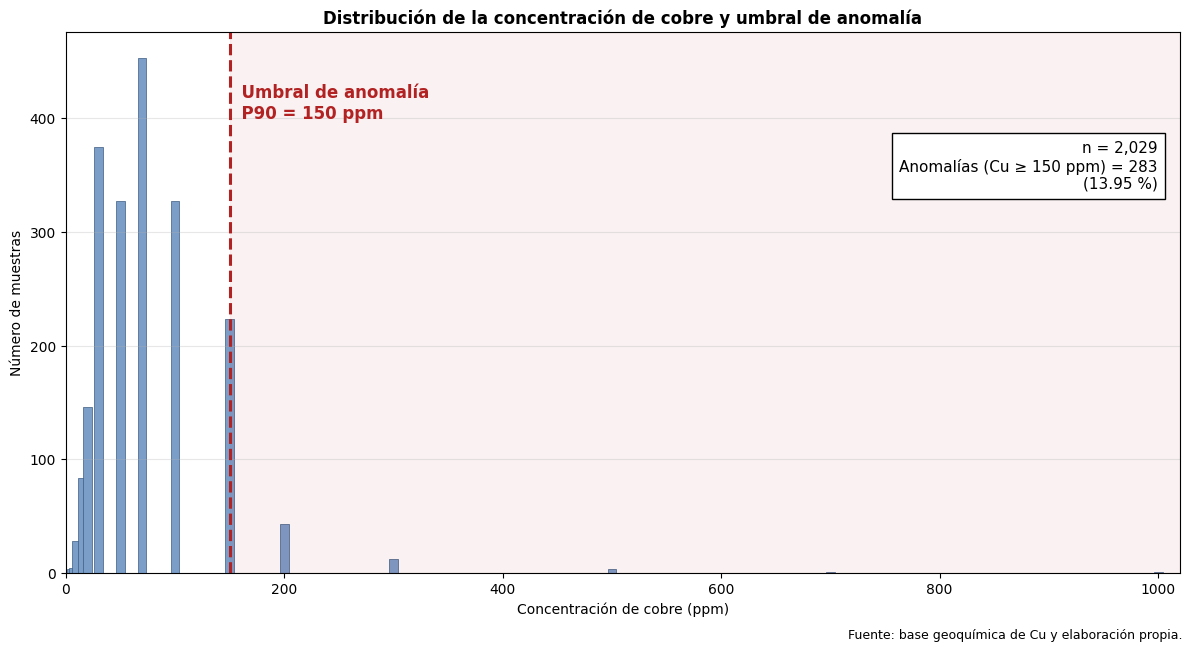

Criterio,Condición,Anomalías resultantes,Porcentaje del total (%)
Percentil 90 estricto,Cu > 150 ppm,60,2.96
Percentil 90 inclusivo (adoptado),Cu >= 150 ppm,283,13.95
Límite de valores atípicos (boxplot),Cu >= 200 ppm,60,2.96


In [31]:
# ==========================================================
# 4.1 DEFINICIÓN DEL UMBRAL DE ANOMALÍA
# TABLA 4.1 (UMBRALES CANDIDATOS) Y FIGURA 4.1
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ----------------------------------------------------------
# 1. Preparar la variable Cu
# ----------------------------------------------------------

if "muestras" not in globals():
    raise NameError(
        "No se encontró la capa de muestras. Ejecuta primero "
        "la preparación de los datos (capítulo 1)."
    )

cu_umbral = pd.to_numeric(
    muestras["Cu"],
    errors="coerce"
).dropna()

numero_muestras_umbral = len(cu_umbral)


# ----------------------------------------------------------
# 2. Calcular el percentil 90
# ----------------------------------------------------------

percentil_90 = float(np.percentile(cu_umbral, 90))

empates_p90 = int((cu_umbral == percentil_90).sum())


# ----------------------------------------------------------
# 3. Evaluar los umbrales candidatos
# ----------------------------------------------------------

candidatos_umbral = [
    (
        "Percentil 90 estricto",
        f"Cu > {percentil_90:,.0f} ppm",
        int((cu_umbral > percentil_90).sum())
    ),
    (
        "Percentil 90 inclusivo (adoptado)",
        f"Cu >= {percentil_90:,.0f} ppm",
        int((cu_umbral >= percentil_90).sum())
    ),
    (
        "Límite de valores atípicos (boxplot)",
        "Cu >= 200 ppm",
        int((cu_umbral >= 200).sum())
    ),
]

tabla_4_1 = pd.DataFrame({
    "Criterio": [c[0] for c in candidatos_umbral],
    "Condición": [c[1] for c in candidatos_umbral],
    "Anomalías resultantes": [c[2] for c in candidatos_umbral],
    "Porcentaje del total (%)": [
        c[2] / numero_muestras_umbral * 100
        for c in candidatos_umbral
    ]
})


# ----------------------------------------------------------
# 4. Definir el umbral oficial del estudio
# ----------------------------------------------------------

umbral_anomalia = percentil_90

print("=" * 68)
print("DEFINICIÓN DEL UMBRAL DE ANOMALÍA")
print("=" * 68)
print(f"Percentil 90               : {percentil_90:,.1f} ppm")
print(f"Muestras empatadas en P90  : {empates_p90}")
print(f"Umbral adoptado            : Cu >= {umbral_anomalia:,.1f} ppm")
print("=" * 68)


# ----------------------------------------------------------
# 5. Mostrar y guardar la Tabla 4.1
# ----------------------------------------------------------

tabla_4_1_estilizada = (
    tabla_4_1.style
    .hide(axis="index")
    .set_caption(
        "Tabla 4.1. Umbrales candidatos para la definición "
        "de las anomalías de cobre."
    )
    .format({
        "Anomalías resultantes": "{:,.0f}",
        "Porcentaje del total (%)": "{:.2f}"
    })
    .set_properties(
        subset=[
            "Condición",
            "Anomalías resultantes",
            "Porcentaje del total (%)"
        ],
        **{"text-align": "center"}
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "13px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "1px solid #555555"),
                ("padding", "7px")
            ]
        },
        {
            "selector": "td",
            "props": [("padding", "6px")]
        }
    ])
)

tabla_4_1.to_csv(
    RESULTADOS / "01_Tablas" / "Tabla_4-1_Umbrales_Candidatos.csv",
    index=False,
    encoding="utf-8-sig"
)


# ----------------------------------------------------------
# 6. Figura 4.1: distribución de Cu y umbral adoptado
# ----------------------------------------------------------

valores_unicos, conteos_unicos = np.unique(
    cu_umbral,
    return_counts=True
)

numero_anomalias_umbral = int(
    (cu_umbral >= umbral_anomalia).sum()
)

figura_umbral, eje_umbral = plt.subplots(figsize=(12, 6.5))

eje_umbral.bar(
    valores_unicos,
    conteos_unicos,
    width=8,
    color="#7B9EC9",
    edgecolor="#3B5A80",
    linewidth=0.5
)

eje_umbral.axvline(
    umbral_anomalia,
    color="#B22222",
    linestyle="--",
    linewidth=2.2
)

eje_umbral.axvspan(
    umbral_anomalia,
    float(cu_umbral.max()) + 20,
    color="#B22222",
    alpha=0.06
)

eje_umbral.text(
    umbral_anomalia,
    conteos_unicos.max() * 0.95,
    (
        "  Umbral de anomalía\n"
        f"  P90 = {umbral_anomalia:,.0f} ppm"
    ),
    color="#B22222",
    fontsize=12,
    fontweight="bold",
    ha="left",
    va="top"
)

eje_umbral.text(
    0.98, 0.80,
    (
        f"n = {numero_muestras_umbral:,}\n"
        f"Anomalías (Cu ≥ {umbral_anomalia:,.0f} ppm) = "
        f"{numero_anomalias_umbral}\n"
        f"({numero_anomalias_umbral / numero_muestras_umbral * 100:.2f} %)"
    ),
    transform=eje_umbral.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        boxstyle="square,pad=0.5"
    )
)

eje_umbral.set_xlim(0, 1020)
eje_umbral.set_xlabel("Concentración de cobre (ppm)")
eje_umbral.set_ylabel("Número de muestras")
eje_umbral.set_title(
    "Distribución de la concentración de cobre y umbral "
    "de anomalía",
    fontweight="bold"
)
eje_umbral.grid(alpha=0.3, axis="y")

figura_umbral.text(
    0.99, 0.01,
    "Fuente: base geoquímica de Cu y elaboración propia.",
    ha="right",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.02, 1, 1])

plt.savefig(
    FIGURAS / "Figura_4-1_Umbral_Anomalia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

tabla_4_1_estilizada

## 4.2 Obtención de las anomalías mediante transformación indicadora

Definido el umbral, se aplica la transformación indicadora I(s) = 1 si Cu(s) ≥ 150 ppm, e I(s) = 0 en caso contrario. El conjunto de sitios con I(s) = 1 constituye el patrón de puntos de anomalías que se analiza en el resto del capítulo, mientras que las muestras con I(s) = 0 conforman el fondo geoquímico de referencia.

In [32]:
# ==========================================================
# 4.2 TRANSFORMACIÓN INDICADORA
# TABLA 4.2 (RESUMEN DE LA TRANSFORMACIÓN)
# ==========================================================

import numpy as np
import pandas as pd
import geopandas as gpd


# ----------------------------------------------------------
# 1. Verificar los insumos de la sección 4.1
# ----------------------------------------------------------

if "umbral_anomalia" not in globals():
    raise NameError(
        "Primero debes ejecutar la definición del umbral (4.1)."
    )


# ----------------------------------------------------------
# 2. Preparar la capa de muestras
# ----------------------------------------------------------

muestras_indicadora = muestras.copy()

muestras_indicadora = muestras_indicadora[
    muestras_indicadora.geometry.notna()
    & ~muestras_indicadora.geometry.is_empty
].copy()

muestras_indicadora["Cu"] = pd.to_numeric(
    muestras_indicadora["Cu"],
    errors="coerce"
)

muestras_indicadora = muestras_indicadora[
    muestras_indicadora["Cu"].notna()
].copy()


# ----------------------------------------------------------
# 3. Aplicar la transformación indicadora
# ----------------------------------------------------------
# El umbral es inclusivo (>=) por la discretización de la
# variable Cu, según lo definido en la sección 4.1.

muestras_indicadora["INDICADOR"] = (
    muestras_indicadora["Cu"] >= umbral_anomalia
).astype(int)


# ----------------------------------------------------------
# 4. Definir el patrón de anomalías y el fondo
# ----------------------------------------------------------

muestras_anomalias = muestras_indicadora[
    muestras_indicadora["INDICADOR"] == 1
].copy()

muestras_fondo = muestras_indicadora[
    muestras_indicadora["INDICADOR"] == 0
].copy()

numero_total = len(muestras_indicadora)
numero_anomalias = len(muestras_anomalias)
numero_fondo = len(muestras_fondo)

porcentaje_anomalias = numero_anomalias / numero_total * 100

if numero_anomalias < 30:
    print(
        "Advertencia: el patrón de anomalías tiene menos de "
        "30 puntos; considera reducir el umbral."
    )


# ----------------------------------------------------------
# 5. Guardar el patrón de anomalías
# ----------------------------------------------------------

muestras_anomalias.to_file(
    ESTUDIO / "Muestras_Cu_Anomalias.gpkg",
    driver="GPKG"
)


# ----------------------------------------------------------
# 6. Construir la Tabla 4.2
# ----------------------------------------------------------

tabla_4_2 = pd.DataFrame({

    "Parámetro": [
        "Umbral aplicado",
        "Muestras evaluadas",
        "Anomalías (I = 1)",
        "Fondo geoquímico (I = 0)",
        "Porcentaje de anomalías",
        "Rango de Cu en las anomalías"
    ],

    "Valor": [
        f"Cu >= {umbral_anomalia:,.0f} ppm",
        f"{numero_total:,}",
        f"{numero_anomalias:,}",
        f"{numero_fondo:,}",
        f"{porcentaje_anomalias:.2f} %",
        (
            f"{muestras_anomalias['Cu'].min():,.0f} – "
            f"{muestras_anomalias['Cu'].max():,.0f} ppm"
        )
    ]
})


# ----------------------------------------------------------
# 7. Mostrar y guardar la Tabla 4.2
# ----------------------------------------------------------

tabla_4_2_estilizada = (
    tabla_4_2.style
    .hide(axis="index")
    .set_caption(
        "Tabla 4.2. Resumen de la transformación indicadora "
        "y del patrón de anomalías resultante."
    )
    .set_properties(
        subset=["Valor"],
        **{"text-align": "center"}
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "13px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "1px solid #555555"),
                ("padding", "7px")
            ]
        },
        {
            "selector": "td",
            "props": [("padding", "6px")]
        }
    ])
)

tabla_4_2.to_csv(
    RESULTADOS / "01_Tablas" / "Tabla_4-2_Transformacion_Indicadora.csv",
    index=False,
    encoding="utf-8-sig"
)

tabla_4_2_estilizada

Parámetro,Valor
Umbral aplicado,Cu >= 150 ppm
Muestras evaluadas,"2,029"
Anomalías (I = 1),283
Fondo geoquímico (I = 0),"1,746"
Porcentaje de anomalías,13.95 %
Rango de Cu en las anomalías,"150 – 1,000 ppm"


## 4.3 Distribución espacial de las anomalías

Se representa la distribución espacial del patrón de anomalías sobre el área de estudio, con símbolos graduados según los valores de concentración reportados. El fondo geoquímico se incluye como referencia para visualizar la relación entre las anomalías y la cobertura general del muestreo.

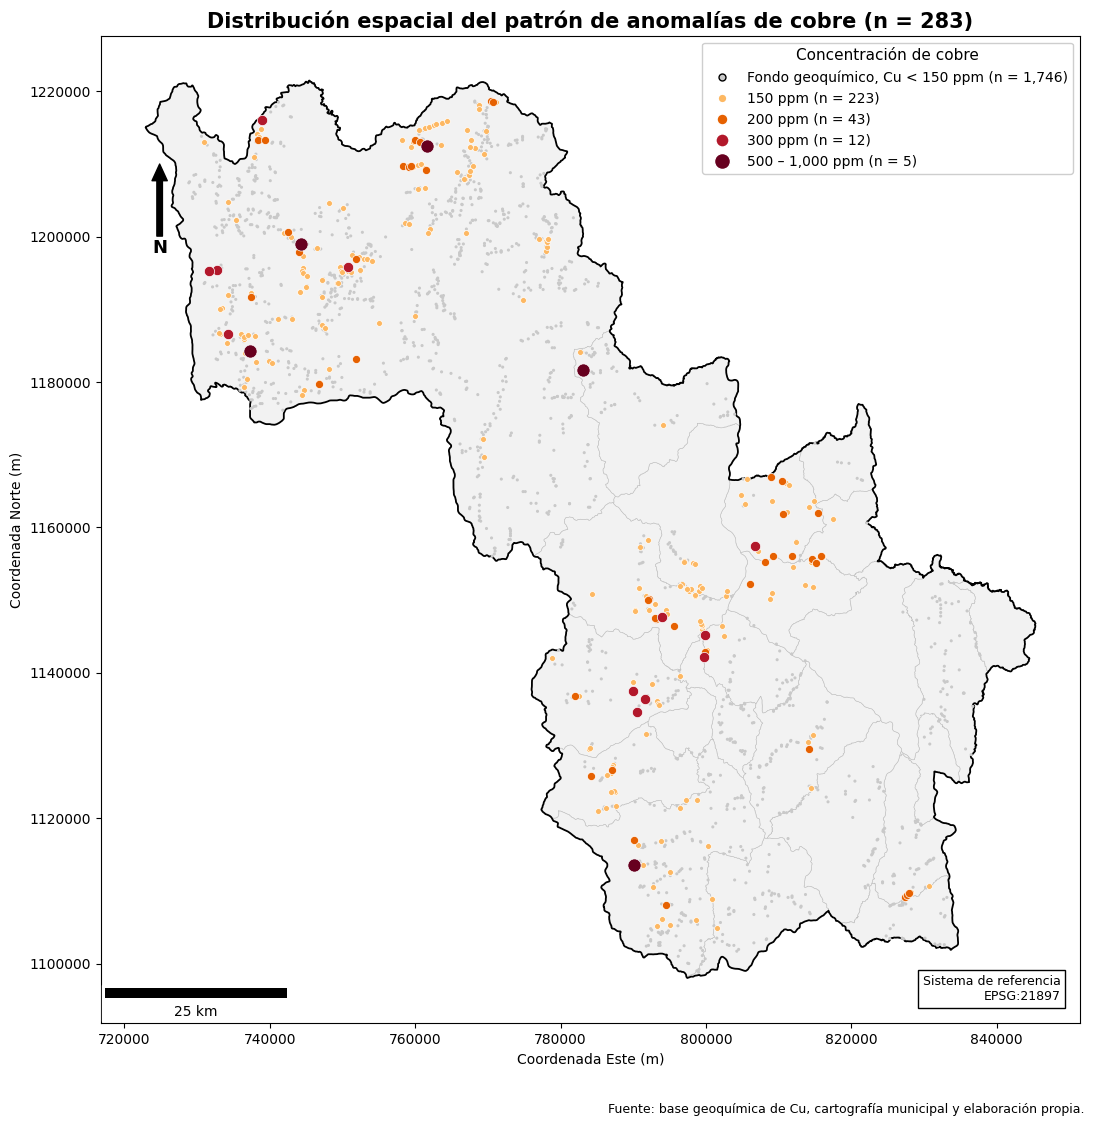

In [44]:
# ==========================================================
# FIGURA 4.3. DISTRIBUCIÓN ESPACIAL DEL PATRÓN DE ANOMALÍAS
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.lines import Line2D


# ----------------------------------------------------------
# 1. Verificar los insumos de la sección 4.2
# ----------------------------------------------------------

if "muestras_anomalias" not in globals():
    raise NameError(
        "Primero debes ejecutar la transformación "
        "indicadora (4.2)."
    )

limite_estudio_anomalias = municipios.dissolve()


# ----------------------------------------------------------
# 2. Definir las clases graduadas
# ----------------------------------------------------------
# Las clases corresponden a los valores reportados de la
# variable discretizada.

clases_anomalias = [
    (150, 150, "150 ppm", "#FDB863", 18),
    (200, 200, "200 ppm", "#E66101", 34),
    (300, 300, "300 ppm", "#B2182B", 55),
    (500, 1000, "500 – 1,000 ppm", "#67001F", 90),
]


# ----------------------------------------------------------
# 3. Construir la figura
# ----------------------------------------------------------

figura_anomalias, eje_anomalias = plt.subplots(
    figsize=(11, 11.5)
)

municipios.plot(
    ax=eje_anomalias,
    facecolor="#F2F2F2",
    edgecolor="#BDBDBD",
    linewidth=0.4
)

limite_estudio_anomalias.boundary.plot(
    ax=eje_anomalias,
    color="black",
    linewidth=1.3
)

# Fondo geoquímico
eje_anomalias.scatter(
    muestras_fondo.geometry.x,
    muestras_fondo.geometry.y,
    s=5,
    color="#C9C9C9",
    edgecolor="none",
    zorder=3
)

elementos_leyenda = [
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="#C9C9C9",
        markersize=5,
        label=(
            f"Fondo geoquímico, Cu < "
            f"{umbral_anomalia:,.0f} ppm "
            f"(n = {len(muestras_fondo):,})"
        )
    )
]

# Anomalías por clase
for valor_min, valor_max, etiqueta, color, tamano in clases_anomalias:

    subconjunto = muestras_anomalias[
        (muestras_anomalias["Cu"] >= valor_min)
        & (muestras_anomalias["Cu"] <= valor_max)
    ]

    eje_anomalias.scatter(
        subconjunto.geometry.x,
        subconjunto.geometry.y,
        s=tamano,
        color=color,
        edgecolor="white",
        linewidth=0.5,
        zorder=5
    )

    elementos_leyenda.append(
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=color,
            markeredgecolor="white",
            markersize=np.sqrt(tamano) + 2,
            label=f"{etiqueta} (n = {len(subconjunto)})"
        )
    )


# ----------------------------------------------------------
# 4. Elementos cartográficos
# ----------------------------------------------------------

eje_anomalias.legend(
    handles=elementos_leyenda,
    title="Concentración de cobre",
    loc="upper right",
    fontsize=10,
    title_fontsize=11,
    framealpha=0.95
)

eje_anomalias.add_artist(
    ScaleBar(1, units="m", location="lower left", box_alpha=0.8)
)

eje_anomalias.annotate(
    "N",
    xy=(0.06, 0.87), xytext=(0.06, 0.78),
    xycoords="axes fraction", textcoords="axes fraction",
    ha="center", fontsize=13, fontweight="bold",
    arrowprops=dict(facecolor="black", width=4, headwidth=11)
)

eje_anomalias.text(
    0.98, 0.02,
    "Sistema de referencia\nEPSG:21897",
    transform=eje_anomalias.transAxes,
    ha="right", va="bottom", fontsize=9,
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        boxstyle="square,pad=0.4"
    )
)

eje_anomalias.set_title(
    (
        "Distribución espacial del patrón de anomalías "
        f"de cobre (n = {len(muestras_anomalias)})"
    ),
    fontsize=15,
    fontweight="bold"
)

eje_anomalias.set_xlabel("Coordenada Este (m)")
eje_anomalias.set_ylabel("Coordenada Norte (m)")
eje_anomalias.ticklabel_format(style="plain")

figura_anomalias.text(
    0.99, 0.005,
    "Fuente: base geoquímica de Cu, cartografía municipal "
    "y elaboración propia.",
    ha="right",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.01, 1, 1])

plt.savefig(
    FIGURAS / "Figura_4-3_Distribucion_Anomalias.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Figura 4.3.** Distribución espacial del patrón de anomalías de cobre sobre el área de estudio, con símbolos graduados según la concentración reportada.

La Figura 4.3 muestra que las anomalías de cobre (n = 283) no se distribuyen de manera uniforme sobre el área de estudio: se reconocen concentraciones de valores anómalos en el sector noroccidental (Urrao) y en la porción central y sur del área, mientras que amplios sectores del muestreo no registran anomalías. Los valores extremos (500 a 1,000 ppm) son escasos (n = 5) y aparecen como ocurrencias puntuales. Esta apreciación visual se evalúa formalmente en las secciones siguientes.

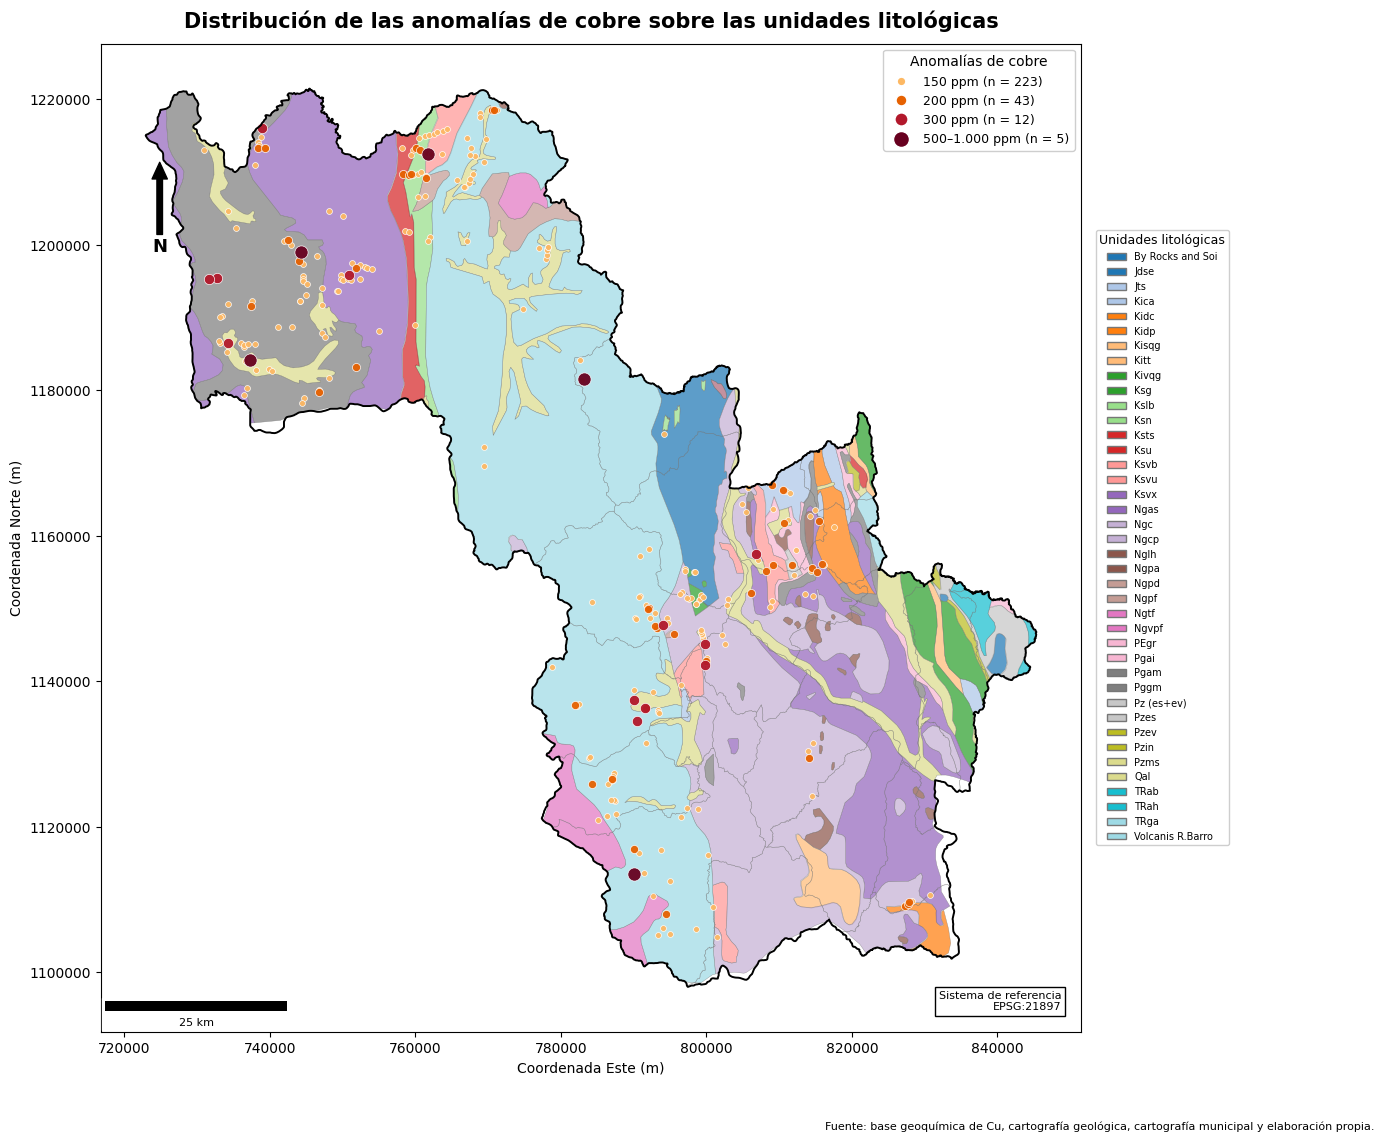

Nombres de fallas añadidos: 21


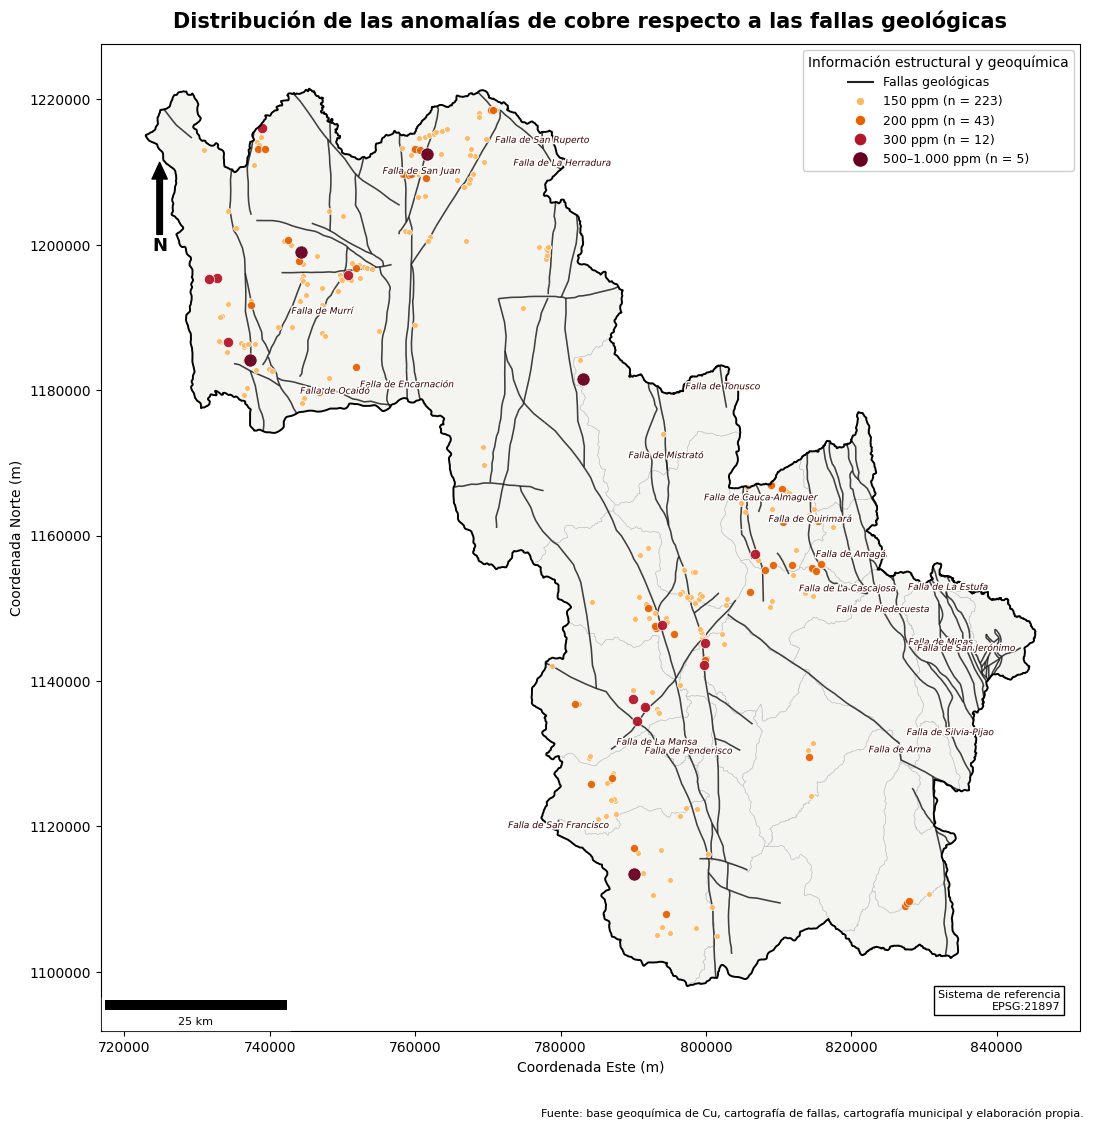

FIGURAS COMPLEMENTARIAS DE LA SECCIÓN 4.3 GENERADAS
Anomalías representadas: 283
Unidades litológicas: 40
Fallas representadas: 129
----------------------------------------------------------------------------
Figura 4.3A: /content/drive/MyDrive/Analisis_Geoespacial_Cobre/03_Figuras/Figura_4-3A_Anomalias_Unidades_Litologicas.png
Figura 4.3B: /content/drive/MyDrive/Analisis_Geoespacial_Cobre/03_Figuras/Figura_4-3B_Anomalias_Fallas_Geologicas.png


In [39]:
# ==========================================================
# FIGURAS 4.3A Y 4.3B
# RELACIÓN ESPACIAL DE LAS ANOMALÍAS DE Cu
# CON LA GEOLOGÍA Y LAS FALLAS
# ==========================================================

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib_scalebar.scalebar import ScaleBar


# ----------------------------------------------------------
# 1. Verificar insumos requeridos
# ----------------------------------------------------------

variables_requeridas = [
    "muestras_anomalias",
    "muestras_fondo",
    "municipios",
    "geologia",
    "fallas",
    "umbral_anomalia",
    "FIGURAS"
]

variables_faltantes = [
    variable
    for variable in variables_requeridas
    if variable not in globals()
]

if variables_faltantes:
    raise NameError(
        "Faltan las siguientes variables o capas: "
        + ", ".join(variables_faltantes)
    )


# ----------------------------------------------------------
# 2. Preparar copias de trabajo
# ----------------------------------------------------------

municipios_43 = municipios.copy()
geologia_43 = geologia.copy()
fallas_43 = fallas.copy()

anomalias_43 = muestras_anomalias.copy()
fondo_43 = muestras_fondo.copy()


# ----------------------------------------------------------
# 3. Limpiar geometrías
# ----------------------------------------------------------

def limpiar_capa(capa):

    capa = capa[
        capa.geometry.notna()
        & ~capa.geometry.is_empty
    ].copy()

    capa["geometry"] = (
        capa.geometry.make_valid()
    )

    return capa


municipios_43 = limpiar_capa(municipios_43)
geologia_43 = limpiar_capa(geologia_43)
fallas_43 = limpiar_capa(fallas_43)
anomalias_43 = limpiar_capa(anomalias_43)
fondo_43 = limpiar_capa(fondo_43)


# ----------------------------------------------------------
# 4. Homologar sistemas de referencia
# ----------------------------------------------------------

crs_43 = municipios_43.crs

if crs_43 is None:
    raise ValueError(
        "La capa de municipios no tiene CRS definido."
    )

if not crs_43.is_projected:
    raise ValueError(
        "Los mapas deben construirse en un CRS proyectado."
    )

capas_reproyectar = {
    "geologia": geologia_43,
    "fallas": fallas_43,
    "anomalias": anomalias_43,
    "fondo": fondo_43
}

for nombre, capa in capas_reproyectar.items():

    if capa.crs is None:
        raise ValueError(
            f"La capa '{nombre}' no tiene CRS definido."
        )

    if capa.crs != crs_43:

        if nombre == "geologia":
            geologia_43 = capa.to_crs(crs_43)

        elif nombre == "fallas":
            fallas_43 = capa.to_crs(crs_43)

        elif nombre == "anomalias":
            anomalias_43 = capa.to_crs(crs_43)

        elif nombre == "fondo":
            fondo_43 = capa.to_crs(crs_43)


# ----------------------------------------------------------
# 5. Crear el límite del área y recortar capas
# ----------------------------------------------------------

poligono_estudio_43 = (
    municipios_43.geometry.union_all()
)

limite_estudio_43 = gpd.GeoDataFrame(
    geometry=[poligono_estudio_43],
    crs=crs_43
)

geologia_43 = gpd.clip(
    geologia_43,
    limite_estudio_43
)

fallas_43 = gpd.clip(
    fallas_43,
    limite_estudio_43
)


# ----------------------------------------------------------
# 6. Clases de anomalías
# ----------------------------------------------------------

clases_anomalias_43 = [
    (150, 150, "150 ppm", "#FDB863", 18),
    (200, 200, "200 ppm", "#E66101", 34),
    (300, 300, "300 ppm", "#B2182B", 55),
    (500, 1000, "500–1.000 ppm", "#67001F", 90)
]


# ----------------------------------------------------------
# 7. Función para añadir anomalías y construir su leyenda
# ----------------------------------------------------------

def dibujar_anomalias(ax, incluir_fondo=True):

    elementos = []

    if incluir_fondo:

        ax.scatter(
            fondo_43.geometry.x,
            fondo_43.geometry.y,
            s=4,
            color="#C9C9C9",
            edgecolor="none",
            alpha=0.65,
            zorder=5
        )

        elementos.append(
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="none",
                markerfacecolor="#C9C9C9",
                markeredgecolor="none",
                markersize=5,
                label=(
                    f"Fondo geoquímico, Cu < "
                    f"{umbral_anomalia:,.0f} ppm "
                    f"(n = {len(fondo_43):,})"
                )
            )
        )

    for valor_min, valor_max, etiqueta, color, tamano in (
        clases_anomalias_43
    ):

        subconjunto = anomalias_43[
            (anomalias_43["Cu"] >= valor_min)
            & (anomalias_43["Cu"] <= valor_max)
        ]

        ax.scatter(
            subconjunto.geometry.x,
            subconjunto.geometry.y,
            s=tamano,
            color=color,
            edgecolor="white",
            linewidth=0.5,
            alpha=0.95,
            zorder=8
        )

        elementos.append(
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="none",
                markerfacecolor=color,
                markeredgecolor="white",
                markersize=np.sqrt(tamano) + 2,
                label=(
                    f"{etiqueta} "
                    f"(n = {len(subconjunto):,})"
                )
            )
        )

    return elementos


# ----------------------------------------------------------
# 8. Función para añadir elementos cartográficos
# ----------------------------------------------------------

def configurar_mapa(
    fig,
    ax,
    titulo,
    fuente
):

    limite_estudio_43.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1.4,
        zorder=10
    )

    ax.add_artist(
        ScaleBar(
            dx=1,
            units="m",
            location="lower left",
            length_fraction=0.20,
            box_alpha=0.90,
            box_color="white",
            color="black",
            font_properties={"size": 8}
        )
    )

    ax.annotate(
        "N",
        xy=(0.06, 0.88),
        xytext=(0.06, 0.79),
        xycoords="axes fraction",
        textcoords="axes fraction",
        ha="center",
        fontsize=13,
        fontweight="bold",
        arrowprops=dict(
            facecolor="black",
            edgecolor="black",
            width=4,
            headwidth=11
        ),
        zorder=15
    )

    ax.text(
        0.98,
        0.02,
        "Sistema de referencia\nEPSG:21897",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="square,pad=0.35"
        ),
        zorder=15
    )

    ax.set_title(
        titulo,
        fontsize=15,
        fontweight="bold",
        pad=12
    )

    ax.set_xlabel(
        "Coordenada Este (m)"
    )

    ax.set_ylabel(
        "Coordenada Norte (m)"
    )

    ax.ticklabel_format(
        style="plain",
        axis="both"
    )

    ax.set_aspect("equal")
    ax.grid(False)

    fig.text(
        0.99,
        0.005,
        fuente,
        ha="right",
        fontsize=8
    )


# ==========================================================
# FIGURA 4.3A. ANOMALÍAS Y UNIDADES LITOLÓGICAS
# ==========================================================

# ----------------------------------------------------------
# 9. Identificar la columna de unidades geológicas
# ----------------------------------------------------------

columnas_geologia = [
    "ENTITY",
    "UNIDAD_DES",
    "DESCRIPTIO",
    "DESCRIPCIO"
]

columna_geologia_43 = next(
    (
        columna
        for columna in columnas_geologia
        if columna in geologia_43.columns
    ),
    None
)

if columna_geologia_43 is None:
    raise ValueError(
        "No se encontró una columna para identificar "
        "las unidades geológicas.\n"
        f"Columnas disponibles: {geologia_43.columns.tolist()}"
    )


# ----------------------------------------------------------
# 10. Preparar categorías litológicas
# ----------------------------------------------------------

geologia_43["UNIDAD_MAPA"] = (
    geologia_43[columna_geologia_43]
    .fillna("Sin identificación")
    .astype(str)
    .str.strip()
)

unidades_43 = sorted(
    geologia_43["UNIDAD_MAPA"]
    .unique()
    .tolist()
)

mapa_colores = plt.get_cmap(
    "tab20",
    max(len(unidades_43), 1)
)

colores_unidades_43 = {
    unidad: mapa_colores(indice)
    for indice, unidad in enumerate(unidades_43)
}


# ----------------------------------------------------------
# 11. Crear el mapa litológico
# ----------------------------------------------------------

figura_43a, eje_43a = plt.subplots(
    figsize=(14, 11.5)
)

for unidad in unidades_43:

    geologia_43[
        geologia_43["UNIDAD_MAPA"] == unidad
    ].plot(
        ax=eje_43a,
        facecolor=colores_unidades_43[unidad],
        edgecolor="#777777",
        linewidth=0.30,
        alpha=0.72,
        zorder=1
    )

municipios_43.boundary.plot(
    ax=eje_43a,
    color="#777777",
    linewidth=0.35,
    alpha=0.55,
    zorder=3
)

elementos_anomalias_43a = dibujar_anomalias(
    eje_43a,
    incluir_fondo=False
)


# ----------------------------------------------------------
# 12. Leyendas de la Figura 4.3A
# ----------------------------------------------------------

elementos_geologia_43a = [
    Patch(
        facecolor=colores_unidades_43[unidad],
        edgecolor="#777777",
        label=unidad
    )
    for unidad in unidades_43
]

leyenda_geologia_43a = eje_43a.legend(
    handles=elementos_geologia_43a,
    title="Unidades litológicas",
    loc="center left",
    bbox_to_anchor=(1.01, 0.50),
    fontsize=7,
    title_fontsize=9,
    framealpha=0.96
)

eje_43a.add_artist(
    leyenda_geologia_43a
)

eje_43a.legend(
    handles=elementos_anomalias_43a,
    title="Anomalías de cobre",
    loc="upper right",
    fontsize=9,
    title_fontsize=10,
    framealpha=0.96
)


# ----------------------------------------------------------
# 13. Configurar y guardar la Figura 4.3A
# ----------------------------------------------------------

configurar_mapa(
    figura_43a,
    eje_43a,
    (
        "Distribución de las anomalías de cobre "
        "sobre las unidades litológicas"
    ),
    (
        "Fuente: base geoquímica de Cu, cartografía geológica, "
        "cartografía municipal y elaboración propia."
    )
)

figura_43a.subplots_adjust(
    left=0.08,
    right=0.78,
    bottom=0.08,
    top=0.96
)

ruta_figura_43a = (
    FIGURAS
    / "Figura_4-3A_Anomalias_Unidades_Litologicas.png"
)

figura_43a.savefig(
    ruta_figura_43a,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


# ==========================================================
# FIGURA 4.3B. ANOMALÍAS Y FALLAS GEOLÓGICAS
# ==========================================================

# ----------------------------------------------------------
# 14. Crear el mapa estructural
# ----------------------------------------------------------

figura_43b, eje_43b = plt.subplots(
    figsize=(11, 11.5)
)

municipios_43.plot(
    ax=eje_43b,
    facecolor="#F4F4F1",
    edgecolor="#BDBDBD",
    linewidth=0.40,
    zorder=1
)

fallas_43.plot(
    ax=eje_43b,
    color="#202020",
    linewidth=1.15,
    alpha=0.85,
    zorder=4
)

elementos_anomalias_43b = dibujar_anomalias(
    eje_43b,
    incluir_fondo=False
)

# ----------------------------------------------------------
# 14.1 Añadir nombres de las fallas principales
# ----------------------------------------------------------

import matplotlib.patheffects as pe


# Posibles columnas donde puede estar el nombre de la falla
columnas_nombre_falla = [
    "NombreFall",
    "NOMBRE_FAL",
    "NOMBRE",
    "Nombre",
    "FALLA",
    "NOM_FALLA",
    "NAME"
]

columna_nombre_falla = next(
    (
        columna
        for columna in columnas_nombre_falla
        if columna in fallas_43.columns
    ),
    None
)

if columna_nombre_falla is None:

    print(
        "No se encontró automáticamente una columna "
        "con el nombre de las fallas."
    )

    print(
        "Columnas disponibles:",
        fallas_43.columns.tolist()
    )

else:

    # Limpiar nombres
    fallas_43["NOMBRE_FALLA_MAPA"] = (
        fallas_43[columna_nombre_falla]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    # Excluir registros sin nombre útil
    nombres_no_validos = [
        "",
        "NONE",
        "NAN",
        "SIN NOMBRE",
        "NO IDENTIFICADA",
        "NO DEFINIDA"
    ]

    fallas_principales_43 = fallas_43[
        ~fallas_43["NOMBRE_FALLA_MAPA"]
        .str.upper()
        .isin(nombres_no_validos)
    ].copy()

    # Evitar repetir muchas veces el mismo nombre
    fallas_principales_43 = (
        fallas_principales_43
        .sort_values(
            by="NOMBRE_FALLA_MAPA"
        )
        .drop_duplicates(
            subset="NOMBRE_FALLA_MAPA"
        )
    )

    # Añadir etiquetas
    for _, fila in fallas_principales_43.iterrows():

        geometria = fila.geometry
        nombre_falla = fila["NOMBRE_FALLA_MAPA"]

        if geometria is None or geometria.is_empty:
            continue

        # Punto ubicado aproximadamente a la mitad de la línea
        punto_etiqueta = geometria.interpolate(
            0.5,
            normalized=True
        )

        texto_falla = eje_43b.text(
            punto_etiqueta.x,
            punto_etiqueta.y,
            nombre_falla,
            fontsize=6.5,
            color="#3A0000",
            fontstyle="italic",
            ha="center",
            va="center",
            rotation=0,
            zorder=12
        )

        # Contorno blanco para facilitar la lectura
        texto_falla.set_path_effects([
            pe.withStroke(
                linewidth=2.2,
                foreground="white"
            )
        ])

    print(
        f"Nombres de fallas añadidos: "
        f"{len(fallas_principales_43)}"
    )
# ----------------------------------------------------------
# 15. Crear leyenda de la Figura 4.3B
# ----------------------------------------------------------

elementos_estructura_43b = [
    Line2D(
        [0],
        [0],
        color="#202020",
        linewidth=1.5,
        label="Fallas geológicas"
    )
]

elementos_leyenda_43b = (
    elementos_estructura_43b
    + elementos_anomalias_43b
)

eje_43b.legend(
    handles=elementos_leyenda_43b,
    title="Información estructural y geoquímica",
    loc="upper right",
    fontsize=9,
    title_fontsize=10,
    framealpha=0.96
)


# ----------------------------------------------------------
# 16. Configurar y guardar la Figura 4.3B
# ----------------------------------------------------------

configurar_mapa(
    figura_43b,
    eje_43b,
    (
        "Distribución de las anomalías de cobre "
        "respecto a las fallas geológicas"
    ),
    (
        "Fuente: base geoquímica de Cu, cartografía de fallas, "
        "cartografía municipal y elaboración propia."
    )
)

plt.tight_layout(
    rect=[0, 0.01, 1, 1]
)

ruta_figura_43b = (
    FIGURAS
    / "Figura_4-3B_Anomalias_Fallas_Geologicas.png"
)

figura_43b.savefig(
    ruta_figura_43b,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


# ----------------------------------------------------------
# 17. Confirmar resultados
# ----------------------------------------------------------

print("=" * 76)
print("FIGURAS COMPLEMENTARIAS DE LA SECCIÓN 4.3 GENERADAS")
print("=" * 76)

print(
    f"Anomalías representadas: "
    f"{len(anomalias_43):,}"
)

print(
    f"Unidades litológicas: "
    f"{len(unidades_43):,}"
)

print(
    f"Fallas representadas: "
    f"{len(fallas_43):,}"
)

print("-" * 76)
print(f"Figura 4.3A: {ruta_figura_43a}")
print(f"Figura 4.3B: {ruta_figura_43b}")
print("=" * 76)

## 4.4 Caracterización del patrón de anomalías mediante densidad Kernel

Se estima la densidad Kernel del patrón de anomalías con el mismo procedimiento aplicado al patrón de muestreo (kernel gaussiano y regla de Scott), lo que permite identificar los sectores del área de estudio donde se concentran los valores anómalos de cobre y compararlos con la intensidad general del muestreo obtenida en la sección 3.4.

In [53]:
# ==========================================================
# TABLA 11. PARÁMETROS DE LA ESTIMACIÓN KERNEL
# DEL PATRÓN DE ANOMALÍAS
# ==========================================================

import numpy as np
import pandas as pd

from scipy.stats import gaussian_kde


# ----------------------------------------------------------
# 1. Verificar los insumos de la sección 4.2
# ----------------------------------------------------------

if "muestras_anomalias" not in globals():
    raise NameError(
        "Primero debes ejecutar la transformación "
        "indicadora (4.2)."
    )


# ----------------------------------------------------------
# 2. Preparar la capa de anomalías
# ----------------------------------------------------------

anomalias_kernel = muestras_anomalias.copy()

anomalias_kernel = anomalias_kernel[
    anomalias_kernel.geometry.notna()
    & ~anomalias_kernel.geometry.is_empty
].copy()

municipios_kernel_an = municipios.copy()

poligono_kernel_an = (
    municipios_kernel_an.geometry.union_all()
)


# ----------------------------------------------------------
# 3. Extraer coordenadas válidas
# ----------------------------------------------------------

x_kernel_an = anomalias_kernel.geometry.x.to_numpy()
y_kernel_an = anomalias_kernel.geometry.y.to_numpy()

mascara_kernel_an = (
    np.isfinite(x_kernel_an)
    & np.isfinite(y_kernel_an)
)

x_kernel_an = x_kernel_an[mascara_kernel_an]
y_kernel_an = y_kernel_an[mascara_kernel_an]

numero_anomalias_kernel = len(x_kernel_an)

if numero_anomalias_kernel < 3:
    raise ValueError(
        "Se requieren al menos tres anomalías válidas "
        "para calcular la densidad Kernel."
    )

coordenadas_kernel_an = np.vstack([
    x_kernel_an,
    y_kernel_an
])


# ----------------------------------------------------------
# 4. Ajustar el modelo Kernel
# ----------------------------------------------------------
# Kernel gaussiano y regla de Scott, en consistencia con
# la sección 3.4.

modelo_kernel_an = gaussian_kde(
    coordenadas_kernel_an,
    bw_method="scott"
)

factor_banda_an = float(modelo_kernel_an.factor)

banda_este_an = factor_banda_an * np.std(x_kernel_an, ddof=1)
banda_norte_an = factor_banda_an * np.std(y_kernel_an, ddof=1)

banda_promedio_an = np.sqrt(banda_este_an * banda_norte_an)


# ----------------------------------------------------------
# 5. Definir la resolución de la malla
# ----------------------------------------------------------

RESOLUCION_KERNEL_AN = 300

xmin_an, ymin_an, xmax_an, ymax_an = (
    municipios_kernel_an.total_bounds
)

tamano_celda_an = (
    ((xmax_an - xmin_an) / (RESOLUCION_KERNEL_AN - 1))
    + ((ymax_an - ymin_an) / (RESOLUCION_KERNEL_AN - 1))
) / 2


# ----------------------------------------------------------
# 6. Construir la Tabla 11
# ----------------------------------------------------------

tabla_11 = pd.DataFrame({

    "Parámetro": [
        "Número de anomalías",
        "Tipo de kernel",
        "Método del ancho de banda",
        "Factor de Scott",
        "Ancho de banda Este",
        "Ancho de banda Norte",
        "Ancho de banda promedio",
        "Resolución de la malla",
        "Tamaño de celda promedio"
    ],

    "Valor": [
        f"{numero_anomalias_kernel:,}",
        "Gaussiano",
        "Regla de Scott",
        f"{factor_banda_an:.4f}",
        f"{banda_este_an:,.0f} m",
        f"{banda_norte_an:,.0f} m",
        f"{banda_promedio_an:,.0f} m",
        f"{RESOLUCION_KERNEL_AN} x {RESOLUCION_KERNEL_AN}",
        f"{tamano_celda_an:,.0f} m"
    ]
})


# ----------------------------------------------------------
# 7. Mostrar y guardar la Tabla 11
# ----------------------------------------------------------

tabla_11_estilizada = (
    tabla_11.style
    .hide(axis="index")
    .set_caption(
        "Tabla 11. Parámetros de la estimación Kernel del "
        "patrón de anomalías de cobre."
    )
    .set_properties(
        subset=["Valor"],
        **{"text-align": "center"}
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "13px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "1px solid #555555"),
                ("padding", "7px")
            ]
        },
        {
            "selector": "td",
            "props": [("padding", "6px")]
        }
    ])
)

tabla_11.to_csv(
    RESULTADOS / "01_Tablas" / "Tabla_11_Parametros_Kernel_Anomalias.csv",
    index=False,
    encoding="utf-8-sig"
)

tabla_11_estilizada

Parámetro,Valor
Número de anomalías,283
Tipo de kernel,Gaussiano
Método del ancho de banda,Regla de Scott
Factor de Scott,0.3903
Ancho de banda Este,"10,141 m"
Ancho de banda Norte,"12,936 m"
Ancho de banda promedio,"11,453 m"
Resolución de la malla,300 x 300
Tamaño de celda promedio,411 m


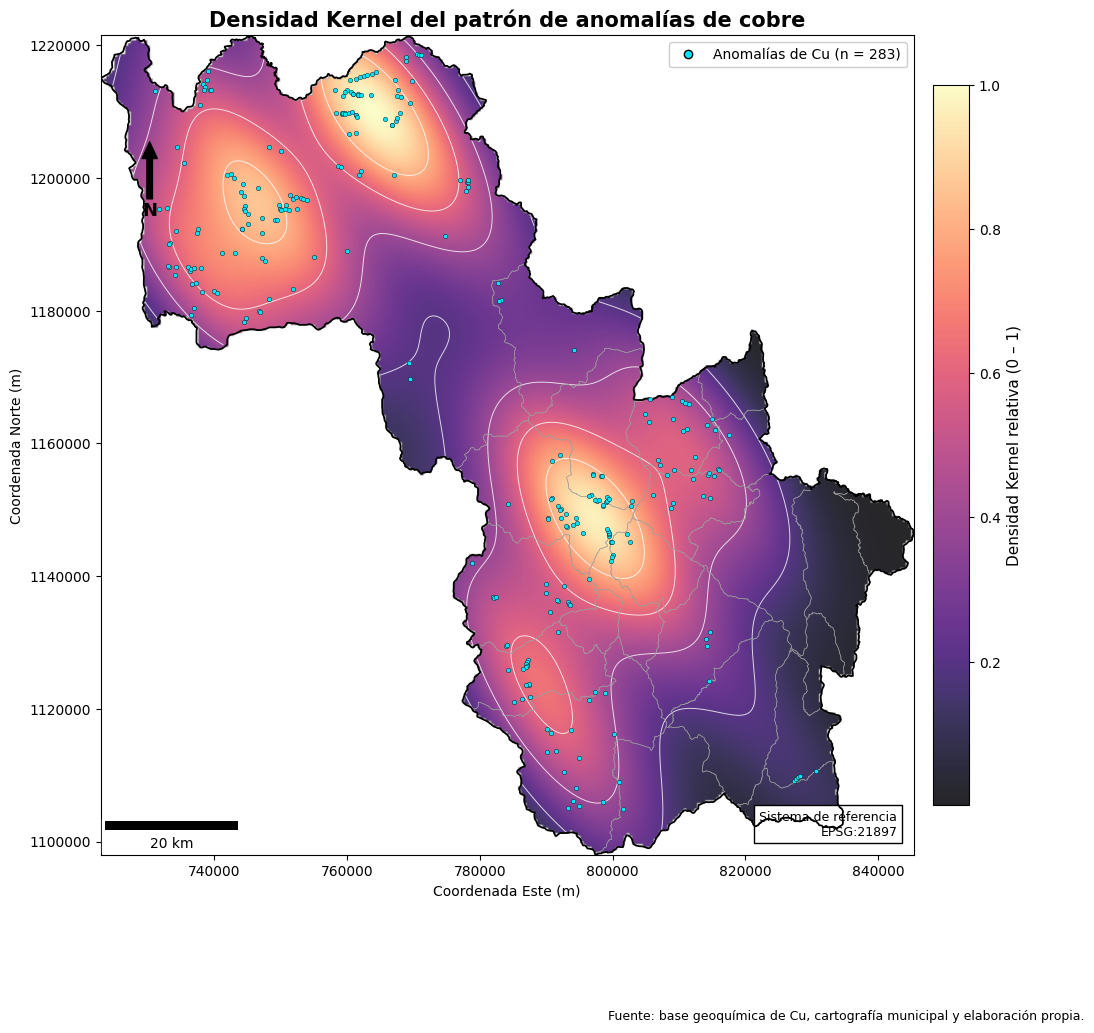

In [54]:
# ==========================================================
# FIGURA 12. DENSIDAD KERNEL DEL PATRÓN DE ANOMALÍAS
# ==========================================================

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib_scalebar.scalebar import ScaleBar


# ----------------------------------------------------------
# 1. Verificar los insumos de la Tabla 11
# ----------------------------------------------------------

variables_requeridas = [
    "modelo_kernel_an", "x_kernel_an", "y_kernel_an",
    "poligono_kernel_an", "municipios_kernel_an",
    "RESOLUCION_KERNEL_AN"
]

variables_faltantes = [
    v for v in variables_requeridas if v not in globals()
]

if variables_faltantes:
    raise NameError(
        "Primero debes ejecutar la celda de la Tabla 11. "
        f"Variables faltantes: {variables_faltantes}"
    )


# ----------------------------------------------------------
# 2. Crear la malla de evaluación
# ----------------------------------------------------------

xmin_an, ymin_an, xmax_an, ymax_an = (
    municipios_kernel_an.total_bounds
)

x_malla_an = np.linspace(xmin_an, xmax_an, RESOLUCION_KERNEL_AN)
y_malla_an = np.linspace(ymin_an, ymax_an, RESOLUCION_KERNEL_AN)

xx_an, yy_an = np.meshgrid(x_malla_an, y_malla_an)

posiciones_an = np.vstack([xx_an.ravel(), yy_an.ravel()])


# ----------------------------------------------------------
# 3. Evaluar y recortar la densidad
# ----------------------------------------------------------

densidad_an = modelo_kernel_an(posiciones_an).reshape(
    xx_an.shape
)

try:

    from shapely import intersects_xy

    mascara_poligono_an = intersects_xy(
        poligono_kernel_an, xx_an, yy_an
    )

except ImportError:

    puntos_malla_an = gpd.GeoSeries(
        gpd.points_from_xy(xx_an.ravel(), yy_an.ravel()),
        crs=municipios_kernel_an.crs
    )

    mascara_poligono_an = (
        puntos_malla_an.within(poligono_kernel_an)
        | puntos_malla_an.touches(poligono_kernel_an)
    ).to_numpy().reshape(xx_an.shape)

densidad_an_recortada = np.where(
    mascara_poligono_an, densidad_an, np.nan
)


# ----------------------------------------------------------
# 4. Normalizar entre 0 y 1
# ----------------------------------------------------------
# La normalización facilita la comparación visual y no
# representa concentraciones de cobre.

densidad_an_maxima = np.nanmax(densidad_an_recortada)

if not np.isfinite(densidad_an_maxima) or densidad_an_maxima <= 0:
    raise ValueError(
        "No fue posible obtener una densidad Kernel válida."
    )

densidad_an_relativa = (
    densidad_an_recortada / densidad_an_maxima
)


# ----------------------------------------------------------
# 5. Construir la figura
# ----------------------------------------------------------

figura_kernel_an, eje_kernel_an = plt.subplots(
    figsize=(11, 11.5)
)

superficie = eje_kernel_an.imshow(
    densidad_an_relativa,
    extent=[xmin_an, xmax_an, ymin_an, ymax_an],
    origin="lower",
    cmap="magma",
    alpha=0.85,
    zorder=2
)

contornos = eje_kernel_an.contour(
    xx_an, yy_an, densidad_an_relativa,
    levels=[0.2, 0.4, 0.6, 0.8],
    colors="white",
    linewidths=0.7,
    alpha=0.8,
    zorder=3
)

municipios_kernel_an.boundary.plot(
    ax=eje_kernel_an,
    color="#9E9E9E",
    linewidth=0.4,
    zorder=4
)

municipios_kernel_an.dissolve().boundary.plot(
    ax=eje_kernel_an,
    color="black",
    linewidth=1.3,
    zorder=5
)

eje_kernel_an.scatter(
    x_kernel_an, y_kernel_an,
    s=10,
    color="#00E5FF",
    edgecolor="black",
    linewidth=0.3,
    zorder=6
)


# ----------------------------------------------------------
# 6. Elementos cartográficos
# ----------------------------------------------------------

barra_color = plt.colorbar(
    superficie,
    ax=eje_kernel_an,
    shrink=0.65,
    pad=0.02
)

barra_color.set_label(
    "Densidad Kernel relativa (0 – 1)",
    fontsize=11
)

eje_kernel_an.legend(
    handles=[
        Line2D(
            [0], [0],
            marker="o", color="none",
            markerfacecolor="#00E5FF",
            markeredgecolor="black",
            markersize=6,
            label=(
                "Anomalías de Cu "
                f"(n = {len(x_kernel_an)})"
            )
        )
    ],
    loc="upper right",
    fontsize=10,
    framealpha=0.95
)

eje_kernel_an.add_artist(
    ScaleBar(1, units="m", location="lower left", box_alpha=0.8)
)

eje_kernel_an.annotate(
    "N",
    xy=(0.06, 0.87), xytext=(0.06, 0.78),
    xycoords="axes fraction", textcoords="axes fraction",
    ha="center", fontsize=13, fontweight="bold",
    arrowprops=dict(facecolor="black", width=4, headwidth=11)
)

eje_kernel_an.text(
    0.98, 0.02,
    "Sistema de referencia\nEPSG:21897",
    transform=eje_kernel_an.transAxes,
    ha="right", va="bottom", fontsize=9,
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        boxstyle="square,pad=0.4"
    )
)

eje_kernel_an.set_title(
    "Densidad Kernel del patrón de anomalías de cobre",
    fontsize=15, fontweight="bold"
)
eje_kernel_an.set_xlabel("Coordenada Este (m)")
eje_kernel_an.set_ylabel("Coordenada Norte (m)")
eje_kernel_an.ticklabel_format(style="plain")

figura_kernel_an.text(
    0.99, 0.005,
    "Fuente: base geoquímica de Cu, cartografía municipal "
    "y elaboración propia.",
    ha="right", fontsize=9
)

plt.tight_layout(rect=[0, 0.01, 1, 1])

plt.savefig(
    FIGURAS / "Figura_12_Densidad_Kernel_Anomalias.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Figura 12.** Densidad Kernel del patrón de anomalías de cobre (kernel gaussiano, regla de Scott, ancho de banda promedio ≈ 11.5 km).

La superficie de densidad revela los sectores de mayor concentración de anomalías. En contraste con la densidad Kernel del muestreo (Figura 09), que refleja el esfuerzo de la campaña, los máximos de esta superficie corresponden a sectores donde los valores anómalos se agrupan más allá de la intensidad del muestreo, lo que constituye una primera evidencia visual de agrupamiento del fenómeno geoquímico. Cabe anotar que el ancho de banda de Scott, al calcularse sobre solo 283 puntos, es mayor que el del patrón de muestreo, por lo que la superficie resultante es más suave.

## 4.5 Evaluación del patrón de anomalías mediante el análisis del vecino más cercano

Se aplica al patrón de anomalías el mismo análisis del vecino más cercano de la sección 3.5: se compara la distancia media observada entre cada anomalía y su vecina más próxima con la distancia esperada bajo aleatoriedad espacial completa, y se calcula el índice R de Clark y Evans con su prueba de significancia.

In [55]:
# ==========================================================
# TABLA 12. ANÁLISIS DEL VECINO MÁS CERCANO
# DEL PATRÓN DE ANOMALÍAS
# ==========================================================

import numpy as np
import pandas as pd

from sklearn.neighbors import NearestNeighbors
from scipy.stats import norm


# ----------------------------------------------------------
# 1. Verificar los insumos de la sección 4.2
# ----------------------------------------------------------

if "muestras_anomalias" not in globals():
    raise NameError(
        "Primero debes ejecutar la transformación "
        "indicadora (4.2)."
    )


# ----------------------------------------------------------
# 2. Preparar la capa y extraer coordenadas
# ----------------------------------------------------------

anomalias_ann = muestras_anomalias.copy()

anomalias_ann = anomalias_ann[
    anomalias_ann.geometry.notna()
    & ~anomalias_ann.geometry.is_empty
].copy()

poligono_ann_an = municipios.geometry.union_all()

coordenadas_ann_an = np.column_stack([
    anomalias_ann.geometry.x.to_numpy(),
    anomalias_ann.geometry.y.to_numpy()
])

mascara_ann_an = np.isfinite(
    coordenadas_ann_an
).all(axis=1)

coordenadas_ann_an = coordenadas_ann_an[mascara_ann_an]

numero_anomalias_ann = len(coordenadas_ann_an)

if numero_anomalias_ann < 2:
    raise ValueError(
        "Se requieren al menos dos anomalías válidas."
    )


# ----------------------------------------------------------
# 3. Calcular la distancia al vecino más cercano
# ----------------------------------------------------------
# Se solicitan dos vecinos porque el primero corresponde
# al mismo punto, cuya distancia es igual a cero.

modelo_vecinos_an = NearestNeighbors(
    n_neighbors=2,
    metric="euclidean"
)

modelo_vecinos_an.fit(coordenadas_ann_an)

distancias_an, _ = modelo_vecinos_an.kneighbors(
    coordenadas_ann_an
)

distancia_observada_an = float(
    np.mean(distancias_an[:, 1])
)


# ----------------------------------------------------------
# 4. Calcular la distancia esperada bajo CSR
# ----------------------------------------------------------

area_m2_an = float(poligono_ann_an.area)

densidad_m2_an = numero_anomalias_ann / area_m2_an

distancia_esperada_an = 0.5 / np.sqrt(densidad_m2_an)


# ----------------------------------------------------------
# 5. Índice R de Clark y Evans y significancia
# ----------------------------------------------------------

indice_r_an = (
    distancia_observada_an / distancia_esperada_an
)

error_estandar_an = (
    0.26136
    / np.sqrt(numero_anomalias_ann * densidad_m2_an)
)

z_an = (
    (distancia_observada_an - distancia_esperada_an)
    / error_estandar_an
)

p_valor_an = 2 * (1 - norm.cdf(abs(z_an)))

if indice_r_an < 1 and p_valor_an < 0.05:
    interpretacion_ann_an = (
        "Patrón significativamente agrupado (R < 1)"
    )
elif indice_r_an > 1 and p_valor_an < 0.05:
    interpretacion_ann_an = (
        "Patrón significativamente regular (R > 1)"
    )
else:
    interpretacion_ann_an = (
        "Patrón compatible con la aleatoriedad espacial"
    )


# ----------------------------------------------------------
# 6. Construir la Tabla 12
# ----------------------------------------------------------

tabla_12 = pd.DataFrame({

    "Parámetro": [
        "Número de anomalías",
        "Área de análisis",
        "Densidad de anomalías",
        "Distancia media observada",
        "Distancia media esperada (CSR)",
        "Índice R de Clark y Evans",
        "Estadístico Z",
        "Valor p",
        "Interpretación (α = 0.05)"
    ],

    "Valor": [
        f"{numero_anomalias_ann:,}",
        f"{area_m2_an / 1e6:,.1f} km²",
        f"{densidad_m2_an * 1e6:.4f} anomalías/km²",
        f"{distancia_observada_an:,.2f} m",
        f"{distancia_esperada_an:,.2f} m",
        f"{indice_r_an:.4f}",
        f"{z_an:.2f}",
        f"{p_valor_an:.3g}",
        interpretacion_ann_an
    ]
})


# ----------------------------------------------------------
# 7. Mostrar y guardar la Tabla 12
# ----------------------------------------------------------

tabla_12_estilizada = (
    tabla_12.style
    .hide(axis="index")
    .set_caption(
        "Tabla 12. Análisis del vecino más cercano del "
        "patrón de anomalías de cobre."
    )
    .set_properties(
        subset=["Valor"],
        **{"text-align": "center"}
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "13px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "1px solid #555555"),
                ("padding", "7px")
            ]
        },
        {
            "selector": "td",
            "props": [("padding", "6px")]
        }
    ])
)

tabla_12.to_csv(
    RESULTADOS / "01_Tablas" / "Tabla_12_Vecino_Cercano_Anomalias.csv",
    index=False,
    encoding="utf-8-sig"
)

tabla_12_estilizada

Parámetro,Valor
Número de anomalías,283
Área de análisis,"6,366.1 km²"
Densidad de anomalías,0.0445 anomalías/km²
Distancia media observada,"1,067.73 m"
Distancia media esperada (CSR),"2,371.44 m"
Índice R de Clark y Evans,0.4502
Estadístico Z,-17.69
Valor p,0
Interpretación (α = 0.05),Patrón significativamente agrupado (R < 1)


La distancia media observada entre anomalías fue de 1,067.73 m, frente a una distancia esperada bajo aleatoriedad espacial completa de 2,371.44 m, lo que arroja un índice R de Clark y Evans de 0.45 (Z = −17.69; p < 0.001). El patrón de anomalías es, por lo tanto, significativamente agrupado: las anomalías se ubican, en promedio, a menos de la mitad de la distancia que las separaría bajo el azar. Este resultado contrasta con el del patrón de muestreo (sección 3.5) y debe interpretarse con la salvedad de que el estadístico de Clark y Evans no incorpora corrección por efectos de borde; dicha limitación se aborda en las secciones siguientes mediante pruebas basadas en simulación condicionadas al polígono del área.

## 4.6 Evaluación de la aleatoriedad mediante conteo por cuadrantes: prueba de Monte Carlo

El conteo por cuadrantes divide el área que contiene el patrón en celdas regulares y evalúa, mediante el estadístico chi-cuadrado, si los conteos por celda son compatibles con una distribución uniforme. Dado que la malla se construye sobre el rectángulo envolvente del área de estudio, cuya forma irregular genera celdas parcialmente externas al polígono, la prueba chi-cuadrado analítica rechazaría la uniformidad incluso para patrones aleatorios. Por esta razón, la significancia se evalúa mediante una prueba de Monte Carlo condicionada a la forma del área: el estadístico observado se compara con la distribución del chi-cuadrado en patrones de Poisson homogéneos simulados dentro del polígono, cada uno con el mismo número de puntos que el patrón de anomalías.

In [56]:
# ==========================================================
# TABLA 13. CONTEO POR CUADRANTES DEL PATRÓN DE ANOMALÍAS
# (PRUEBA DE MONTE CARLO CONDICIONADA AL ÁREA DE ESTUDIO)
# ==========================================================

import numpy as np
import pandas as pd

from pointpats import random as pp_random


# ----------------------------------------------------------
# 1. Parámetros del análisis
# ----------------------------------------------------------
# Nota: con 999 simulaciones la celda tarda entre
# 1 y 3 minutos.

NX_CUADRANTES = 4
NY_CUADRANTES = 4
N_SIMULACIONES_CUADRANTES = 999
SEMILLA_CUADRANTES = 42


# ----------------------------------------------------------
# 2. Verificar los insumos
# ----------------------------------------------------------

if "muestras_anomalias" not in globals():
    raise NameError(
        "Primero debes ejecutar la transformación "
        "indicadora (4.2)."
    )

poligono_cuadrantes = municipios.geometry.union_all()


# ----------------------------------------------------------
# 3. Extraer coordenadas válidas
# ----------------------------------------------------------

coordenadas_cuadrantes = np.column_stack([
    muestras_anomalias.geometry.x.to_numpy(),
    muestras_anomalias.geometry.y.to_numpy()
])

mascara_cuadrantes = np.isfinite(
    coordenadas_cuadrantes
).all(axis=1)

coordenadas_cuadrantes = coordenadas_cuadrantes[
    mascara_cuadrantes
]

numero_anomalias_cuadrantes = len(coordenadas_cuadrantes)

if numero_anomalias_cuadrantes < 30:
    raise ValueError(
        "Se requieren al menos 30 anomalías para que el "
        "conteo por cuadrantes sea interpretable."
    )


# ----------------------------------------------------------
# 4. Definir la malla fija de cuadrantes
# ----------------------------------------------------------
# La malla se construye sobre el rectángulo envolvente del
# área de estudio y es la misma para el patrón observado y
# para todas las simulaciones.

xmin_area, ymin_area, xmax_area, ymax_area = (
    municipios.total_bounds
)

bordes_x = np.linspace(
    xmin_area, xmax_area, NX_CUADRANTES + 1
)

bordes_y = np.linspace(
    ymin_area, ymax_area, NY_CUADRANTES + 1
)


def contar_por_cuadrantes(coordenadas):
    """Cuenta los puntos por celda sobre la malla fija."""
    conteos, _, _ = np.histogram2d(
        coordenadas[:, 0],
        coordenadas[:, 1],
        bins=[bordes_x, bordes_y]
    )
    return conteos


def chi2_cuadrantes(conteos, numero_puntos):
    """Chi-cuadrado frente a conteos uniformes."""
    esperado = numero_puntos / conteos.size
    return float(
        ((conteos - esperado) ** 2 / esperado).sum()
    )


# ----------------------------------------------------------
# 5. Estadístico del patrón observado
# ----------------------------------------------------------

conteos_anomalias_cuadrantes = contar_por_cuadrantes(
    coordenadas_cuadrantes
)

chi2_observado = chi2_cuadrantes(
    conteos_anomalias_cuadrantes,
    numero_anomalias_cuadrantes
)


# ----------------------------------------------------------
# 6. Simulaciones de Monte Carlo bajo CSR
# ----------------------------------------------------------

np.random.seed(SEMILLA_CUADRANTES)

chi2_simulados = np.empty(N_SIMULACIONES_CUADRANTES)

for indice_simulacion in range(N_SIMULACIONES_CUADRANTES):

    patron_simulado = pp_random.poisson(
        poligono_cuadrantes,
        size=numero_anomalias_cuadrantes
    )

    chi2_simulados[indice_simulacion] = chi2_cuadrantes(
        contar_por_cuadrantes(patron_simulado),
        numero_anomalias_cuadrantes
    )

# Se conserva una realización para la Figura 13
coordenadas_csr = pp_random.poisson(
    poligono_cuadrantes,
    size=numero_anomalias_cuadrantes
)

conteos_csr = contar_por_cuadrantes(coordenadas_csr)

chi2_csr_ejemplo = chi2_cuadrantes(
    conteos_csr,
    numero_anomalias_cuadrantes
)


# ----------------------------------------------------------
# 7. Pseudo valor p de Monte Carlo
# ----------------------------------------------------------

pseudo_p = (
    (1 + np.sum(chi2_simulados >= chi2_observado))
    / (1 + N_SIMULACIONES_CUADRANTES)
)

if pseudo_p < 0.05:
    interpretacion_cuadrantes = (
        "Se rechaza la CSR: las anomalías están "
        "significativamente concentradas"
    )
else:
    interpretacion_cuadrantes = (
        "No se rechaza la CSR: el patrón es compatible "
        "con la aleatoriedad espacial"
    )


# ----------------------------------------------------------
# 8. Construir la Tabla 13
# ----------------------------------------------------------

tabla_13 = pd.DataFrame({

    "Parámetro": [
        "Número de anomalías",
        "Malla de cuadrantes",
        "Chi-cuadrado observado",
        "Chi-cuadrado simulado (media)",
        "Chi-cuadrado simulado (percentil 95)",
        "Chi-cuadrado simulado (máximo)",
        "Número de simulaciones CSR",
        "Pseudo valor p",
        "Interpretación (α = 0.05)"
    ],

    "Valor": [
        f"{numero_anomalias_cuadrantes:,}",
        f"{NX_CUADRANTES} x {NY_CUADRANTES}",
        f"{chi2_observado:,.2f}",
        f"{chi2_simulados.mean():,.2f}",
        f"{np.percentile(chi2_simulados, 95):,.2f}",
        f"{chi2_simulados.max():,.2f}",
        f"{N_SIMULACIONES_CUADRANTES:,}",
        f"{pseudo_p:.4f}",
        interpretacion_cuadrantes
    ]
})


# ----------------------------------------------------------
# 9. Mostrar y guardar la Tabla 13
# ----------------------------------------------------------

tabla_13_estilizada = (
    tabla_13.style
    .hide(axis="index")
    .set_caption(
        "Tabla 13. Conteo por cuadrantes del patrón de "
        "anomalías de cobre: prueba de Monte Carlo frente "
        "a la aleatoriedad espacial completa."
    )
    .set_properties(
        subset=["Valor"],
        **{"text-align": "center"}
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "13px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "1px solid #555555"),
                ("padding", "7px")
            ]
        },
        {
            "selector": "td",
            "props": [("padding", "6px")]
        }
    ])
)

tabla_13.to_csv(
    RESULTADOS / "01_Tablas" / "Tabla_13_Conteo_Cuadrantes_Anomalias.csv",
    index=False,
    encoding="utf-8-sig"
)

tabla_13_estilizada

Parámetro,Valor
Número de anomalías,283
Malla de cuadrantes,4 x 4
Chi-cuadrado observado,510.95
Chi-cuadrado simulado (media),211.74
Chi-cuadrado simulado (percentil 95),244.43
Chi-cuadrado simulado (máximo),278.36
Número de simulaciones CSR,999
Pseudo valor p,0.0010
Interpretación (α = 0.05),Se rechaza la CSR: las anomalías están significativamente concentradas


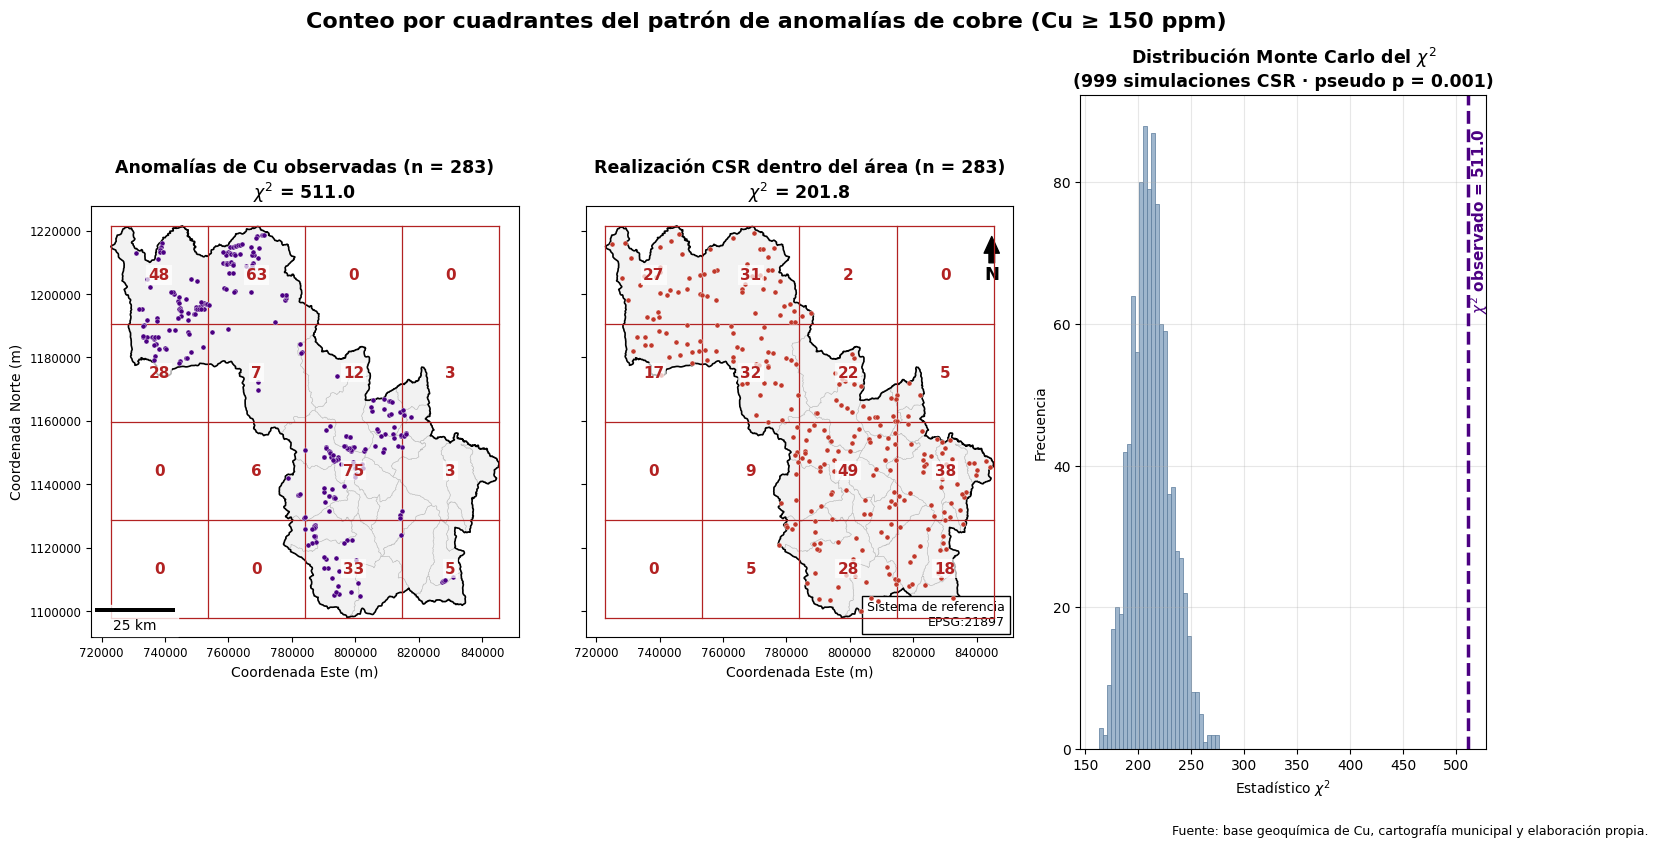

In [58]:
# ==========================================================
# FIGURA 13. CONTEO POR CUADRANTES: OBSERVADO, SIMULADO
# Y DISTRIBUCIÓN DE MONTE CARLO
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from matplotlib_scalebar.scalebar import ScaleBar


# ----------------------------------------------------------
# 1. Verificar los insumos de la Tabla 13
# ----------------------------------------------------------

variables_requeridas = [
    "coordenadas_cuadrantes", "conteos_anomalias_cuadrantes",
    "coordenadas_csr", "conteos_csr",
    "chi2_observado", "chi2_csr_ejemplo",
    "chi2_simulados", "pseudo_p",
    "bordes_x", "bordes_y"
]

variables_faltantes = [
    v for v in variables_requeridas if v not in globals()
]

if variables_faltantes:
    raise NameError(
        "Primero debes ejecutar la celda de la Tabla 13. "
        f"Variables faltantes: {variables_faltantes}"
    )

limite_estudio_cuadrantes = municipios.dissolve()


# ----------------------------------------------------------
# 2. Función para dibujar los paneles cartográficos
# ----------------------------------------------------------

def dibujar_panel(ax, coordenadas, conteos, titulo,
                  color_puntos):
    """Dibuja municipios, límite, puntos, malla y conteos."""

    municipios.plot(
        ax=ax,
        facecolor="#F2F2F2",
        edgecolor="#BDBDBD",
        linewidth=0.4
    )

    limite_estudio_cuadrantes.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1.2
    )

    ax.scatter(
        coordenadas[:, 0],
        coordenadas[:, 1],
        s=13,
        color=color_puntos,
        edgecolor="white",
        linewidth=0.25,
        zorder=5
    )

    for borde in bordes_x:
        ax.plot(
            [borde, borde],
            [bordes_y[0], bordes_y[-1]],
            color="#B22222", linewidth=0.9, zorder=4
        )

    for borde in bordes_y:
        ax.plot(
            [bordes_x[0], bordes_x[-1]],
            [borde, borde],
            color="#B22222", linewidth=0.9, zorder=4
        )

    for i in range(len(bordes_x) - 1):
        for j in range(len(bordes_y) - 1):
            ax.text(
                (bordes_x[i] + bordes_x[i + 1]) / 2,
                (bordes_y[j] + bordes_y[j + 1]) / 2,
                f"{int(conteos[i, j])}",
                ha="center", va="center",
                fontsize=11, fontweight="bold",
                color="#B22222", zorder=6,
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.7,
                    pad=1.5
                )
            )

    ax.set_title(titulo, fontsize=12.5, fontweight="bold")
    ax.set_xlabel("Coordenada Este (m)")
    ax.ticklabel_format(style="plain")
    ax.tick_params(labelsize=8.5)


# ----------------------------------------------------------
# 3. Construir la figura
# ----------------------------------------------------------

figura_cuadrantes = plt.figure(figsize=(18, 8.5))

rejilla = figura_cuadrantes.add_gridspec(
    1, 3, width_ratios=[1, 1, 0.95], wspace=0.16
)

eje_observado = figura_cuadrantes.add_subplot(rejilla[0])
eje_simulado = figura_cuadrantes.add_subplot(
    rejilla[1], sharex=eje_observado, sharey=eje_observado
)
eje_montecarlo = figura_cuadrantes.add_subplot(rejilla[2])

dibujar_panel(
    eje_observado,
    coordenadas_cuadrantes,
    conteos_anomalias_cuadrantes,
    (
        "Anomalías de Cu observadas "
        f"(n = {len(coordenadas_cuadrantes)})\n"
        f"$\\chi^2$ = {chi2_observado:,.1f}"
    ),
    "#4B0082"
)

dibujar_panel(
    eje_simulado,
    coordenadas_csr,
    conteos_csr,
    (
        "Realización CSR dentro del área "
        f"(n = {len(coordenadas_csr)})\n"
        f"$\\chi^2$ = {chi2_csr_ejemplo:,.1f}"
    ),
    "#C0392B"
)

eje_observado.set_ylabel("Coordenada Norte (m)")
plt.setp(eje_simulado.get_yticklabels(), visible=False)


# ----------------------------------------------------------
# 4. Panel de la distribución de Monte Carlo
# ----------------------------------------------------------

eje_montecarlo.hist(
    chi2_simulados,
    bins=30,
    color="#9FB6CD",
    edgecolor="#5A7A9B",
    linewidth=0.5
)

eje_montecarlo.axvline(
    chi2_observado,
    color="#4B0082",
    linewidth=2.5,
    linestyle="--"
)

eje_montecarlo.text(
    chi2_observado,
    eje_montecarlo.get_ylim()[1] * 0.95,
    f"  $\\chi^2$ observado = {chi2_observado:,.1f}",
    color="#4B0082",
    fontsize=11,
    fontweight="bold",
    ha="left",
    va="top",
    rotation=90
)

eje_montecarlo.set_title(
    (
        "Distribución Monte Carlo del $\\chi^2$\n"
        f"({len(chi2_simulados)} simulaciones CSR · "
        f"pseudo p = {pseudo_p:.3f})"
    ),
    fontsize=12.5,
    fontweight="bold"
)

eje_montecarlo.set_xlabel("Estadístico $\\chi^2$")
eje_montecarlo.set_ylabel("Frecuencia")
eje_montecarlo.grid(alpha=0.3)


# ----------------------------------------------------------
# 5. Elementos cartográficos
# ----------------------------------------------------------

eje_observado.add_artist(
    ScaleBar(1, units="m", location="lower left",
             box_alpha=0.8)
)

eje_simulado.annotate(
    "N",
    xy=(0.95, 0.93), xytext=(0.95, 0.83),
    xycoords="axes fraction", textcoords="axes fraction",
    ha="center", fontsize=13, fontweight="bold",
    arrowprops=dict(facecolor="black", width=4, headwidth=11)
)

eje_simulado.text(
    0.98, 0.02,
    "Sistema de referencia\nEPSG:21897",
    transform=eje_simulado.transAxes,
    ha="right", va="bottom", fontsize=9,
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        boxstyle="square,pad=0.4"
    )
)

figura_cuadrantes.suptitle(
    "Conteo por cuadrantes del patrón de anomalías de "
    "cobre (Cu ≥ 150 ppm)",
    fontsize=16,
    fontweight="bold"
)

figura_cuadrantes.text(
    0.99, 0.01,
    "Fuente: base geoquímica de Cu, cartografía municipal "
    "y elaboración propia.",
    ha="right", fontsize=9
)


# ----------------------------------------------------------
# 6. Guardar la Figura 13
# ----------------------------------------------------------

plt.savefig(
    FIGURAS / "Figura_13_Conteo_Cuadrantes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Figura 13.** Conteo por cuadrantes del patrón de anomalías de cobre, realización simulada bajo aleatoriedad espacial completa y distribución de Monte Carlo del estadístico chi-cuadrado.

El chi-cuadrado del patrón de anomalías (χ² = 510.95) supera al de la totalidad de las 999 simulaciones (media = 212.6; percentil 95 = 246.4; máximo = 287.4), con un pseudo valor p de 0.001. Se rechaza por lo tanto la hipótesis de aleatoriedad espacial completa: las anomalías de cobre se concentran en cuadrantes específicos del área de estudio — principalmente el sector noroccidental (Urrao) y la porción central — más allá de lo atribuible a la forma del dominio o al azar. Este resultado es robusto frente al umbral: con Cu ≥ 200 ppm (n = 60) la conclusión es idéntica (pseudo p = 0.001).

## 4.7 Evaluación del patrón de anomalías mediante las funciones G, F y K

Las funciones de distancia caracterizan el patrón a múltiples escalas: la función G describe la distribución acumulada de las distancias al vecino más cercano entre anomalías; la función F, la distribución de las distancias desde puntos arbitrarios del área hasta la anomalía más próxima (espacios vacíos); y la función K de Ripley, el número esperado de anomalías vecinas en función de la distancia. Las tres se contrastan con envolventes construidas a partir de simulaciones de aleatoriedad espacial completa generadas dentro del polígono del área de estudio, lo que condiciona la inferencia a la forma irregular del dominio, en consistencia con la sección 4.6.

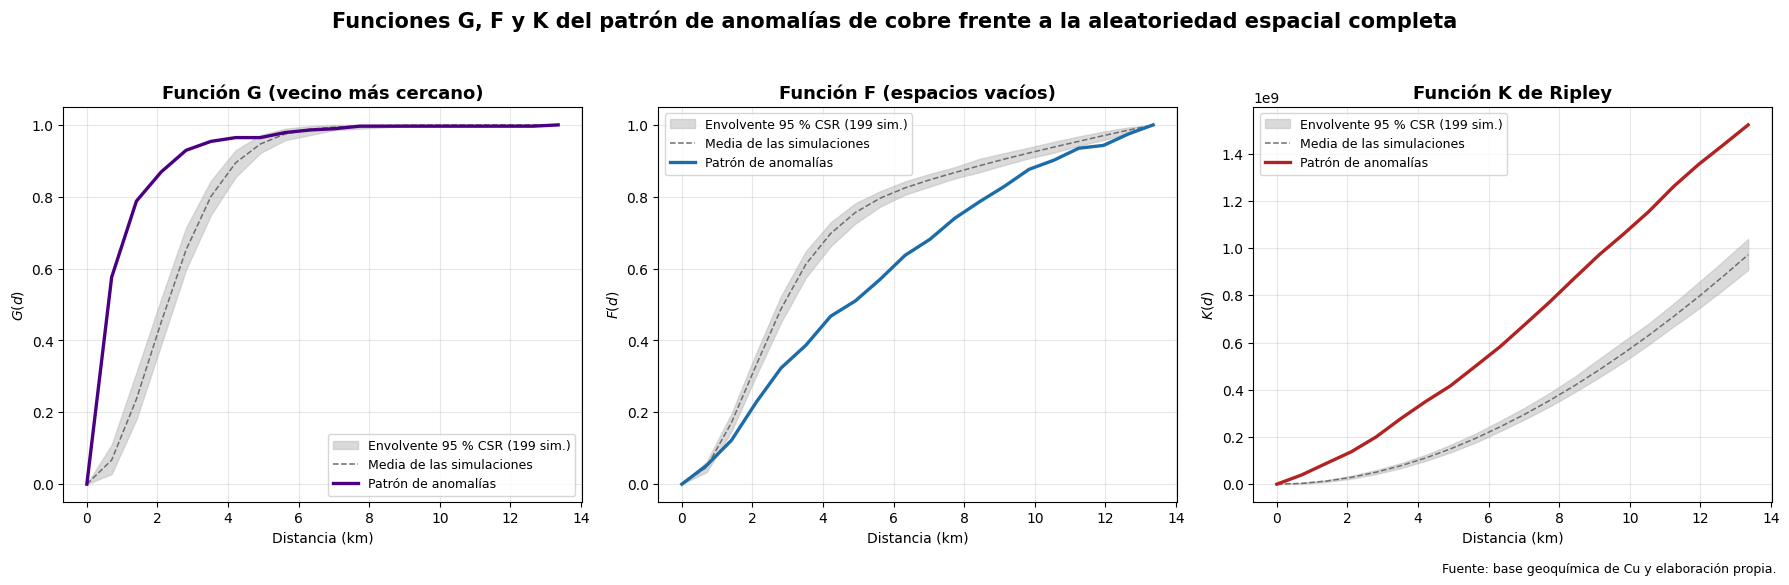

Función,Posición frente a la envolvente CSR,Puntos del soporte fuera de la envolvente,Lectura
G (vecino más cercano),Por encima a distancias cortas,8 de 20,Las anomalías tienen vecinas más próximas de lo esperado bajo el azar: agrupamiento
F (espacios vacíos),Por debajo en casi todo el soporte,17 de 20,Los espacios vacíos son más extensos de lo esperado bajo el azar: agrupamiento
K de Ripley,Por encima en casi todo el soporte,19 de 20,Exceso de anomalías vecinas a todas las escalas: agrupamiento


In [59]:
# ==========================================================
# TABLA 14 Y FIGURA 14. FUNCIONES G, F Y K DEL PATRÓN
# DE ANOMALÍAS FRENTE A LA ALEATORIEDAD ESPACIAL COMPLETA
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pointpats.distance_statistics import (
    g_test,
    f_test,
    k_test
)


# ----------------------------------------------------------
# 1. Parámetros del análisis
# ----------------------------------------------------------
# Nota: con 199 simulaciones por función, la celda tarda
# entre 1 y 2 minutos.

N_SIMULACIONES_GFK = 199
PUNTOS_SOPORTE = 20
SEMILLA_GFK = 42


# ----------------------------------------------------------
# 2. Verificar los insumos
# ----------------------------------------------------------

if "muestras_anomalias" not in globals():
    raise NameError(
        "Primero debes ejecutar la transformación "
        "indicadora (4.2)."
    )

poligono_gfk = municipios.geometry.union_all()

coordenadas_gfk = np.column_stack([
    muestras_anomalias.geometry.x.to_numpy(),
    muestras_anomalias.geometry.y.to_numpy()
])

mascara_gfk = np.isfinite(coordenadas_gfk).all(axis=1)
coordenadas_gfk = coordenadas_gfk[mascara_gfk]


# ----------------------------------------------------------
# 3. Calcular las tres funciones con simulaciones CSR
# ----------------------------------------------------------
# El argumento hull restringe las simulaciones al polígono
# del área de estudio.

np.random.seed(SEMILLA_GFK)

resultado_g = g_test(
    coordenadas_gfk,
    support=PUNTOS_SOPORTE,
    keep_simulations=True,
    n_simulations=N_SIMULACIONES_GFK,
    hull=poligono_gfk
)

resultado_f = f_test(
    coordenadas_gfk,
    support=PUNTOS_SOPORTE,
    keep_simulations=True,
    n_simulations=N_SIMULACIONES_GFK,
    hull=poligono_gfk
)

resultado_k = k_test(
    coordenadas_gfk,
    support=PUNTOS_SOPORTE,
    keep_simulations=True,
    n_simulations=N_SIMULACIONES_GFK,
    hull=poligono_gfk
)


# ----------------------------------------------------------
# 4. Resumir la posición frente a la envolvente del 95 %
# ----------------------------------------------------------

def resumir_funcion(resultado):
    """
    Cuenta los puntos del soporte en los que la curva
    observada queda fuera de la envolvente del 95 % de
    las simulaciones.
    """
    limite_inferior = np.percentile(
        resultado.simulations, 2.5, axis=0
    )
    limite_superior = np.percentile(
        resultado.simulations, 97.5, axis=0
    )
    fuera = int(np.sum(
        (resultado.statistic < limite_inferior)
        | (resultado.statistic > limite_superior)
    ))
    return limite_inferior, limite_superior, fuera


env_g_inf, env_g_sup, fuera_g = resumir_funcion(resultado_g)
env_f_inf, env_f_sup, fuera_f = resumir_funcion(resultado_f)
env_k_inf, env_k_sup, fuera_k = resumir_funcion(resultado_k)


# ----------------------------------------------------------
# 5. Construir la Tabla 14
# ----------------------------------------------------------

tabla_14 = pd.DataFrame({

    "Función": [
        "G (vecino más cercano)",
        "F (espacios vacíos)",
        "K de Ripley"
    ],

    "Posición frente a la envolvente CSR": [
        "Por encima a distancias cortas",
        "Por debajo en casi todo el soporte",
        "Por encima en casi todo el soporte"
    ],

    "Puntos del soporte fuera de la envolvente": [
        f"{fuera_g} de {PUNTOS_SOPORTE}",
        f"{fuera_f} de {PUNTOS_SOPORTE}",
        f"{fuera_k} de {PUNTOS_SOPORTE}"
    ],

    "Lectura": [
        "Las anomalías tienen vecinas más próximas de lo "
        "esperado bajo el azar: agrupamiento",
        "Los espacios vacíos son más extensos de lo esperado "
        "bajo el azar: agrupamiento",
        "Exceso de anomalías vecinas a todas las escalas: "
        "agrupamiento"
    ]
})

tabla_14_estilizada = (
    tabla_14.style
    .hide(axis="index")
    .set_caption(
        "Tabla 14. Síntesis de las funciones G, F y K del "
        "patrón de anomalías frente a las envolventes de "
        f"simulación CSR (n = {N_SIMULACIONES_GFK} "
        "simulaciones por función)."
    )
    .set_properties(
        subset=["Puntos del soporte fuera de la envolvente"],
        **{"text-align": "center"}
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "13px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "1px solid #555555"),
                ("padding", "7px")
            ]
        },
        {
            "selector": "td",
            "props": [("padding", "6px")]
        }
    ])
)

tabla_14.to_csv(
    RESULTADOS / "01_Tablas" / "Tabla_14_Funciones_GFK_Anomalias.csv",
    index=False,
    encoding="utf-8-sig"
)


# ----------------------------------------------------------
# 6. Construir la Figura 14
# ----------------------------------------------------------

figura_gfk, ejes_gfk = plt.subplots(1, 3, figsize=(18, 5.8))

configuracion_gfk = [
    (resultado_g, env_g_inf, env_g_sup,
     "Función G (vecino más cercano)", "$G(d)$",
     "#4B0082", "lower right"),
    (resultado_f, env_f_inf, env_f_sup,
     "Función F (espacios vacíos)", "$F(d)$",
     "#1B6CA8", "upper left"),
    (resultado_k, env_k_inf, env_k_sup,
     "Función K de Ripley", "$K(d)$",
     "#B22222", "upper left"),
]

for eje, (resultado, env_inf, env_sup, titulo,
          etiqueta_y, color, posicion_leyenda) in zip(
        ejes_gfk, configuracion_gfk):

    distancia_km = resultado.support / 1000

    eje.fill_between(
        distancia_km, env_inf, env_sup,
        color="#BDBDBD", alpha=0.55,
        label=(
            "Envolvente 95 % CSR "
            f"({N_SIMULACIONES_GFK} sim.)"
        )
    )

    eje.plot(
        distancia_km,
        resultado.simulations.mean(axis=0),
        color="#6E6E6E", linewidth=1.1, linestyle="--",
        label="Media de las simulaciones"
    )

    eje.plot(
        distancia_km, resultado.statistic,
        color=color, linewidth=2.4,
        label="Patrón de anomalías"
    )

    eje.set_title(titulo, fontsize=13, fontweight="bold")
    eje.set_xlabel("Distancia (km)")
    eje.set_ylabel(etiqueta_y)
    eje.grid(alpha=0.3)
    eje.legend(fontsize=9, loc=posicion_leyenda)

figura_gfk.suptitle(
    "Funciones G, F y K del patrón de anomalías de cobre "
    "frente a la aleatoriedad espacial completa",
    fontsize=15, fontweight="bold"
)

figura_gfk.text(
    0.99, 0.01,
    "Fuente: base geoquímica de Cu y elaboración propia.",
    ha="right", fontsize=9
)

plt.tight_layout(rect=[0, 0.03, 1, 0.94])

plt.savefig(
    FIGURAS / "Figura_14_Funciones_GFK_Anomalias.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

tabla_14_estilizada

**Figura 14.** Funciones G, F y K del patrón de anomalías de cobre frente a las envolventes del 95 % construidas con 199 simulaciones de aleatoriedad espacial completa dentro del polígono del área de estudio.

Las tres funciones coinciden en la misma conclusión. La función G se ubica por encima de la envolvente a distancias cortas (7 de 20 puntos del soporte fuera): a 700 m, cerca del 58 % de las anomalías ya tiene una vecina anómala, muy por encima de lo esperado bajo el azar. La función F se ubica por debajo de la envolvente en 17 de 20 puntos del soporte, lo que indica espacios vacíos más extensos que los de un patrón aleatorio. La función K supera la envolvente en 19 de 20 puntos: existe un exceso de anomalías vecinas a prácticamente todas las escalas analizadas (hasta ~13 km). En conjunto con el conteo por cuadrantes (4.6) y el vecino más cercano (4.5), la evidencia es consistente: el patrón de anomalías de cobre está significativamente agrupado, y dicho agrupamiento no es atribuible ni al azar ni a la forma irregular del área de estudio.

## 4.8 Relación del patrón de anomalías con las unidades geológicas

Se evalúa si las anomalías de cobre se asocian preferencialmente a determinadas unidades geológicas. Cada muestra se asigna a su unidad mediante una unión espacial (relación *within*, sección 2.6) y se calcula la razón de enriquecimiento de cada unidad: el cociente entre el porcentaje de anomalías y el porcentaje de muestras que aloja. Una razón cercana a 1 indica que la unidad recibe anomalías en proporción a su muestreo; una razón mayor que 1, un exceso. La significancia del exceso se evalúa mediante reetiquetado por permutación: se compara el número observado de anomalías de cada unidad con su distribución en 999 asignaciones aleatorias de las 283 etiquetas de anomalía entre los 2,029 sitios muestreados. Este diseño condiciona la prueba al esquema de muestreo real, eliminando el sesgo de la red de drenajes.

In [60]:
# ==========================================================
# TABLA 15. ENRIQUECIMIENTO DE ANOMALÍAS POR UNIDAD
# GEOLÓGICA (PRUEBA DE REETIQUETADO POR PERMUTACIÓN)
# ==========================================================

import numpy as np
import pandas as pd
import geopandas as gpd


# ----------------------------------------------------------
# 1. Parámetros del análisis
# ----------------------------------------------------------

N_PERMUTACIONES_GEO = 999
SEMILLA_GEO = 42
MINIMO_MUESTRAS_UNIDAD = 10


# ----------------------------------------------------------
# 2. Verificar los insumos
# ----------------------------------------------------------

if "muestras_indicadora" not in globals():
    raise NameError(
        "Primero debes ejecutar la transformación "
        "indicadora (4.2)."
    )

if "geologia" not in globals():
    raise NameError(
        "No se encontró la capa de geología. Ejecuta "
        "primero la carga de datos (1.2)."
    )


# ----------------------------------------------------------
# 3. Normalizar la unidad de análisis
# ----------------------------------------------------------
# Se agrupa por la descripción de la unidad porque el campo
# de código (ENTITY) presenta rótulos truncados e
# inconsistentes en la cartografía disponible.

geologia_enriq = geologia.copy()

geologia_enriq["UNIDAD_ANALISIS"] = (
    geologia_enriq["DESCRIPCIO"]
    .fillna(geologia_enriq["ENTITY"])
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace(
        "GABRO ALTAMIRA",
        "GABRO DE ALTAMIRA",
        regex=False
    )
)


# ----------------------------------------------------------
# 4. Unión espacial de las muestras con la geología
# ----------------------------------------------------------

union_geo = gpd.sjoin(
    muestras_indicadora,
    geologia_enriq[["UNIDAD_ANALISIS", "geometry"]],
    how="left",
    predicate="within"
)

# Se conserva una sola unidad por muestra en caso de
# polígonos superpuestos
union_geo = union_geo[
    ~union_geo.index.duplicated(keep="first")
]

union_geo["UNIDAD_ANALISIS"] = (
    union_geo["UNIDAD_ANALISIS"].fillna("SIN UNIDAD")
)

numero_muestras_geo = len(union_geo)
numero_anomalias_geo = int(union_geo["INDICADOR"].sum())


# ----------------------------------------------------------
# 5. Conteos y razón de enriquecimiento por unidad
# ----------------------------------------------------------

tabla_unidades = union_geo.groupby("UNIDAD_ANALISIS").agg(
    muestras=("INDICADOR", "size"),
    anomalias=("INDICADOR", "sum")
)

tabla_unidades["tasa_anomalias"] = (
    tabla_unidades["anomalias"]
    / tabla_unidades["muestras"] * 100
)

tabla_unidades["enriquecimiento"] = (
    (tabla_unidades["anomalias"] / numero_anomalias_geo)
    / (tabla_unidades["muestras"] / numero_muestras_geo)
)


# ----------------------------------------------------------
# 6. Prueba de reetiquetado por permutación
# ----------------------------------------------------------
# En cada permutación se redistribuyen aleatoriamente las
# etiquetas de anomalía entre los sitios muestreados y se
# cuenta cuántas caen en cada unidad.

np.random.seed(SEMILLA_GEO)

codigos_unidad, indices_unidad = np.unique(
    union_geo["UNIDAD_ANALISIS"].to_numpy(),
    return_inverse=True
)

vector_anomalias = union_geo["INDICADOR"].to_numpy()

conteos_simulados = np.zeros(
    (N_PERMUTACIONES_GEO, len(codigos_unidad))
)

for indice_permutacion in range(N_PERMUTACIONES_GEO):

    permutacion = np.random.permutation(vector_anomalias)

    conteos_simulados[indice_permutacion] = np.bincount(
        indices_unidad,
        weights=permutacion,
        minlength=len(codigos_unidad)
    )

conteos_observados = np.bincount(
    indices_unidad,
    weights=vector_anomalias,
    minlength=len(codigos_unidad)
)

pseudo_p_unidades = {}
esperado_unidades = {}

for posicion, unidad in enumerate(codigos_unidad):

    pseudo_p_unidades[unidad] = (
        (1 + np.sum(
            conteos_simulados[:, posicion]
            >= conteos_observados[posicion]
        ))
        / (1 + N_PERMUTACIONES_GEO)
    )

    esperado_unidades[unidad] = float(
        conteos_simulados[:, posicion].mean()
    )

tabla_unidades["anomalias_esperadas"] = [
    esperado_unidades[u] for u in tabla_unidades.index
]

tabla_unidades["pseudo_p_exceso"] = [
    pseudo_p_unidades[u] for u in tabla_unidades.index
]


# ----------------------------------------------------------
# 7. Construir la Tabla 15
# ----------------------------------------------------------
# Se reportan las unidades con un mínimo de muestras para
# que la razón de enriquecimiento sea interpretable.

tabla_15 = (
    tabla_unidades[
        tabla_unidades["muestras"] >= MINIMO_MUESTRAS_UNIDAD
    ]
    .sort_values("enriquecimiento", ascending=False)
    .reset_index()
    .rename(columns={
        "UNIDAD_ANALISIS": "Unidad geológica",
        "muestras": "Muestras",
        "anomalias": "Anomalías",
        "tasa_anomalias": "Tasa de anomalías (%)",
        "enriquecimiento": "Enriquecimiento",
        "anomalias_esperadas": "Anomalías esperadas",
        "pseudo_p_exceso": "Pseudo p (exceso)"
    })
)

tabla_15["Anomalías"] = tabla_15["Anomalías"].astype(int)


# ----------------------------------------------------------
# 8. Mostrar y guardar la Tabla 15
# ----------------------------------------------------------

def resaltar_significativas(fila):
    """Resalta las unidades con exceso significativo."""
    if fila["Pseudo p (exceso)"] < 0.05:
        return ["background-color: #FBE9E7"] * len(fila)
    return [""] * len(fila)

tabla_15_estilizada = (
    tabla_15.style
    .hide(axis="index")
    .apply(resaltar_significativas, axis=1)
    .set_caption(
        "Tabla 15. Enriquecimiento de anomalías de cobre por "
        "unidad geológica y prueba de reetiquetado "
        f"({N_PERMUTACIONES_GEO} permutaciones; unidades con "
        f"al menos {MINIMO_MUESTRAS_UNIDAD} muestras)."
    )
    .format({
        "Tasa de anomalías (%)": "{:.1f}",
        "Enriquecimiento": "{:.2f}",
        "Anomalías esperadas": "{:.1f}",
        "Pseudo p (exceso)": "{:.3f}"
    })
    .set_properties(
        subset=[
            "Muestras", "Anomalías",
            "Tasa de anomalías (%)", "Enriquecimiento",
            "Anomalías esperadas", "Pseudo p (exceso)"
        ],
        **{"text-align": "center"}
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "13px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "1px solid #555555"),
                ("padding", "7px")
            ]
        },
        {
            "selector": "td",
            "props": [("padding", "6px")]
        }
    ])
)

tabla_15.to_csv(
    RESULTADOS / "01_Tablas" / "Tabla_15_Enriquecimiento_Unidades.csv",
    index=False,
    encoding="utf-8-sig"
)

tabla_15_estilizada

Unidad geológica,Muestras,Anomalías,Tasa de anomalías (%),Enriquecimiento,Anomalías esperadas,Pseudo p (exceso)
BATOLITO DE SEGOVIA (DIORITA),10,6,60.0,4.30,1.4,0.002
VOLCANICO DE URUMITA,15,9,60.0,4.30,2.1,0.001
MIEMBRO NUTIBARA,40,16,40.0,2.87,5.7,0.001
VOLCANICO BARROSO,25,8,32.0,2.29,3.6,0.028
KIDC,12,2,16.7,1.19,1.7,0.540
COMPLEJO VOLCANICO STA CECILIA-LA EQUIS,180,26,14.4,1.04,25.1,0.448
BATOLITO DE MANDE,299,43,14.4,1.03,42.0,0.450
FORMACION AMAGA,106,15,14.2,1.01,14.7,0.517
ALUVIONES RECIENTES,187,24,12.8,0.92,26.1,0.705
MIEMBRO URRAO,755,89,11.8,0.85,104.9,0.990


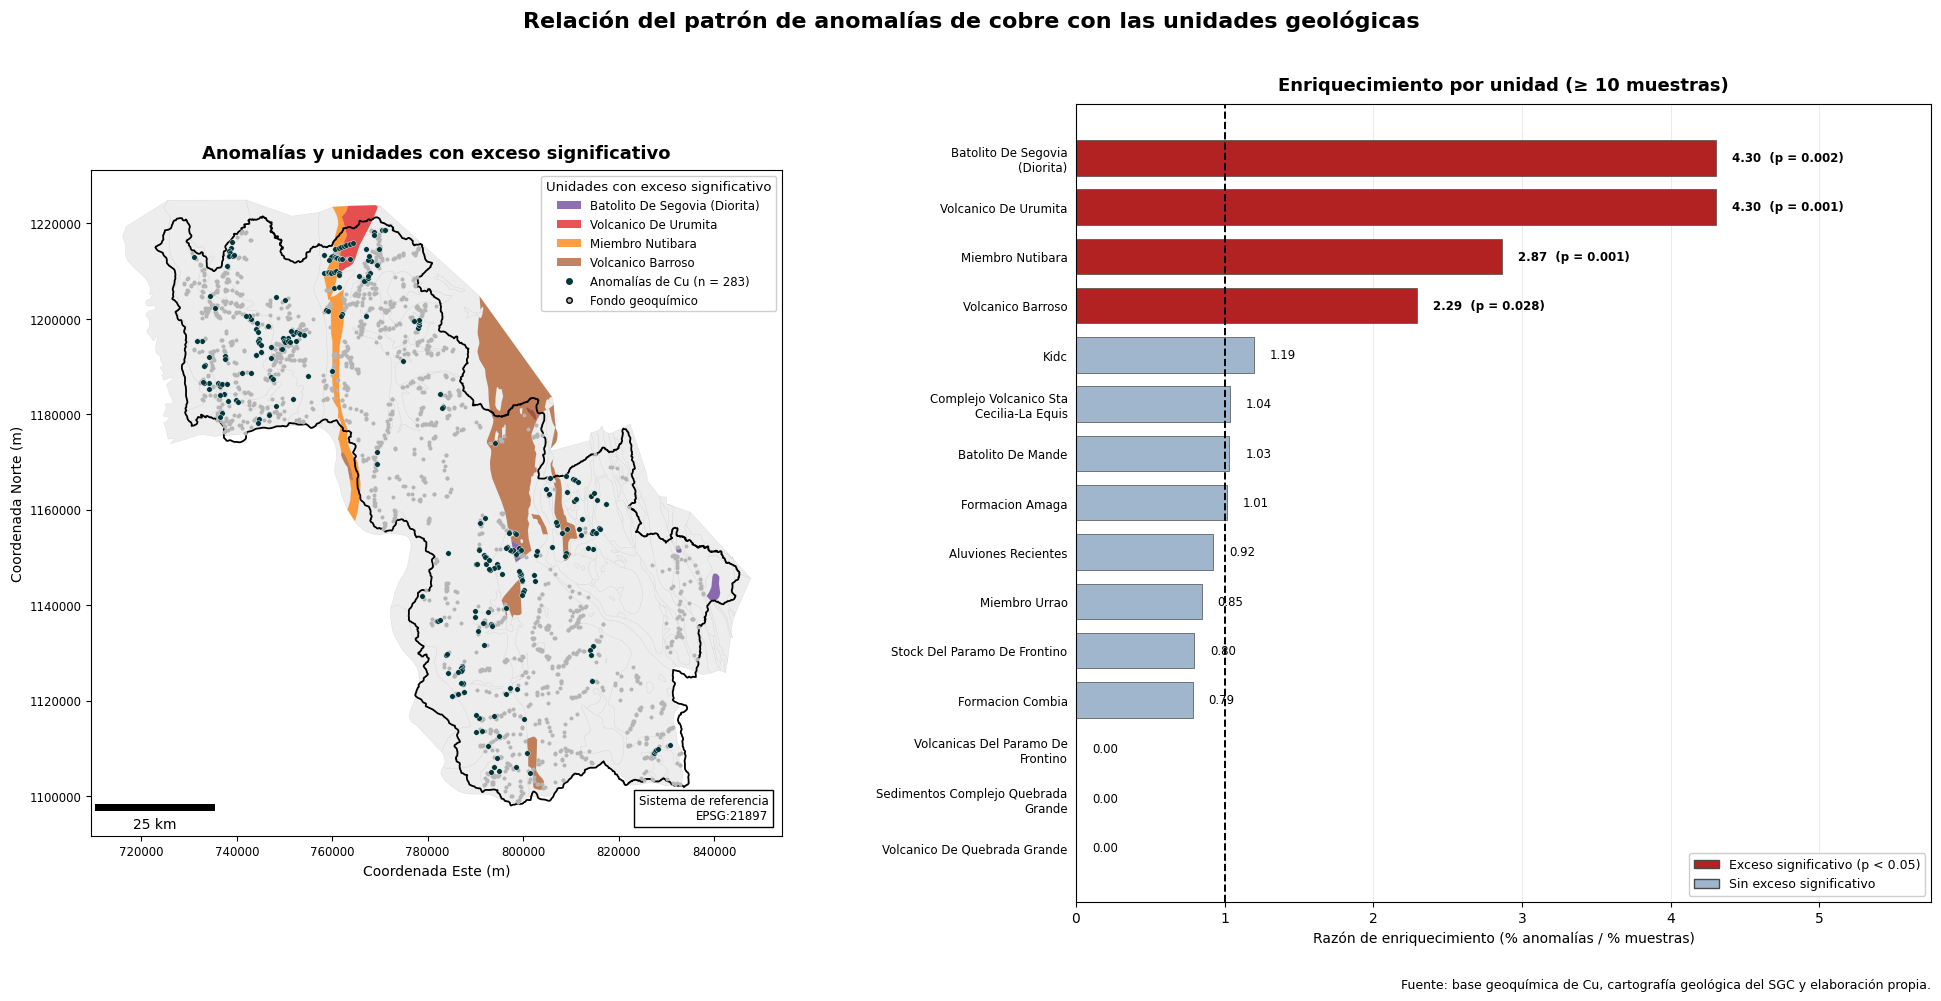

In [64]:
# ==========================================================
# FIGURA 15. ANOMALÍAS, UNIDADES GEOLÓGICAS
# Y RAZÓN DE ENRIQUECIMIENTO
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import textwrap

from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ----------------------------------------------------------
# 1. Verificar los insumos de la Tabla 15
# ----------------------------------------------------------

if "tabla_15" not in globals():
    raise NameError(
        "Primero debes ejecutar la celda de la Tabla 15."
    )

limite_geo = municipios.dissolve()

anomalias_geo = muestras_indicadora[
    muestras_indicadora["INDICADOR"] == 1
].copy()

fondo_geo = muestras_indicadora[
    muestras_indicadora["INDICADOR"] == 0
].copy()


# ----------------------------------------------------------
# 2. Identificar unidades con exceso significativo
# ----------------------------------------------------------

unidades_significativas = tabla_15[
    tabla_15["Pseudo p (exceso)"] < 0.05
]["Unidad geológica"].tolist()

colores_significativas = [
    "#6A3D9A",
    "#E31A1C",
    "#FF7F00",
    "#B15928",
    "#33A02C"
]


# ----------------------------------------------------------
# 3. Construir la figura
# ----------------------------------------------------------

figura_geo = plt.figure(
    figsize=(20, 10.5)
)

rejilla_geo = figura_geo.add_gridspec(
    1,
    2,
    width_ratios=[1.05, 1.30],
    wspace=0.38,
    left=0.06,
    right=0.98,
    top=0.88,
    bottom=0.12
)

eje_mapa_geo = figura_geo.add_subplot(
    rejilla_geo[0]
)

eje_barras_geo = figura_geo.add_subplot(
    rejilla_geo[1]
)


# ----------------------------------------------------------
# 4. Panel A: mapa
# ----------------------------------------------------------

geologia_enriq.plot(
    ax=eje_mapa_geo,
    facecolor="#EDEDED",
    edgecolor="#CFCFCF",
    linewidth=0.2
)

elementos_geo = []

for posicion, unidad in enumerate(
    unidades_significativas
):

    color = colores_significativas[
        posicion % len(colores_significativas)
    ]

    capa_unidad = geologia_enriq[
        geologia_enriq["UNIDAD_ANALISIS"] == unidad
    ]

    if not capa_unidad.empty:

        capa_unidad.plot(
            ax=eje_mapa_geo,
            facecolor=color,
            edgecolor="none",
            alpha=0.75
        )

        elementos_geo.append(
            Patch(
                facecolor=color,
                alpha=0.75,
                label=unidad.title()
            )
        )

limite_geo.boundary.plot(
    ax=eje_mapa_geo,
    color="black",
    linewidth=1.3
)

eje_mapa_geo.scatter(
    fondo_geo.geometry.x,
    fondo_geo.geometry.y,
    s=3.5,
    color="#B5B5B5",
    zorder=4
)

eje_mapa_geo.scatter(
    anomalias_geo.geometry.x,
    anomalias_geo.geometry.y,
    s=16,
    color="#00363A",
    edgecolor="white",
    linewidth=0.3,
    zorder=5
)

elementos_geo += [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="#00363A",
        markeredgecolor="white",
        markersize=6,
        label=(
            f"Anomalías de Cu "
            f"(n = {len(anomalias_geo)})"
        )
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="#B5B5B5",
        markersize=4,
        label="Fondo geoquímico"
    )
]

eje_mapa_geo.legend(
    handles=elementos_geo,
    title="Unidades con exceso significativo",
    loc="upper right",
    fontsize=8.5,
    title_fontsize=9.5,
    framealpha=0.95
)

eje_mapa_geo.add_artist(
    ScaleBar(
        1,
        units="m",
        location="lower left",
        box_alpha=0.8
    )
)

eje_mapa_geo.text(
    0.98,
    0.02,
    "Sistema de referencia\nEPSG:21897",
    transform=eje_mapa_geo.transAxes,
    ha="right",
    va="bottom",
    fontsize=8.5,
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        boxstyle="square,pad=0.4"
    )
)

eje_mapa_geo.set_title(
    "Anomalías y unidades con exceso significativo",
    fontsize=13,
    fontweight="bold",
    pad=8
)

eje_mapa_geo.set_xlabel(
    "Coordenada Este (m)"
)

eje_mapa_geo.set_ylabel(
    "Coordenada Norte (m)"
)

eje_mapa_geo.ticklabel_format(
    style="plain"
)

eje_mapa_geo.tick_params(
    labelsize=8.5
)

eje_mapa_geo.set_aspect(
    "equal"
)


# ----------------------------------------------------------
# 5. Panel B: razón de enriquecimiento
# ----------------------------------------------------------

tabla_barras = tabla_15.sort_values(
    "Enriquecimiento",
    ascending=True
).copy()

tabla_barras["Unidad_etiqueta"] = (
    tabla_barras["Unidad geológica"]
    .str.title()
    .apply(
        lambda texto: textwrap.fill(
            str(texto),
            width=28,
            break_long_words=False,
            break_on_hyphens=False
        )
    )
)

colores_barras = [
    "#B22222" if p < 0.05 else "#9FB6CD"
    for p in tabla_barras["Pseudo p (exceso)"]
]

posiciones_y = np.arange(
    len(tabla_barras)
)

eje_barras_geo.barh(
    posiciones_y,
    tabla_barras["Enriquecimiento"],
    color=colores_barras,
    edgecolor="#4A4A4A",
    linewidth=0.5,
    height=0.72
)

eje_barras_geo.set_yticks(
    posiciones_y
)

eje_barras_geo.set_yticklabels(
    tabla_barras["Unidad_etiqueta"],
    fontsize=8.5,
    ha="right"
)

eje_barras_geo.tick_params(
    axis="y",
    pad=6,
    length=0
)

eje_barras_geo.axvline(
    1,
    color="black",
    linewidth=1.4,
    linestyle="--",
    zorder=3
)

max_enriquecimiento = tabla_barras[
    "Enriquecimiento"
].max()

desplazamiento = max(
    max_enriquecimiento * 0.025,
    0.06
)

for posicion, (_, fila) in enumerate(
    tabla_barras.iterrows()
):

    significativa = (
        fila["Pseudo p (exceso)"] < 0.05
    )

    etiqueta_valor = (
        f"{fila['Enriquecimiento']:.2f}"
    )

    if significativa:

        etiqueta_valor += (
            f"  (p = "
            f"{fila['Pseudo p (exceso)']:.3f})"
        )

    eje_barras_geo.text(
        fila["Enriquecimiento"]
        + desplazamiento,
        posicion,
        etiqueta_valor,
        va="center",
        ha="left",
        fontsize=8.5,
        fontweight=(
            "bold"
            if significativa
            else "normal"
        ),
        clip_on=False
    )

eje_barras_geo.set_xlim(
    0,
    max_enriquecimiento + 1.45
)

eje_barras_geo.set_xlabel(
    "Razón de enriquecimiento "
    "(% anomalías / % muestras)",
    fontsize=10
)

eje_barras_geo.set_title(
    (
        "Enriquecimiento por unidad "
        f"(≥ {MINIMO_MUESTRAS_UNIDAD} muestras)"
    ),
    fontsize=13,
    fontweight="bold",
    pad=10
)

eje_barras_geo.grid(
    alpha=0.25,
    axis="x",
    linewidth=0.7
)

eje_barras_geo.set_axisbelow(True)

eje_barras_geo.legend(
    handles=[
        Patch(
            facecolor="#B22222",
            edgecolor="#4A4A4A",
            label="Exceso significativo (p < 0.05)"
        ),
        Patch(
            facecolor="#9FB6CD",
            edgecolor="#4A4A4A",
            label="Sin exceso significativo"
        )
    ],
    loc="lower right",
    fontsize=9,
    framealpha=0.95
)


# ----------------------------------------------------------
# 6. Título general y fuente
# ----------------------------------------------------------

figura_geo.suptitle(
    "Relación del patrón de anomalías de cobre con las "
    "unidades geológicas",
    fontsize=16,
    fontweight="bold",
    y=0.97
)

figura_geo.text(
    0.98,
    0.035,
    "Fuente: base geoquímica de Cu, cartografía geológica "
    "del SGC y elaboración propia.",
    ha="right",
    va="bottom",
    fontsize=9
)


# ----------------------------------------------------------
# 7. Guardar la Figura 15
# ----------------------------------------------------------

plt.savefig(
    FIGURAS / "Figura_15_Enriquecimiento_Unidades.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15
)

plt.show()

**Figura 15.** Anomalías de cobre sobre las unidades geológicas con exceso significativo (panel izquierdo) y razón de enriquecimiento por unidad con su prueba de reetiquetado (panel derecho).

Los resultados muestran que el número absoluto de anomalías por unidad refleja principalmente el esfuerzo de muestreo: el Miembro Urrao, que aloja la mayor cantidad de anomalías (89), presenta de hecho un déficit relativo (enriquecimiento = 0.85; p = 0.99), al igual que el Batolito de Mandé y la Formación Combia (enriquecimiento ≈ 0.8 – 1.0). El exceso significativo se concentra en unidades volcánicas cretácicas de menor extensión: el Miembro Nutibara (16 anomalías observadas frente a 5.7 esperadas; tasa del 40 %; p = 0.001), el Volcánico de Urumita (9 frente a 2.1; 60 %; p = 0.001) y el Volcánico Barroso (8 frente a 3.6; 32 %; p = 0.028), además de la unidad rotulada Batolito de Segovia (Diorita) (6 frente a 1.4; p = 0.002), cuyo código Ksg aparece en la cartografía disponible asociado también al Gabro de Altamira, por lo que su denominación debe tomarse con reserva. En conjunto, las anomalías de cobre muestran una afinidad litológica clara con el vulcanismo cretácico del occidente del área, coherente con el agrupamiento espacial identificado en las secciones anteriores.

## 4.9 Relación del patrón de anomalías con las fallas geológicas

Se evalúa si las anomalías de cobre se localizan preferencialmente cerca de las fallas geológicas. Para cada uno de los 2,029 sitios muestreados se calcula la distancia a la falla más cercana y se compara la distribución de distancias de las anomalías con la del fondo geoquímico. La significancia se evalúa con el mismo esquema de reetiquetado de la sección 4.8: la distancia media de las 283 anomalías se compara con la de 999 selecciones aleatorias de 283 sitios entre los 2,029 muestreados, condicionando la prueba al esquema de muestreo real.

In [62]:
# ==========================================================
# TABLA 16. DISTANCIA DE LAS ANOMALÍAS A LAS FALLAS
# GEOLÓGICAS (PRUEBA DE REETIQUETADO POR PERMUTACIÓN)
# ==========================================================

import numpy as np
import pandas as pd


# ----------------------------------------------------------
# 1. Parámetros del análisis
# ----------------------------------------------------------

N_PERMUTACIONES_FALLAS = 999
SEMILLA_FALLAS = 42


# ----------------------------------------------------------
# 2. Verificar los insumos
# ----------------------------------------------------------

if "muestras_indicadora" not in globals():
    raise NameError(
        "Primero debes ejecutar la transformación "
        "indicadora (4.2)."
    )

if "fallas" not in globals():
    raise NameError(
        "No se encontró la capa de fallas. Ejecuta primero "
        "la carga de datos (1.2)."
    )


# ----------------------------------------------------------
# 3. Calcular la distancia a la falla más cercana
# ----------------------------------------------------------

fallas_union = fallas.geometry.union_all()

muestras_fallas = muestras_indicadora.copy()

muestras_fallas["DIST_FALLA"] = (
    muestras_fallas.geometry.distance(fallas_union)
)

distancias_todas = muestras_fallas["DIST_FALLA"].to_numpy()

vector_anomalias_fallas = (
    muestras_fallas["INDICADOR"].to_numpy()
)

distancias_anomalias = distancias_todas[
    vector_anomalias_fallas == 1
]

distancias_fondo = distancias_todas[
    vector_anomalias_fallas == 0
]

numero_anomalias_fallas = len(distancias_anomalias)


# ----------------------------------------------------------
# 4. Prueba de reetiquetado por permutación
# ----------------------------------------------------------
# En cada permutación se seleccionan al azar tantos sitios
# como anomalías hay, entre los 2,029 muestreados, y se
# calcula su distancia media a las fallas.

np.random.seed(SEMILLA_FALLAS)

medias_simuladas = np.empty(N_PERMUTACIONES_FALLAS)

for indice_permutacion in range(N_PERMUTACIONES_FALLAS):

    seleccion = np.random.permutation(
        len(distancias_todas)
    )[:numero_anomalias_fallas]

    medias_simuladas[indice_permutacion] = (
        distancias_todas[seleccion].mean()
    )

media_observada = float(distancias_anomalias.mean())

pseudo_p_fallas = (
    (1 + np.sum(medias_simuladas <= media_observada))
    / (1 + N_PERMUTACIONES_FALLAS)
)

if pseudo_p_fallas < 0.05:
    interpretacion_fallas = (
        "Las anomalías están significativamente más cerca "
        "de las fallas que el azar del muestreo"
    )
else:
    interpretacion_fallas = (
        "La cercanía de las anomalías a las fallas es "
        "compatible con el azar del muestreo"
    )


# ----------------------------------------------------------
# 5. Construir la Tabla 16
# ----------------------------------------------------------

tabla_16 = pd.DataFrame({

    "Parámetro": [
        "Anomalías analizadas",
        "Sitios del fondo geoquímico",
        "Distancia media de las anomalías",
        "Distancia mediana de las anomalías",
        "Distancia media del fondo",
        "Distancia mediana del fondo",
        "Distancia media simulada (reetiquetado)",
        "Percentil 5 de las medias simuladas",
        "Número de permutaciones",
        "Pseudo valor p (cercanía)",
        "Interpretación (α = 0.05)"
    ],

    "Valor": [
        f"{numero_anomalias_fallas:,}",
        f"{len(distancias_fondo):,}",
        f"{media_observada:,.1f} m",
        f"{np.median(distancias_anomalias):,.1f} m",
        f"{distancias_fondo.mean():,.1f} m",
        f"{np.median(distancias_fondo):,.1f} m",
        f"{medias_simuladas.mean():,.1f} m",
        f"{np.percentile(medias_simuladas, 5):,.1f} m",
        f"{N_PERMUTACIONES_FALLAS:,}",
        f"{pseudo_p_fallas:.4f}",
        interpretacion_fallas
    ]
})


# ----------------------------------------------------------
# 6. Mostrar y guardar la Tabla 16
# ----------------------------------------------------------

tabla_16_estilizada = (
    tabla_16.style
    .hide(axis="index")
    .set_caption(
        "Tabla 16. Distancia de las anomalías de cobre a las "
        "fallas geológicas y prueba de reetiquetado por "
        "permutación."
    )
    .set_properties(
        subset=["Valor"],
        **{"text-align": "center"}
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "13px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "1px solid #555555"),
                ("padding", "7px")
            ]
        },
        {
            "selector": "td",
            "props": [("padding", "6px")]
        }
    ])
)

tabla_16.to_csv(
    RESULTADOS / "01_Tablas" / "Tabla_16_Distancia_Fallas_Anomalias.csv",
    index=False,
    encoding="utf-8-sig"
)

tabla_16_estilizada

Parámetro,Valor
Anomalías analizadas,283
Sitios del fondo geoquímico,"1,746"
Distancia media de las anomalías,"1,737.9 m"
Distancia mediana de las anomalías,"1,051.4 m"
Distancia media del fondo,"2,362.2 m"
Distancia mediana del fondo,"1,647.1 m"
Distancia media simulada (reetiquetado),"2,276.6 m"
Percentil 5 de las medias simuladas,"2,071.7 m"
Número de permutaciones,999
Pseudo valor p (cercanía),0.0010


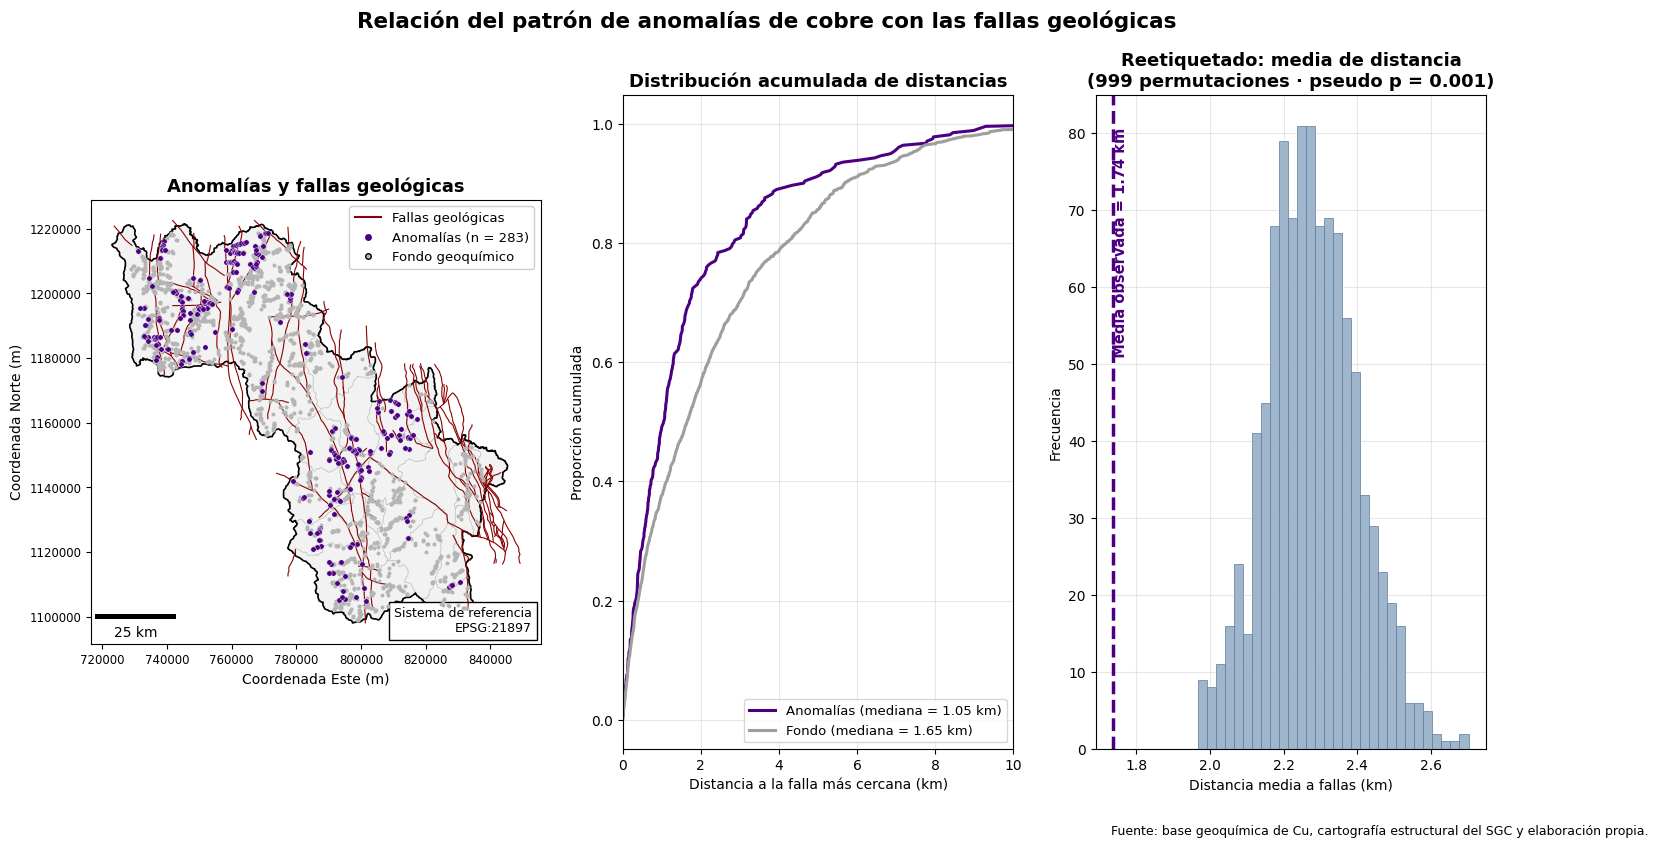

In [63]:
# ==========================================================
# FIGURA 16. ANOMALÍAS Y FALLAS: MAPA, DISTRIBUCIONES
# DE DISTANCIA Y PRUEBA DE REETIQUETADO
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.lines import Line2D


# ----------------------------------------------------------
# 1. Verificar los insumos de la Tabla 16
# ----------------------------------------------------------

variables_requeridas = [
    "distancias_anomalias", "distancias_fondo",
    "medias_simuladas", "media_observada",
    "pseudo_p_fallas", "muestras_fallas"
]

variables_faltantes = [
    v for v in variables_requeridas if v not in globals()
]

if variables_faltantes:
    raise NameError(
        "Primero debes ejecutar la celda de la Tabla 16. "
        f"Variables faltantes: {variables_faltantes}"
    )

limite_fallas = municipios.dissolve()

anomalias_mapa = muestras_fallas[
    muestras_fallas["INDICADOR"] == 1
]

fondo_mapa = muestras_fallas[
    muestras_fallas["INDICADOR"] == 0
]


# ----------------------------------------------------------
# 2. Construir la figura
# ----------------------------------------------------------

figura_fallas = plt.figure(figsize=(18, 8.5))

rejilla_fallas = figura_fallas.add_gridspec(
    1, 3, width_ratios=[1.15, 1, 1], wspace=0.2
)

eje_mapa_fallas = figura_fallas.add_subplot(
    rejilla_fallas[0]
)
eje_ecdf = figura_fallas.add_subplot(rejilla_fallas[1])
eje_permutacion = figura_fallas.add_subplot(
    rejilla_fallas[2]
)


# ----------------------------------------------------------
# 3. Panel A: mapa de anomalías y fallas
# ----------------------------------------------------------

municipios.plot(
    ax=eje_mapa_fallas,
    facecolor="#F2F2F2",
    edgecolor="#BDBDBD",
    linewidth=0.4
)

limite_fallas.boundary.plot(
    ax=eje_mapa_fallas,
    color="black",
    linewidth=1.2
)

fallas.plot(
    ax=eje_mapa_fallas,
    color="#8B0000",
    linewidth=0.8,
    zorder=4
)

eje_mapa_fallas.scatter(
    fondo_mapa.geometry.x, fondo_mapa.geometry.y,
    s=3.5, color="#B5B5B5", zorder=5
)

eje_mapa_fallas.scatter(
    anomalias_mapa.geometry.x, anomalias_mapa.geometry.y,
    s=15, color="#4B0082",
    edgecolor="white", linewidth=0.3, zorder=6
)

eje_mapa_fallas.legend(
    handles=[
        Line2D(
            [0], [0], color="#8B0000", linewidth=1.5,
            label="Fallas geológicas"
        ),
        Line2D(
            [0], [0], marker="o", color="none",
            markerfacecolor="#4B0082",
            markeredgecolor="white", markersize=6,
            label=(
                "Anomalías "
                f"(n = {len(anomalias_mapa)})"
            )
        ),
        Line2D(
            [0], [0], marker="o", color="none",
            markerfacecolor="#B5B5B5", markersize=4,
            label="Fondo geoquímico"
        )
    ],
    loc="upper right",
    fontsize=9.5,
    framealpha=0.95
)

eje_mapa_fallas.add_artist(
    ScaleBar(1, units="m", location="lower left",
             box_alpha=0.8)
)

eje_mapa_fallas.text(
    0.98, 0.02,
    "Sistema de referencia\nEPSG:21897",
    transform=eje_mapa_fallas.transAxes,
    ha="right", va="bottom", fontsize=9,
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        boxstyle="square,pad=0.4"
    )
)

eje_mapa_fallas.set_title(
    "Anomalías y fallas geológicas",
    fontsize=13, fontweight="bold"
)

eje_mapa_fallas.set_xlabel("Coordenada Este (m)")
eje_mapa_fallas.set_ylabel("Coordenada Norte (m)")
eje_mapa_fallas.ticklabel_format(style="plain")
eje_mapa_fallas.tick_params(labelsize=8.5)


# ----------------------------------------------------------
# 4. Panel B: distribuciones acumuladas de distancia
# ----------------------------------------------------------

curvas_ecdf = [
    (
        distancias_anomalias, "#4B0082",
        (
            "Anomalías (mediana = "
            f"{np.median(distancias_anomalias) / 1000:.2f} km)"
        )
    ),
    (
        distancias_fondo, "#9E9E9E",
        (
            "Fondo (mediana = "
            f"{np.median(distancias_fondo) / 1000:.2f} km)"
        )
    ),
]

for datos, color, etiqueta in curvas_ecdf:

    distancias_orden = np.sort(datos) / 1000

    proporcion = (
        np.arange(1, len(distancias_orden) + 1)
        / len(distancias_orden)
    )

    eje_ecdf.plot(
        distancias_orden, proporcion,
        color=color, linewidth=2.2, label=etiqueta
    )

eje_ecdf.set_xlim(0, 10)
eje_ecdf.set_xlabel(
    "Distancia a la falla más cercana (km)"
)
eje_ecdf.set_ylabel("Proporción acumulada")
eje_ecdf.set_title(
    "Distribución acumulada de distancias",
    fontsize=13, fontweight="bold"
)
eje_ecdf.grid(alpha=0.3)
eje_ecdf.legend(fontsize=9.5, loc="lower right")


# ----------------------------------------------------------
# 5. Panel C: prueba de reetiquetado
# ----------------------------------------------------------

eje_permutacion.hist(
    medias_simuladas / 1000,
    bins=30,
    color="#9FB6CD",
    edgecolor="#5A7A9B",
    linewidth=0.5
)

eje_permutacion.axvline(
    media_observada / 1000,
    color="#4B0082",
    linewidth=2.5,
    linestyle="--"
)

eje_permutacion.text(
    media_observada / 1000,
    eje_permutacion.get_ylim()[1] * 0.95,
    (
        "  Media observada = "
        f"{media_observada / 1000:.2f} km"
    ),
    color="#4B0082",
    fontsize=10.5,
    fontweight="bold",
    ha="left",
    va="top",
    rotation=90
)

eje_permutacion.set_title(
    (
        "Reetiquetado: media de distancia\n"
        f"({len(medias_simuladas)} permutaciones · "
        f"pseudo p = {pseudo_p_fallas:.3f})"
    ),
    fontsize=13, fontweight="bold"
)

eje_permutacion.set_xlabel(
    "Distancia media a fallas (km)"
)
eje_permutacion.set_ylabel("Frecuencia")
eje_permutacion.grid(alpha=0.3)

figura_fallas.suptitle(
    "Relación del patrón de anomalías de cobre con las "
    "fallas geológicas",
    fontsize=15.5, fontweight="bold"
)

figura_fallas.text(
    0.99, 0.01,
    "Fuente: base geoquímica de Cu, cartografía estructural "
    "del SGC y elaboración propia.",
    ha="right", fontsize=9
)


# ----------------------------------------------------------
# 6. Guardar la Figura 16
# ----------------------------------------------------------

plt.savefig(
    FIGURAS / "Figura_16_Distancia_Fallas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Figura 16.** Anomalías de cobre y fallas geológicas (panel izquierdo), distribuciones acumuladas de la distancia a la falla más cercana (panel central) y prueba de reetiquetado por permutación (panel derecho).

Las anomalías de cobre se localizan significativamente más cerca de las fallas que el conjunto del muestreo: su distancia media a la falla más cercana es de 1,737.9 m (mediana de 1,051.4 m), frente a 2,362.2 m (mediana de 1,647.1 m) del fondo geoquímico. La curva acumulada de las anomalías se ubica sistemáticamente por encima de la del fondo, y la prueba de reetiquetado muestra que la media observada es inferior a la de la totalidad de las 999 selecciones aleatorias de 283 sitios muestreados (media simulada = 2,276.6 m; mínimo simulado = 1,966.6 m; pseudo p = 0.001). Existe, por lo tanto, evidencia de un control estructural sobre las anomalías de cobre, que junto con la afinidad litológica identificada en la sección 4.8 explica el agrupamiento espacial demostrado en las secciones 4.5 a 4.7: las anomalías se concentran en los corredores de fallas asociados a las unidades volcánicas cretácicas del occidente del área de estudio.